# RFM-анализ и кластеризация клиентов магазина подарков

#### 0. Введение и бизнес-контекст
- Цель анализа
- Исходные данные

#### 1. Загрузка и предобработка данных
- Загрузка данных
- Удаление пропусков, дубликатов, отрицательных цен
- Проверка пропусков в датах
- Анализ Description vs StockCode

#### 2. Создание признаков
- TotalPrice
- Группировка по клиентам (RFM-база)

#### 3. Разведочный анализ (EDA)
- Распределения и boxplot переменных
- Корреляционный анализ 
- Логарифмирование: пробовали, но отказались (обоснование)

#### 4. RFM-анализ
- Выбор количества сегментов (3, 4 или 5)
- Присвоение баллов (r_score, f_score, m_score)
- Визуализация сегментов (столбчатые диаграммы, pie)
- Анализ состава RFM-сегментов по уровням Recency

#### 5. Кластерный анализ
- Выбор переменных (recency, frequency, monetary)
- 3D и 2D визуализация
- Выделение суперэлиты (IQR правило)
- Сравнение методов:
  - KMeans (метод локтя, силуэт, DBI)
  - Agglomerative (дендрограмма)
- Коэффициент Крамера V для выбора метода и числа кластеров
- Итоговый выбор: KMeans, 4 кластера + суперэлита
- Визуализация кластеров (PCA)

#### 6. Профилирование кластеров
- Статистики по кластерам (сводная таблица)
- Тепловая карта нормализованных медиан
- Анализ по группам переменных:
  - Временные
  - Ценовые
  - Количественные
  - Скидочные
- Бизнес-интерпретация каждого кластера

#### Дополнения 
- Детализация кластера (суб-сегментация)
- Анализ товарных предпочтений

## Описание исходных данных
**E-Commerce Data**
https://www.kaggle.com/datasets/carrie1/ecommerce-data

Фактические транзакции британского ритейлера

**Информация о наборе данных:**

**Контекст**
Как правило, наборы данных для электронной коммерции являются собственностью компаний, поэтому их сложно найти среди общедоступных данных. Однако репозиторий машинного обучения Калифорнийского университета в Ирвайне предоставил этот набор данных, содержащий реальные транзакции за 2010 и 2011 годы. Набор данных хранится на их сайте, где его можно найти по названию «Онлайн-торговля».

**Content**
"Это транснациональный набор данных, содержащий информацию обо всех транзакциях, произошедших в период с 01.12.2010 по 09.12.2011 в британской онлайн-компании, не имеющей собственных магазинов.Компания в основном продает уникальные подарки на все случаи жизни. **Многие клиенты компании — оптовики**."

In [89]:
import sys
print("Интерпретатор Python:", sys.executable)
print("Версия Python:", sys.version)

Интерпретатор Python: c:\Users\Нелли\Desktop\file_for_run_python\pyFor_AI_in_business_analytics\clean_env\Scripts\python.exe
Версия Python: 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [91]:
path_to_df='e_Commerce_Data.csv'
df = pd.read_csv(path_to_df, encoding='latin-1') 
df.head() 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### 1.2. Обзор структуры данных

Исходный датафрейм содержит 541 909 записей  и 8 колонок. 

| Колонка | Тип данных | Уникальных значений | Описание |
|---------|------------|----------------------|----------|
| **InvoiceNo** | str | 25 900 | Уникальный номер счёта/заказа. Является идентификатором транзакции. |
| **StockCode** | str | 4 070 | Артикул товара. Используется как идентификатор товара в анализе. |
| **Description** | str | 4 223 | Текстовое описание товара. Может содержать синонимы и варианты названий. (Будет продемонстрировано ниже) |
| **Quantity** | int | 722 | Количество единиц товара в позиции заказа. |
| **InvoiceDate** | str | 23 260 | Дата и время совершения транзакции. Преобразовано в формат `datetime` в процессе очистки. |
| **UnitPrice** | float | 1 630 | Цена за единицу товара в фунтах стерлингов. |
| **CustomerID** | float | 4 372 | Идентификатор клиента. Содержит пропуски (NaN) — это транзакции без привязки к клиенту (обычно оптовые заказы или возвраты). |
| **Country** | str | 38 | Страна клиента. Основная доля — Великобритания. |

**Цель анализа:** выделить группы клиентов на основе их покупательского поведения (RFM-анализ и кластеризация), чтобы предложить персонализированные маркетинговые стратегии для каждой группы.

In [92]:
display(df.info())
display(df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


None

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

**Анализ пропущенных дней**

Минимальная дата: 2010-12-01 08:26:00
Максимальная дата: 2011-12-09 12:50:00
Всего дней в периоде: 374
Дней с транзакциями: 305
Пропущенных дней: 69
Распределение пропущенных дней по месяцам:
2010-12    11
2011-01     7
2011-02     4
2011-03     4
2011-04     9
2011-05     6
2011-06     4
2011-07     5
2011-08     5
2011-09     4
2011-10     5
2011-11     4
2011-12     1
Freq: M, Name: count, dtype: int64


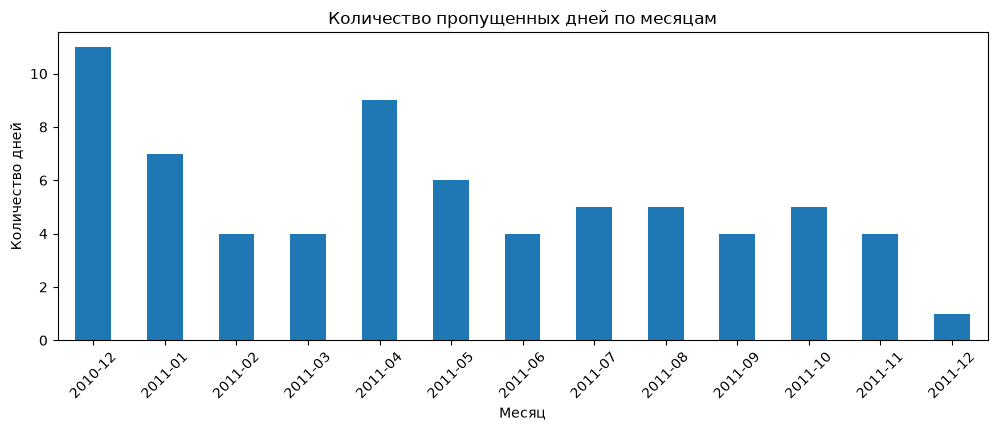

Пропущенные дни по дням недели:
Saturday     53
Monday        6
Friday        4
Sunday        3
Tuesday       1
Wednesday     1
Thursday      1
Name: count, dtype: int64


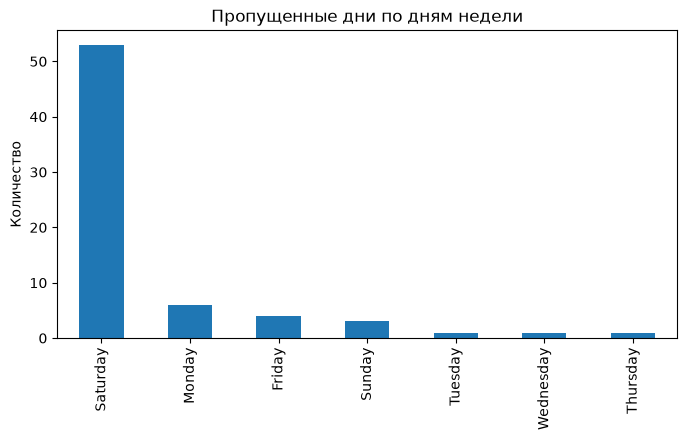

In [93]:
# Преобразование
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Минимальная дата: {df['InvoiceDate'].min()}")
print(f"Максимальная дата: {df['InvoiceDate'].max()}")

# Проверка пропусков

# Создадим полный календарь от минимальной до максимальной даты
min_date = df['InvoiceDate'].min()
max_date = df['InvoiceDate'].max()
all_dates = pd.date_range(start=min_date, end=max_date, freq='D')

# Уникальные даты в данных
unique_dates = df['InvoiceDate'].dt.date.unique()

miss_dates = set(all_dates.date) - set(unique_dates)
print(f"Всего дней в периоде: {len(all_dates)}")
print(f"Дней с транзакциями: {len(unique_dates)}")
print(f"Пропущенных дней: {len(miss_dates)}")

# Преобразуем miss_dates в pandas datetime
missing_series = pd.Series(pd.to_datetime(sorted(miss_dates)))

missing_months = missing_series.dt.to_period('M').value_counts().sort_index()
print("Распределение пропущенных дней по месяцам:")
print(missing_months)

plt.figure(figsize=(12,4))
missing_months.plot(kind='bar')
plt.title('Количество пропущенных дней по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество дней')
plt.xticks(rotation=45)
plt.show()

# Распределение по дням недели
missing_weekdays = missing_series.dt.day_name().value_counts()
print("Пропущенные дни по дням недели:")
print(missing_weekdays)

plt.figure(figsize=(8,4))
missing_weekdays.plot(kind='bar')
plt.title('Пропущенные дни по дням недели')
plt.ylabel('Количество')
plt.show()

### Анализ пропущенных дат

**Распределение пропусков по месяцам:**
Основной пик приходится на декабрь 2010 года (11 дней), что скорее всего связано с рождественскими каникулами. Второй пик — апрель 2011 года (9 дней), вероятно, из-за Пасхи.

**Распределение пропусков по дням недели:**
То, что 53 из 69 пропусков приходятся на субботу может означать, что магазин не работает по субботам. 

**Вывод:** Пропуски не связаны с проблемами в данных. Для RFM-анализа они не критичны.

**Удаление строк:**

1. **CustomerID = NaN**: Эти строки не могут быть привязаны к конкретному клиенту, а значит, не участвуют в RFM-анализе.
    - В случае необходимости можно было бы попробовать восстановить часть записей с CustomerID = NaN через InvoiceNo, но здесь  будем использовать упрощённый подход.

In [94]:
print(f"Примеры строк без CustomerID:")
display(df[df['CustomerID'].isna()].head(5))
initial_rows = len(df)
df = df.dropna(subset=['CustomerID'])
print(f"Удалено строк без CustomerID: {initial_rows - len(df)}")
print(f"Размер после удаления пропусков: {df.shape}")

Примеры строк без CustomerID:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


Удалено строк без CustomerID: 135080
Размер после удаления пропусков: (406829, 8)


2. **Quantity <= 0 или UnitPrice <= 0**: Отрицательное Quantity — это возвраты (клиент вернул товар). Поскольку мы анализируем продажи, а не возвраты, мы их удаляем. UnitPrice = 0 — скорее всего, ошибка или бесплатный образец, такие записи тоже не несут смысла для расчёта.

In [95]:
print(f"\nПримеры строк с некорректными Quantity/UnitPrice:")
display(df[(df['Quantity'] <= 0) | (df['UnitPrice'] <= 0)].head(5))

initial_rows = len(df)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"Удалено строк с отрицательными или нулевыми Quantity/UnitPrice: {initial_rows - len(df)}")
print(f"Размер после удаления: {df.shape}")


Примеры строк с некорректными Quantity/UnitPrice:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


Удалено строк с отрицательными или нулевыми Quantity/UnitPrice: 8945
Размер после удаления: (397884, 8)



3. **Дубликаты**: Полные дубликаты строк могут возникать из-за сбоев при импорте. Их удаление не влияет на анализ, но очищает данные.

In [96]:
initial_rows = len(df)
df = df.drop_duplicates()

print(f"Удалено дубликатов строк: {initial_rows - len(df)}")
print(f"Размер после удаления дубликатов: {df.shape}")

Удалено дубликатов строк: 5192
Размер после удаления дубликатов: (392692, 8)


### Анализ связей: StockCode, Description, UnitPrice

Что мы проверяем

Связь StockCode → Description — один код может иметь несколько описаний (синонимы, опечатки, разные варианты названия).

Связь Description → StockCode — одно описание может соответствовать нескольким кодам (разные варианты товара, разные поставщики).

Связь Description ↔ UnitPrice — сколько уникальных цен у одного описания/кода. Это поможет определить, есть ли в данных скидки.

Особые случаи — транзакции без товаров (доставка, комиссии, ручная обработка), которые не являются товарами в классическом смысле.

In [97]:
df[['StockCode','Description','UnitPrice']].nunique()
# Количество уникальных описаний (Description) не соответствует количеству кодов товаров (StockCode)

StockCode      3665
Description    3877
UnitPrice       440
dtype: int64

In [98]:
df.head()
# Коды товаров в основном имеют формат числа или числа и буквы в конце строки 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [99]:
# один StockCode → несколько Description?

code_analysis = df[['StockCode','Description','UnitPrice']].groupby('StockCode').nunique()
display(code_analysis.sort_values(by='Description',ascending=False).head(6))

# Товары, у которых несколько описаний
multi_desc_codes = code_analysis[code_analysis['Description'] > 1]
print(f"\n=== StockCode с несколькими описаниями ===")
print(f"StockCode с несколькими описаниями: {len(multi_desc_codes)}")
print(f"Максимум описаний у одного кода: {multi_desc_codes['Description'].max()}")

# код с несколькими описаниями

example_code = multi_desc_codes.iloc[0].name
print(f"\nПример: StockCode = {example_code}")
print(f"Описания для этого кода:")
print(df[df['StockCode'] == example_code]['Description'].unique())

print(f"\nПример: StockCode = 23196")
print(f"Описания для этого кода:")
print(*df[df['StockCode'] == '23196']['Description'].unique(),sep='|')

,Description,UnitPrice
StockCode,,
23196,4,2
23236,4,3
23126,3,3
23396,3,2
23535,3,4
22937,3,3



=== StockCode с несколькими описаниями ===
StockCode с несколькими описаниями: 213
Максимум описаний у одного кода: 4

Пример: StockCode = 16156L
Описания для этого кода:
<StringArray>
['WRAP, CAROUSEL', 'WRAP CAROUSEL']
Length: 2, dtype: str

Пример: StockCode = 23196
Описания для этого кода:
RETRO LEAVES MAGNETIC NOTEPAD|RETO LEAVES MAGNETIC SHOPPING LIST|LEAVES MAGNETIC  SHOPPING LIST|VINTAGE LEAF MAGNETIC NOTEPAD


**Один StockCode может иметь несколько описаний.** Это связано с опечатками, синонимами и разными вариантами названия (например, `'WRAP, CAROUSEL'` и `'WRAP CAROUSEL'`). Таких кодов — 213, максимум 4 варианта описания.

In [100]:
#  одно Description → несколько StockCode 

desc_analysis = df.groupby('Description').agg({
    'StockCode': 'nunique',
    'UnitPrice': 'nunique'
}).reset_index()
desc_analysis.columns = ['Description', 'n_codes', 'n_prices']

# Описания, у которых несколько кодов
multi_code_descs = desc_analysis[desc_analysis['n_codes'] > 1]
print(f"\n--- Description с несколькими StockCode ---")
print(f"Всего таких описаний: {len(multi_code_descs)}")
print(f"Максимум кодов у одного описания: {multi_code_descs['n_codes'].max()}")

# Пример: описание с несколькими кодами
example_code = multi_code_descs.iloc[0]['Description']
print(f"\nПример: Description = {example_code}")
print(f"Код для этого Описания:")
print(df[df['Description'] == example_code]['StockCode'].unique())

# Пример: описание с несколькими кодами
example_code = multi_code_descs.iloc[1]['Description']
print(f"\nПример: Description = {example_code}")
print(f"Код для этого Описания:")
print(df[df['Description'] == example_code]['StockCode'].unique())


--- Description с несколькими StockCode ---
Всего таких описаний: 19
Максимум кодов у одного описания: 3

Пример: Description = COLOURING PENCILS BROWN TUBE
Код для этого Описания:
<StringArray>
['10133', '10135']
Length: 2, dtype: str

Пример: Description = COLUMBIAN CANDLE RECTANGLE
Код для этого Описания:
<StringArray>
['72133', '72131']
Length: 2, dtype: str


**Одно Description может соответствовать нескольким StockCode.** Это может быть связано с разными вариантами одного товара (цвет, размер, материал). Таких описаний — 19, максимум 3 кода. Утывая количество таких случаев эти будем считать их исключениями.

**Вывод:** `Description` ненадёжен для идентификации товара из-за ошибок в записях. Используем `StockCode` как основной идентификатор товара.

In [101]:
# уникальные цены на товар (признак скидок)

# Товары с несколькими ценами (потенциальные скидки)
multi_price_items = code_analysis[code_analysis['UnitPrice'] > 1]

print(f"StockCode с несколькими ценами: {len(multi_price_items)} из {(df['StockCode'].nunique())}")
print(f"Максимум цен у одного кода: {multi_price_items['UnitPrice'].max()}")

top_multi_price = multi_price_items.sort_values('UnitPrice', ascending=False).head(10)
print("\nТоп-10 товаров с наибольшим числом цен:")
display(top_multi_price)

StockCode с несколькими ценами: 2628 из 3665
Максимум цен у одного кода: 105

Топ-10 товаров с наибольшим числом цен:


,Description,UnitPrice
StockCode,,
M,1,105
POST,1,32
DOT,1,16
21166,1,12
82484,1,10
21175,2,10
85152,1,9
79321,1,8
48185,1,8


**Наличие нескольких цен на один товар указывает на скидки.**
- У **2628** товаров (из 3665) встречается более одной цены.
- Максимальное число цен у одного товара — **105** (код `M`, `POST` и `DOT` — служебные записи, исключаем).
- У реальных товаров (например, `21166`) зафиксировано до 12 различных цен.

В данных присутствуют скидки. 

**Найдём и рассмотрим нетоварные коды**

In [102]:
# Из анализа уникальных цен замечены особые коды:
display(df[df['StockCode']=='M'][['Description','StockCode']].iloc[0])
display(df[df['StockCode']=='POST'][['Description','StockCode']].iloc[0])
display(df[df['StockCode']=='DOT'][['Description','StockCode']].iloc[0])

Description    Manual
StockCode           M
Name: 2239, dtype: str

Description    POSTAGE
StockCode         POST
Name: 45, dtype: str

Description    DOTCOM POSTAGE
StockCode                 DOT
Name: 317507, dtype: str

**Поиск нетоварных записей**

Как было замечено ранее в обычных кодах товаров присуцтвют цифры, в рассмотренных служебных записях их нет. Поищем другие похожие коды.

In [103]:
df_analysis = df.copy()

# Проверяем наличие цифр в коде
def is_numeric_stockcode(code):
    if isinstance(code, str):
        # Удаляем возможные пробелы
        code = code.strip()
        # Проверяем, состоит ли строка только из цифр 
        return any(char.isdigit() for char in code)
    return False

# True для строковых кодов
df_analysis['is_numeric_code'] = df_analysis['StockCode'].apply(is_numeric_stockcode)

print(f"Числовых StockCode: {df_analysis[df_analysis['is_numeric_code']]['StockCode'].nunique()}")
print(f"Строковых StockCode (только буквы): {df_analysis[~df_analysis['is_numeric_code']]['StockCode'].nunique()}")


string_code_df = df_analysis[~df_analysis['is_numeric_code']]

# Группируем по StockCode, считаем количество записей и показываем пример описания
string_code_summary = string_code_df.groupby('StockCode').agg(
   count=('Description', 'count'),
   Description=('Description', 'unique'),
).reset_index()

print("\n Строковые StockCode (только буквы) ")
display(string_code_summary.sort_values('count', ascending=False))

Числовых StockCode: 3660
Строковых StockCode (только буквы): 5

 Строковые StockCode (только буквы) 


,StockCode,count,Description
4,POST,1099,[POSTAGE]
2,M,279,[Manual]
1,DOT,16,[DOTCOM POSTAGE]
0,BANK CHARGES,12,[Bank Charges]
3,PADS,3,[PADS TO MATCH ALL CUSHIONS]


### Идентификация и исключение нетоварных записей

 `POST` - Postage (доставка)    
 `M` - Manual (ручная обработка)   
 `DOT` - Dotcom Postage (доставка)   
 `BANK CHARGES` - Банковская комиссия   
 
 `PADS` - Подушки для диванов - товар 
 
Доставка и комиссии не являются товарами, но они добавляются к сумме заказа. Они влияют на расчёт `monetary`, а для расчёта товарных метрик (среднее количество товаров в заказе, разнообразие ассортимента) исключим их.


### TotalPrice
Для расчёта `monetary` заранее создадим построчную сумму за товар  

In [104]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']
df[['TotalPrice','Quantity','UnitPrice']].head()

,TotalPrice,Quantity,UnitPrice
0,15.30,6,2.55
1,20.34,6,3.39
2,22.00,8,2.75
3,20.34,6,3.39
4,20.34,6,3.39


### Разведочный анализ (EDA)

#### Исходные распределения

После создания `TotalPrice = Quantity × UnitPrice` мы построили гистограммы и boxplot для всех трёх переменных.

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


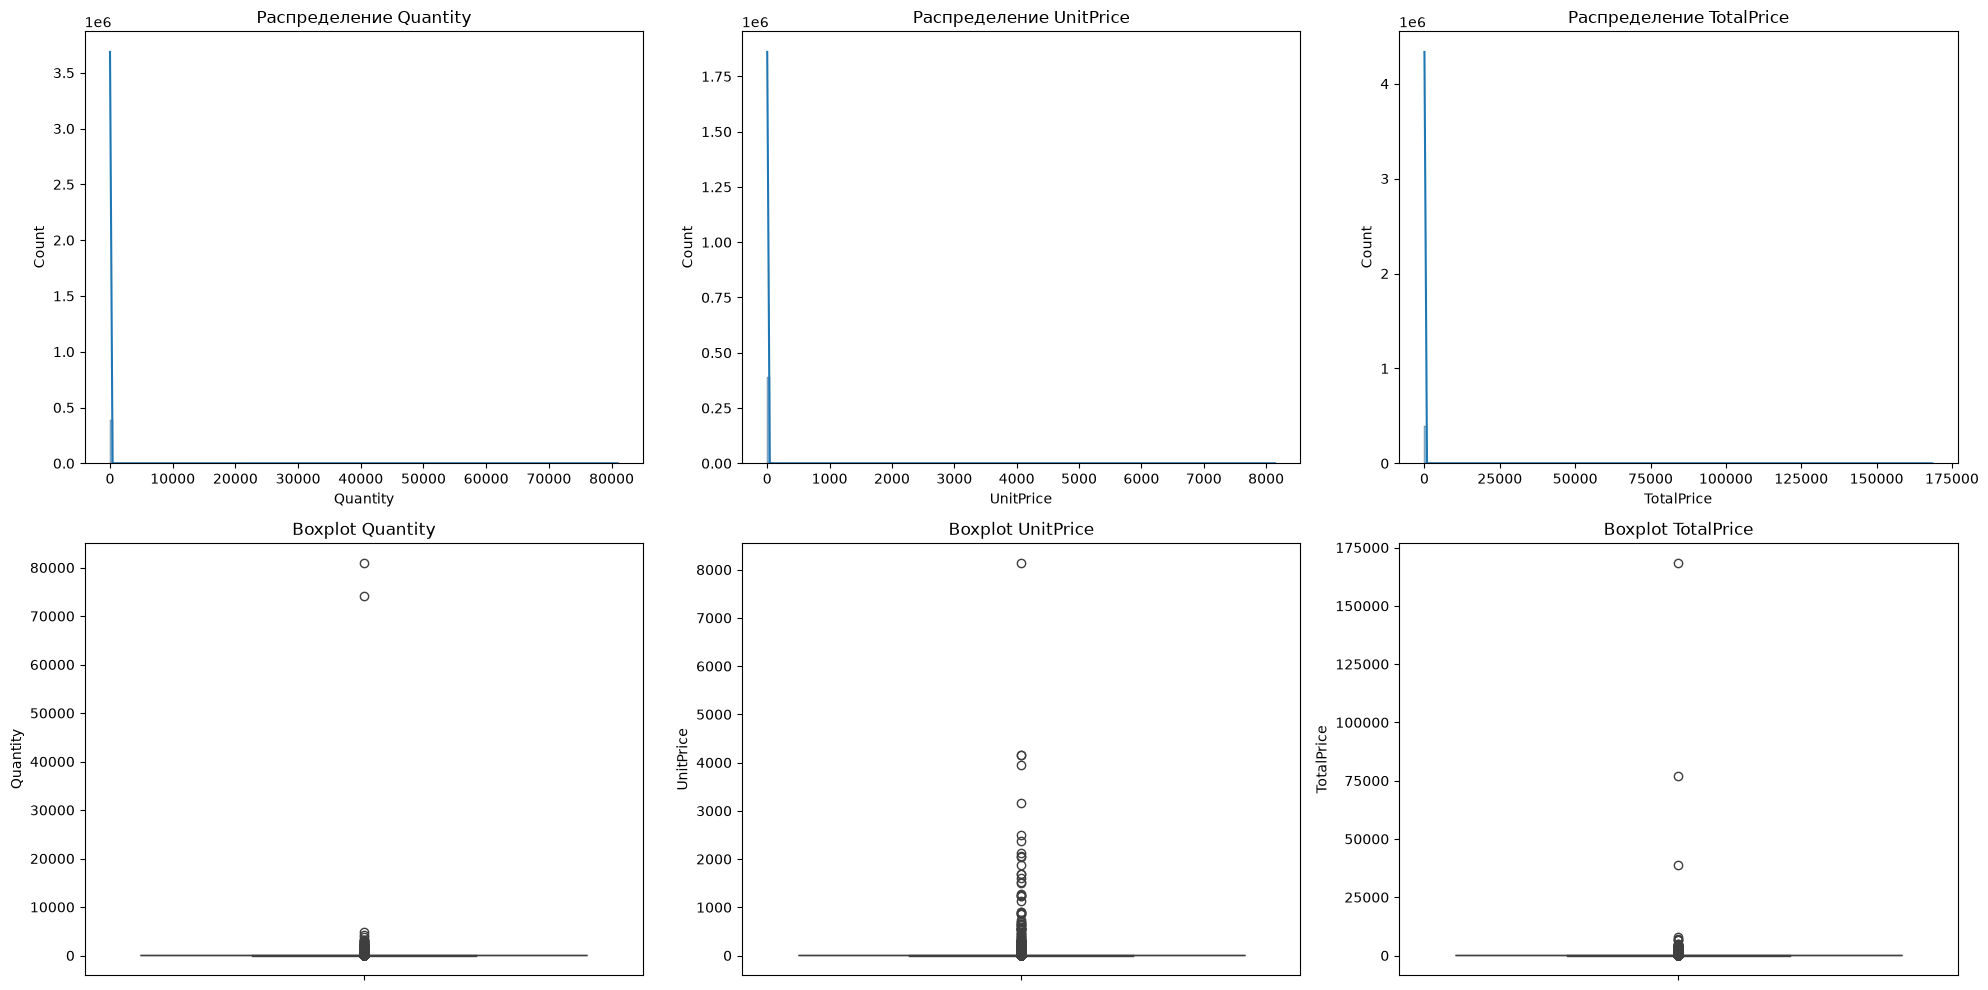

In [105]:
display(df.describe())

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Quantity
sns.histplot(df['Quantity'], bins=200, ax=axes[0,0], kde=True)
axes[0,0].set_title('Распределение Quantity')
sns.boxplot(y=df['Quantity'], ax=axes[1,0])
axes[1,0].set_title('Boxplot Quantity')

# UnitPrice
sns.histplot(df['UnitPrice'], bins=200, ax=axes[0,1], kde=True)
axes[0,1].set_title('Распределение UnitPrice')
sns.boxplot(y=df['UnitPrice'], ax=axes[1,1])
axes[1,1].set_title('Boxplot UnitPrice')

# TotalPrice
sns.histplot(df['TotalPrice'], bins=200, ax=axes[0,2], kde=True)
axes[0,2].set_title('Распределение TotalPrice')
sns.boxplot(y=df['TotalPrice'], ax=axes[1,2])
axes[1,2].set_title('Boxplot TotalPrice')

plt.tight_layout()
plt.show()

**Что мы видим:**
- Все распределения имеют **сильный правый хвост** что подтверждается и статистиками.
- Большая часть значений сосредоточена около нуля, а отдельные экстремальные значения достигают тысяч и десятков тысяч.
- Из-за гигантского разброса основная масса данных сжата у левого края, а отдельные выбросы находятся далеко справа.

**Boxplot подтверждают:** почти все данные находятся в нижней части шкалы, а выбросы «улетают» далеко вверх.


#### Логарифмическая трансформация

Для лучшей визуализации применим логарифмическое преобразование.

**Почему пробовали:**
- Логарифм сжимает длинный правый хвост, делая распределения более симметричными.
- На логарифмических графиках `UnitPrice` и `monetary` стали визуально близки к нормальным.

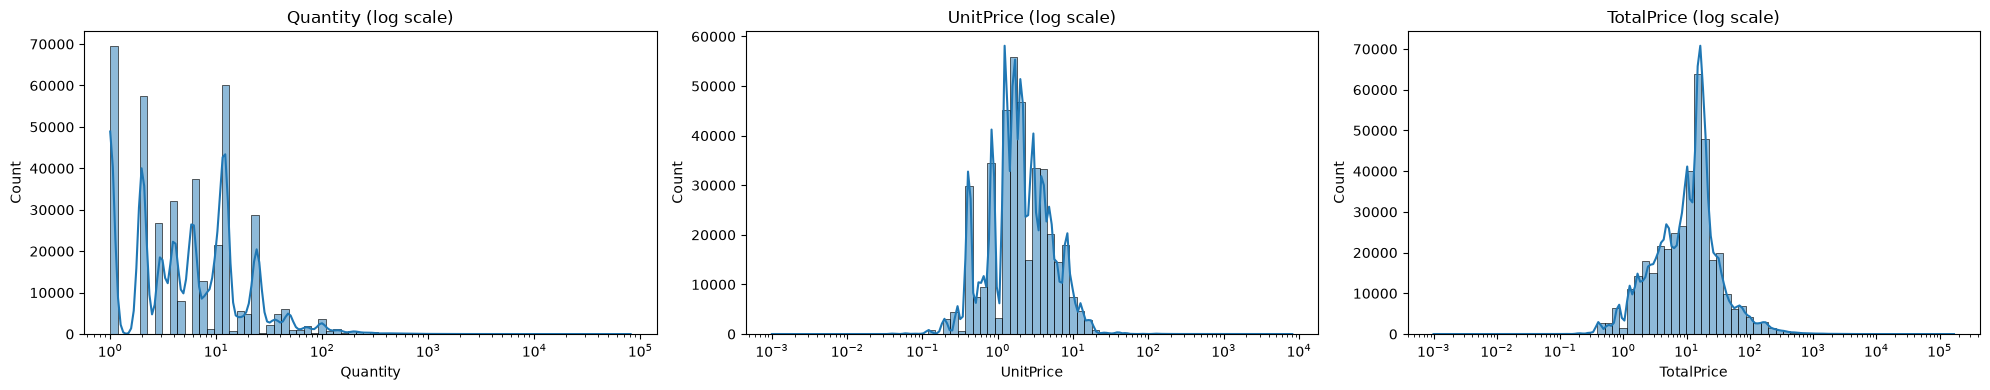

In [106]:
# Распределение с логарифмической шкалой (для лучшего восприятия)
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

sns.histplot(df['Quantity'], bins=70, ax=axes[0], kde=True, log_scale=True)
axes[0].set_title('Quantity (log scale)')

sns.histplot(df['UnitPrice'], bins=70, ax=axes[1], kde=True, log_scale=True)
axes[1].set_title('UnitPrice (log scale)')

sns.histplot(df['TotalPrice'], bins=70, ax=axes[2], kde=True, log_scale=True)
axes[2].set_title('TotalPrice (log scale)')

plt.tight_layout()
plt.show()

 **Проблема выбросов.** Вместо трансформации данных можно выделить в отдельную группу экстремальных значений (к тому же в случае с оптовым магазином это не единичные выбросы, а уникальные клиенты). Это позволит сохранить естественные масштабы для основной массы клиентов.
 
 **Интерпретируемость данных.** Для бизнес-анализа важна интепретируемость результатов, логарифм усложнит эту задачу. RFM-метрики в исходных единицах дают более понятные рекомендации.

**Вывод:** Для дальнейшего анализа мы используем исходные переменные `recency`, `frequency`, `monetary`.

## Таблица для RMF

### Формирование клиентской базы для RFM-анализа

После очистки данных мы агрегировали информацию по каждому клиенту:

- **Recency** — количество дней с момента последней покупки до даты среза (2011-12-10).
- **Frequency** — общее количество уникальных заказов (чеков).
- **Monetary** — общая сумма всех покупок клиента.

В итоговой таблице **4338 клиентов**.

In [107]:
# Определим дату среза (последняя дата в данных + 1 день)
last_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Дата среза для Recency: {last_date}")

# Агрегация по CustomerID
customer_df = df.groupby('CustomerID').agg(
    # first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    frequency=('InvoiceNo', 'nunique'),          # количество уникальных заказов (чеков, независимо от количества товаров в чеке)
    monetary=('TotalPrice', 'sum'),              # общая сумма покупок
).reset_index()

# Рассчитаем Recency (количество дней с последней покупки до last_date)
customer_df['recency'] = (last_date - customer_df['last_purchase']).dt.days

print('Всего клиентов: ', len(customer_df))

customer_df.sort_values(by='frequency',ascending=False).head(5)

# customer_df.to_csv('customer_rfm_data.csv', index=False)
# print("Таблица клиентов сохранена.")

Дата среза для Recency: 2011-12-10 12:50:00
Всего клиентов:  4338


,CustomerID,last_purchase,frequency,monetary,recency
326,12748.0,2011-12-09 12:20:00,209,33053.19,1
1879,14911.0,2011-12-08 15:54:00,201,143711.17,1
4010,17841.0,2011-12-08 12:07:00,124,40519.84,2
562,13089.0,2011-12-07 09:02:00,97,58762.08,3
1661,14606.0,2011-12-08 19:28:00,93,12076.15,1


In [108]:
customer_df.describe().round(2)

,CustomerID,last_purchase,frequency,monetary,recency
count,4338.00,4338,4338.00,4338.00,4338.00
mean,15300.41,2011-09-08 11:38:59.045643,4.27,2048.69,92.54
min,12346.00,2010-12-01 09:53:00,1.00,3.75,1.00
25%,13813.25,2011-07-20 19:18:00,1.00,306.48,18.00
50%,15299.50,2011-10-20 10:40:30,2.00,668.57,51.00
75%,16778.75,2011-11-22 11:05:45,5.00,1660.60,142.00
max,18287.00,2011-12-09 12:50:00,209.00,280206.02,374.00
std,1721.81,NaN,7.70,8985.23,100.01


**Интерпретация:**
- Средняя давность (`recency`) покупки ~92 дня, но медиана 51 день — разброс велик (есть как совсем новые клиенты, так и давно ушедшие).
- Частота (`frequency`) покупок в среднем 4.3 заказа, но медиана 2 — большинство клиентов сделали 1–2 заказа, а несколько «супер-активных» (209 заказов) сильно тянут среднее вверх.
- `Monetary` в среднем ~2049 ₽, медиана ~669 ₽ — аналогичная картина: небольшая группа клиентов с огромными тратами.

В описании данных упоминаются клиенты **оптовики**, это свидетельствует о том, что наблюдаемые статистики нельзя списать на случайные выбросы.  

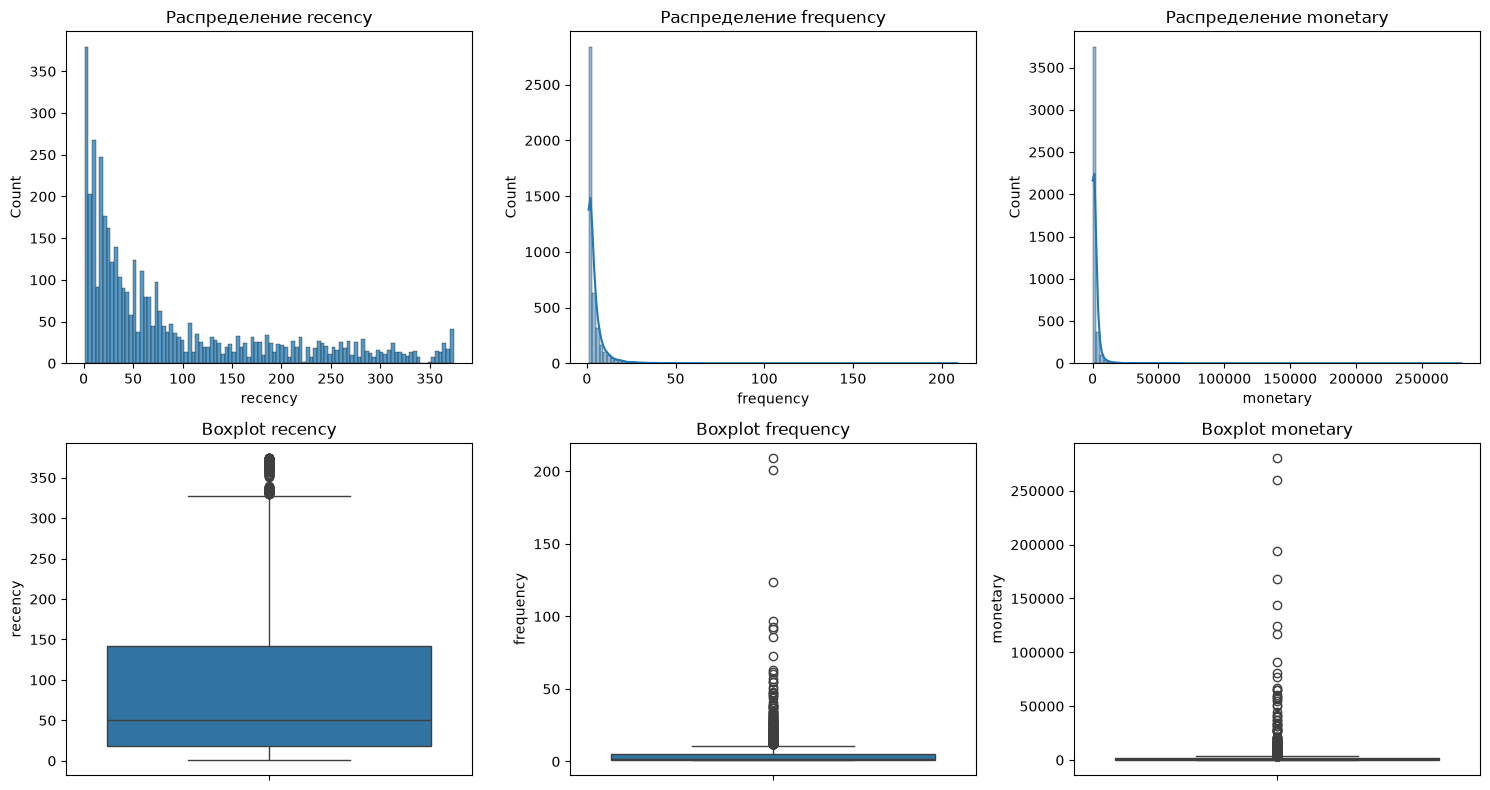

In [109]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# recency
sns.histplot(customer_df['recency'], bins=100, ax=axes[0,0])
axes[0,0].set_title('Распределение recency')
sns.boxplot(y=customer_df['recency'], ax=axes[1,0])
axes[1,0].set_title('Boxplot recency')

# frequency
sns.histplot(customer_df['frequency'], bins=100, ax=axes[0,1], kde=True)
axes[0,1].set_title('Распределение frequency')
sns.boxplot(y=customer_df['frequency'], ax=axes[1,1])
axes[1,1].set_title('Boxplot frequency')

# monetary
sns.histplot(customer_df['monetary'], bins=100, ax=axes[0,2], kde=True)
axes[0,2].set_title('Распределение monetary')
sns.boxplot(y=customer_df['monetary'], ax=axes[1,2])
axes[1,2].set_title('Boxplot monetary')

plt.tight_layout()
plt.show()

#### Распределения и выбросы

Гистограммы и boxplot для каждой метрики показывают:

- **Recency** — распределение относительно равномерное, но с пиком в районе 50–100 дней. Есть длинный хвост до 374 дней.
- **Frequency** и **Monetary** имеют сильно скошенные распределения с длинными правыми хвостами. Небольшое число клиентов совершает множество покупок и приносит основную выручку (скорее всео это именно те оптовые клиенты, что упоминаются в описании).

### Непараметрическая корреляция Спирмена

 Так как распределения не являются нормальными, будем использовать корреляцию Спирмена.

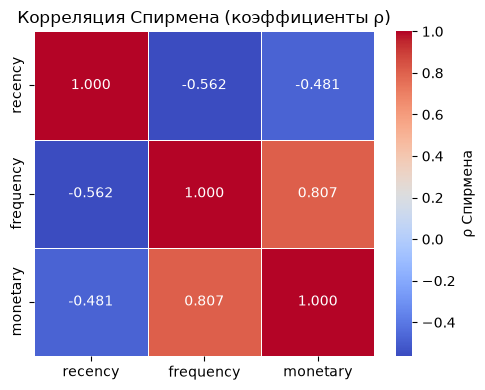

Корреляция Спирмена (коэффициенты):


,recency,frequency,monetary
recency,1.000,-0.562,-0.481
frequency,-0.562,1.000,0.807
monetary,-0.481,0.807,1.000


p-values:


,recency,frequency,monetary
recency,0.0,0.0,0.0
frequency,0.0,0.0,0.0
monetary,0.0,0.0,0.0


In [110]:
from scipy.stats import spearmanr

# Расчёт корреляции Спирмена с p-значениями
corr_spearman = customer_df[['recency', 'frequency', 'monetary']].corr(method='spearman')
p_values = pd.DataFrame(index=corr_spearman.columns, columns=corr_spearman.columns)

for i in corr_spearman.columns:
    for j in corr_spearman.columns:
        if i == j:
            p_values.loc[i, j] = 0.0
        else:
            _, p = spearmanr(customer_df[i], customer_df[j])
            p_values.loc[i, j] = round(p, 4)

# Визуализация
fig, axes = plt.subplots( figsize=(5, 4))

# Тепловая карта коэффициентов
sns.heatmap(corr_spearman.round(3), annot=True, cmap='coolwarm', fmt='.3f', 
            linewidths=0.5, cbar_kws={'label': 'ρ Спирмена'})
axes.set_title('Корреляция Спирмена (коэффициенты ρ)')

plt.tight_layout()
plt.show()

print("Корреляция Спирмена (коэффициенты):")
display(corr_spearman.round(3))
print("p-values:")
display(p_values)

**Результаты:**
- **Frequency и Monetary (ρ = 0.807)** — сильная положительная связь. Клиенты с высокой частотой покупок приносят больше выручки.
- **Recency и Frequency (ρ = -0.562)** — умеренная отрицательная связь. Давно не покупавшие клиенты совершали меньше заказов.
- **Recency и Monetary (ρ = -0.481)** — умеренная отрицательная связь. Клиенты с большой давностью покупок принесли меньше денег.

**Все p-value < 0.001** — связи статистически значимы.

**Вывод:** frequency и monetary несут схожую информацию, что важно учитывать при кластеризации. Recency является самостоятельным измерением, отражающим актуальность клиента (клиентов недавно совершивших покупку проще стимулировать к новому заказу).

### Базовый RMF анализ 

### Определение оптимального числа групп (3, 4 или 5)

Для каждой из трёх метрик (recency, frequency, monetary) мы должны выбрать количество групп (классов) для присвоения баллов (1–3, 1–4 или 1–5). Разобьём каждую переменную на равные по численности группы с помощью квантилей.

**Критерии выбора:**
1. **Бизнес-интерпретируемость** — группы должны иметь смысл для маркетинга (например, «новые», «средние», «давние»).
2. **Размер групп** — слишком мелкие группы (менее 5–10% клиентов) усложняют анализ. Также стремительно растёт число комбинаций классов (3 балла - 27 классов, 5 баллов - 125 классов).
3. **Равномерность распределения** — желательно, чтобы группы были примерно равны по численности.

Для принятия решения мы визуализируем границы для 3, 4 и 5 групп на гистограмме каждой переменной.


=== recency ===
3 группы: [25. 88.]
4 группы: [ 18.  51. 142.]
5 группы: [ 13.4  33.   72.  179. ]


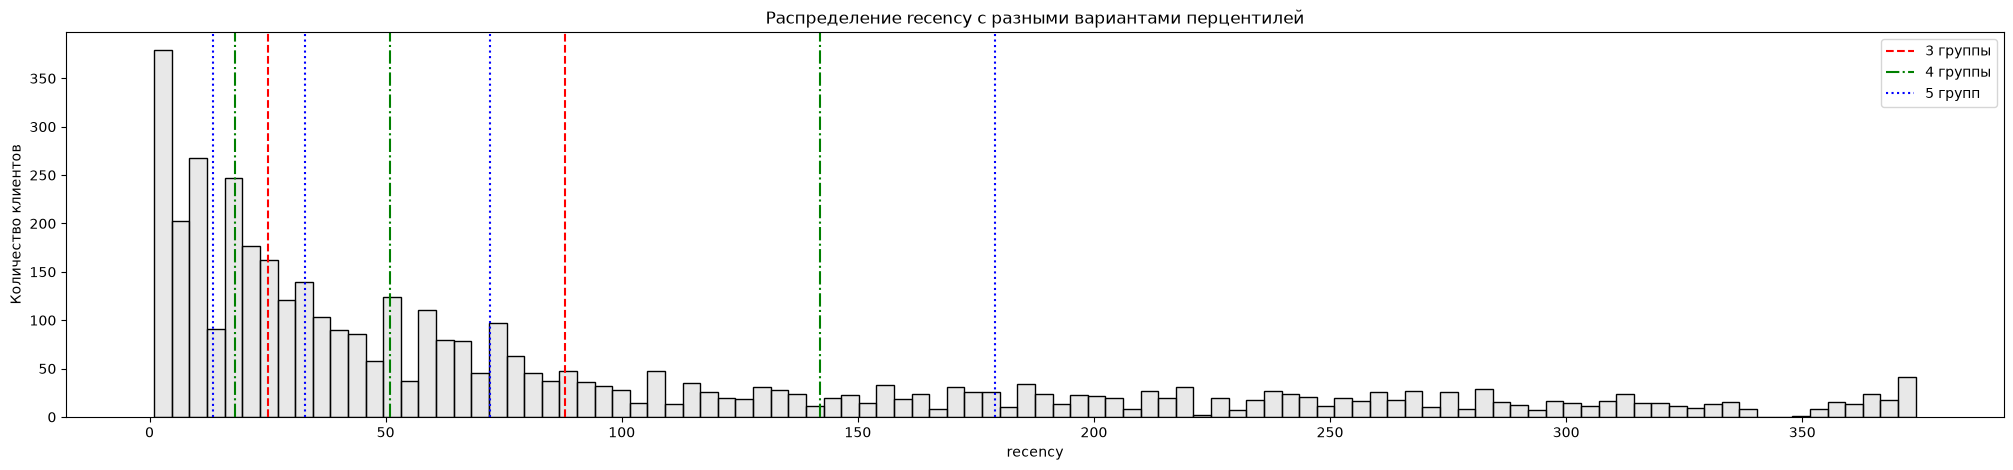


=== frequency ===
3 группы: [1. 4.]
4 группы: [1. 2. 5.]
5 группы: [1. 2. 3. 6.]


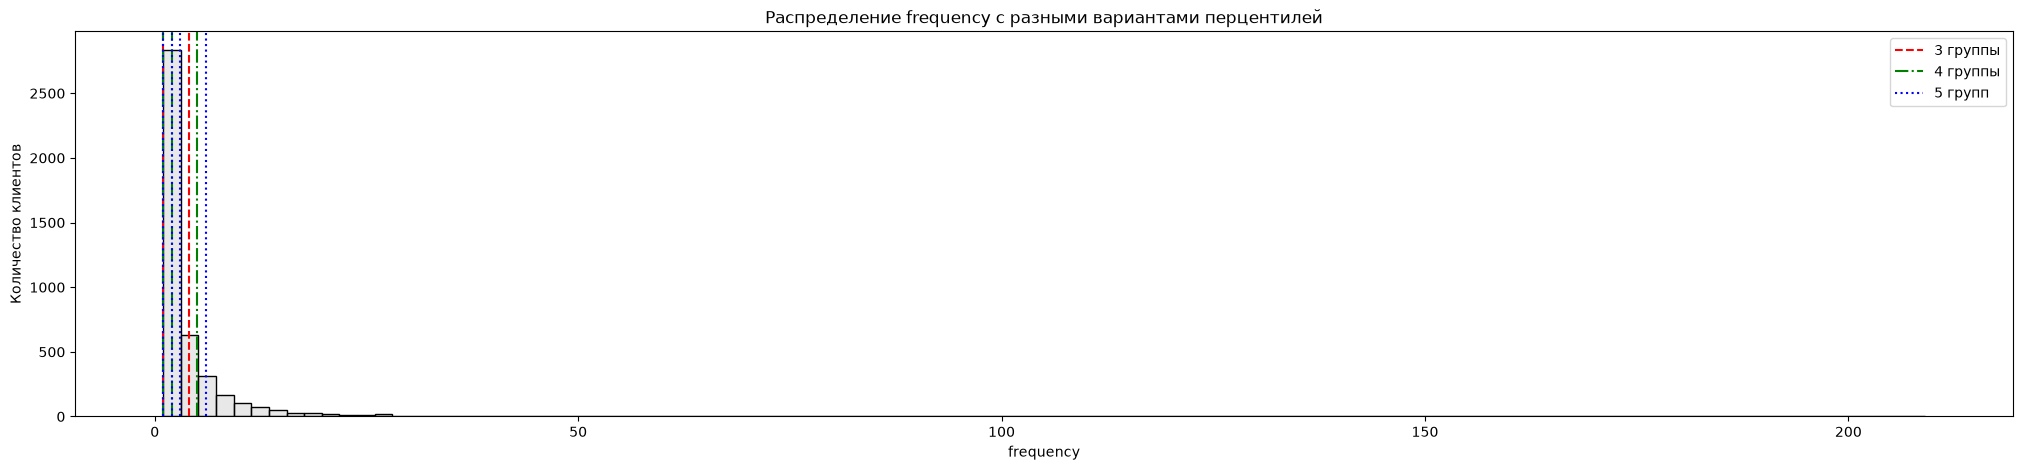


=== monetary ===
3 группы: [ 384.1  1154.43]
4 группы: [ 306.48  668.57 1660.6 ]
5 группы: [ 249.34  487.41  933.35 2055.05]


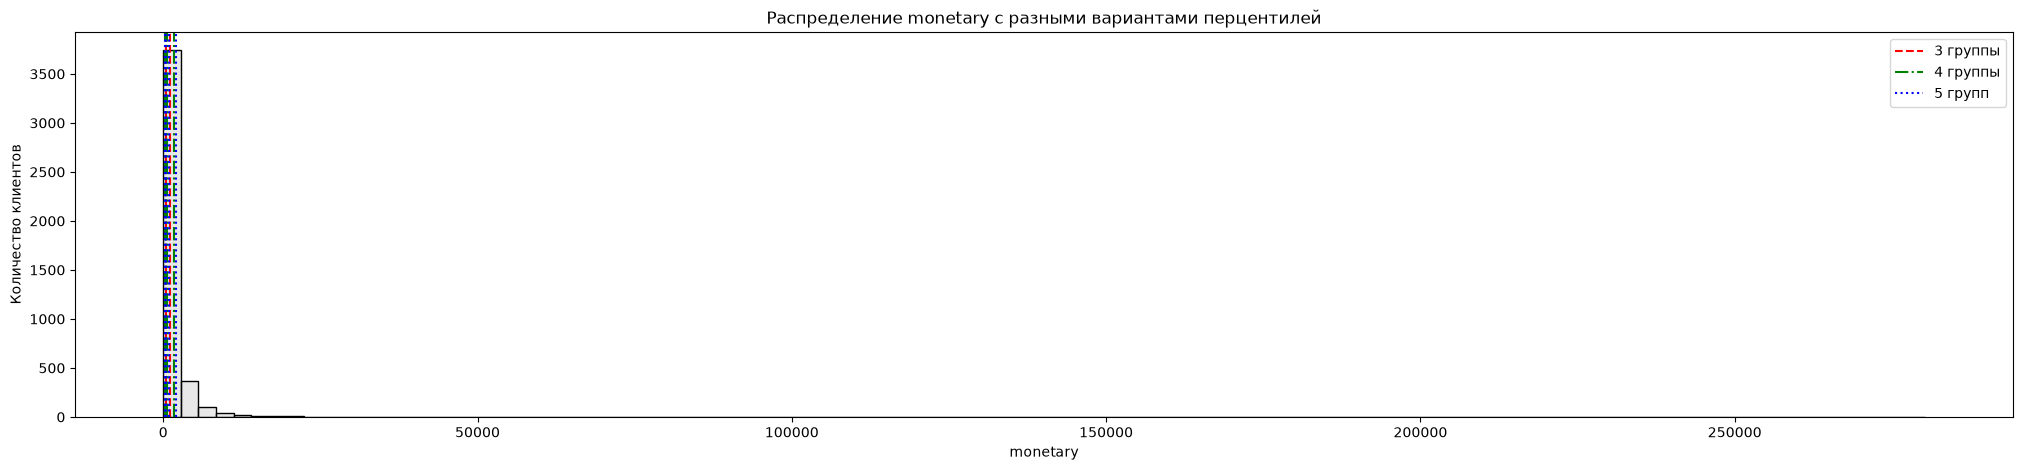

In [111]:
for var in ['recency', 'frequency', 'monetary']:
    """
    Строит гистограмму переменной и наносит вертикальные линии для 3, 4 и 5 групп.
    """
    # Процентили для разного числа групп
    p3 = np.percentile(customer_df[var], [33, 66])   # 3 группы (≈ 33% и 66%)
    p4 = np.percentile(customer_df[var], [25, 50, 75])      # 4 группы
    p5 = np.percentile(customer_df[var], [20, 40, 60, 80])  # 5 групп

        # Вывод значений
    print(f"\n=== {var} ===")
    print(f"3 группы: {np.round(p3, 2)}")
    print(f"4 группы: {np.round(p4, 2)}")
    print(f"5 группы: {np.round(p5, 2)}")

    plt.figure(figsize=(25, 5))
    sns.histplot(customer_df[var], bins=100,  alpha=0.5, color='lightgray')
    
    # Линии для 3 групп 
    for i, p in enumerate(p3):
        plt.axvline(p, color='red', linestyle='--', linewidth=1.5, 
                    label=f'3 группы' if i == 0 else "")
    # 4 группы 
    for i, p in enumerate(p4):
        plt.axvline(p, color='green', linestyle='-.', linewidth=1.5, 
                    label=f'4 группы' if i == 0 else "")
    # 5 групп 
    for i, p in enumerate(p5):
        plt.axvline(p, color='blue', linestyle=':', linewidth=1.5, 
                    label=f'5 групп' if i == 0 else "")
    
    plt.title(f'Распределение {var} с разными вариантами перцентилей')
    plt.xlabel(var)
    plt.ylabel('Количество клиентов')
    plt.legend()
    plt.show()  

**Выбор количества групп (3 вместо 4 или 5)**

Выберем **3 группы** (терцили) для каждой RFM-метрики:

1. **Распределения имеют сильный правый хвост** — при делении на 4 группы первые интервалы слишком узкие (например, частота 1 и 2 заказа попадают в разные группы, хотя их поведение почти одинаково).
2. **Терцили дают чёткие бизнес-интерпретации**: активные / средние / потерянные; разовые / редкие / частые; мелкие / средние / крупные.
3. **Меньше групп = проще интерпретация** при построении рекомендаций.

### **Присвоить RFM-баллы 1–3**

In [112]:
# Терции (33%)
r_bins = [0, np.percentile(customer_df['recency'], 33), np.percentile(customer_df['recency'], 66), customer_df['recency'].max()+1]
f_bins = [0, np.percentile(customer_df['frequency'], 33), np.percentile(customer_df['frequency'], 66), customer_df['frequency'].max()+1]
m_bins = [0, np.percentile(customer_df['monetary'], 33), np.percentile(customer_df['monetary'], 66), customer_df['monetary'].max()+1]

customer_df['r_score'] = pd.cut(customer_df['recency'], bins=r_bins, labels=[3,2,1], include_lowest=True)
customer_df['f_score'] = pd.cut(customer_df['frequency'], bins=f_bins, labels=[1,2,3], include_lowest=True)
customer_df['m_score'] = pd.cut(customer_df['monetary'], bins=m_bins, labels=[1,2,3], include_lowest=True)

# Общий балл (сумма)
customer_df['RFM_score'] = (
    customer_df['r_score'].astype(int) + 
    customer_df['f_score'].astype(int) + 
    customer_df['m_score'].astype(int)
)

# Комбинация (например, 555, 111, 543)
customer_df['RFM_segment'] = (
    customer_df['r_score'].astype(str) + 
    customer_df['f_score'].astype(str) + 
    customer_df['m_score'].astype(str)
)

rfm_table = customer_df.groupby(['m_score', 'r_score', 'f_score']).size().reset_index(name='count')

display(rfm_table.sort_values(['count'], ascending=False).T)

,20,6,13,10,16,3,23,22,15,19,...,26,14,9,24,17,21,8,18,2,5
m_score,3,1,2,2,2,1,3,3,2,3,...,3,2,2,3,2,3,1,3,1,1
r_score,3,1,2,3,1,2,2,2,1,3,...,1,2,3,1,1,2,1,3,3,2
f_score,3,1,2,2,2,1,3,2,1,2,...,3,3,1,1,3,1,3,1,3,3
count,659,652,341,308,298,295,273,179,177,159,...,49,41,34,27,22,22,3,3,3,1


### Присвоение RFM-баллов

Для каждой из трёх метрик (Recency, Frequency, Monetary) мы выбрали **3 группы** (терцили), разделив клиентов на три равные по численности части. Границы групп (терцилей) распределились следующим образом:

| Метрика | 1-я группа (балл 1) | 2-я группа (балл 2) | 3-я группа (балл 3) |
|---------|---------------------|---------------------|---------------------|
| **Recency** | > 92 дней (давние) | 26–92 дня (средние) | ≤ 25 дней (новые) |
| **Frequency** | 1 заказ (редкие) | 2–4 заказа (средние) | ≥ 5 заказов (частые) |
| **Monetary** | ≤ 388 ₽ (мелкие) | 389–1194 ₽ (средние) | > 1194 ₽ (крупные) |
---
**Два полюса:** Сегменты **3-3-3**  и **1-1-1**  являются самыми крупными. Они представляют собой два крайних типа клиентов:
   - **3-3-3 («Чемпионы»):** недавние, частые, с высокими тратами. Это самая ценная группа клиентов, приносящая основную выручку.
   - **1-1-1 («Потерянные»):** давние, редкие, с минимальными тратами. Это группа оттока или группа случайных клиентов. Большая доля таких клиентов может указывать как на то что бизнес в них не заинтересован (ориентирован на оптовых клиентов в нашем случае), так и на то, что с этим клиентам стоит уделить больше внимания.  


### Анализ состава RFM-сегментов по уровням Recency

Одним из ключевых вопросов RFM-анализа является понимание того, как клиенты перемещаются между сегментами. Особый интерес представляет динамика перехода из активных групп в отток и наоборот. Проанализируем **состав сегментов внутри каждого уровня Recency**. Это позволит понять, какие группы клиентов с точки зрения частоты и monetary находятся на разных стадиях "жизненного цикла".

Мы разбили клиентов на три группы по давности последней покупки:
- **r = 1** — давние (более 92 дней с последней покупки) — зона оттока
- **r = 2** — средние (26–92 дня) — промежуточная зона
- **r = 3** — недавние (менее 26 дней) — активная зона

Для каждой из этих групп мы отобразим,  комбинации `f_score` и `m_score` (частота и monetary). Это позволит оценить, какие клиенты с каким "прошлым" попадают в отток, а какие приходят в активную зону.

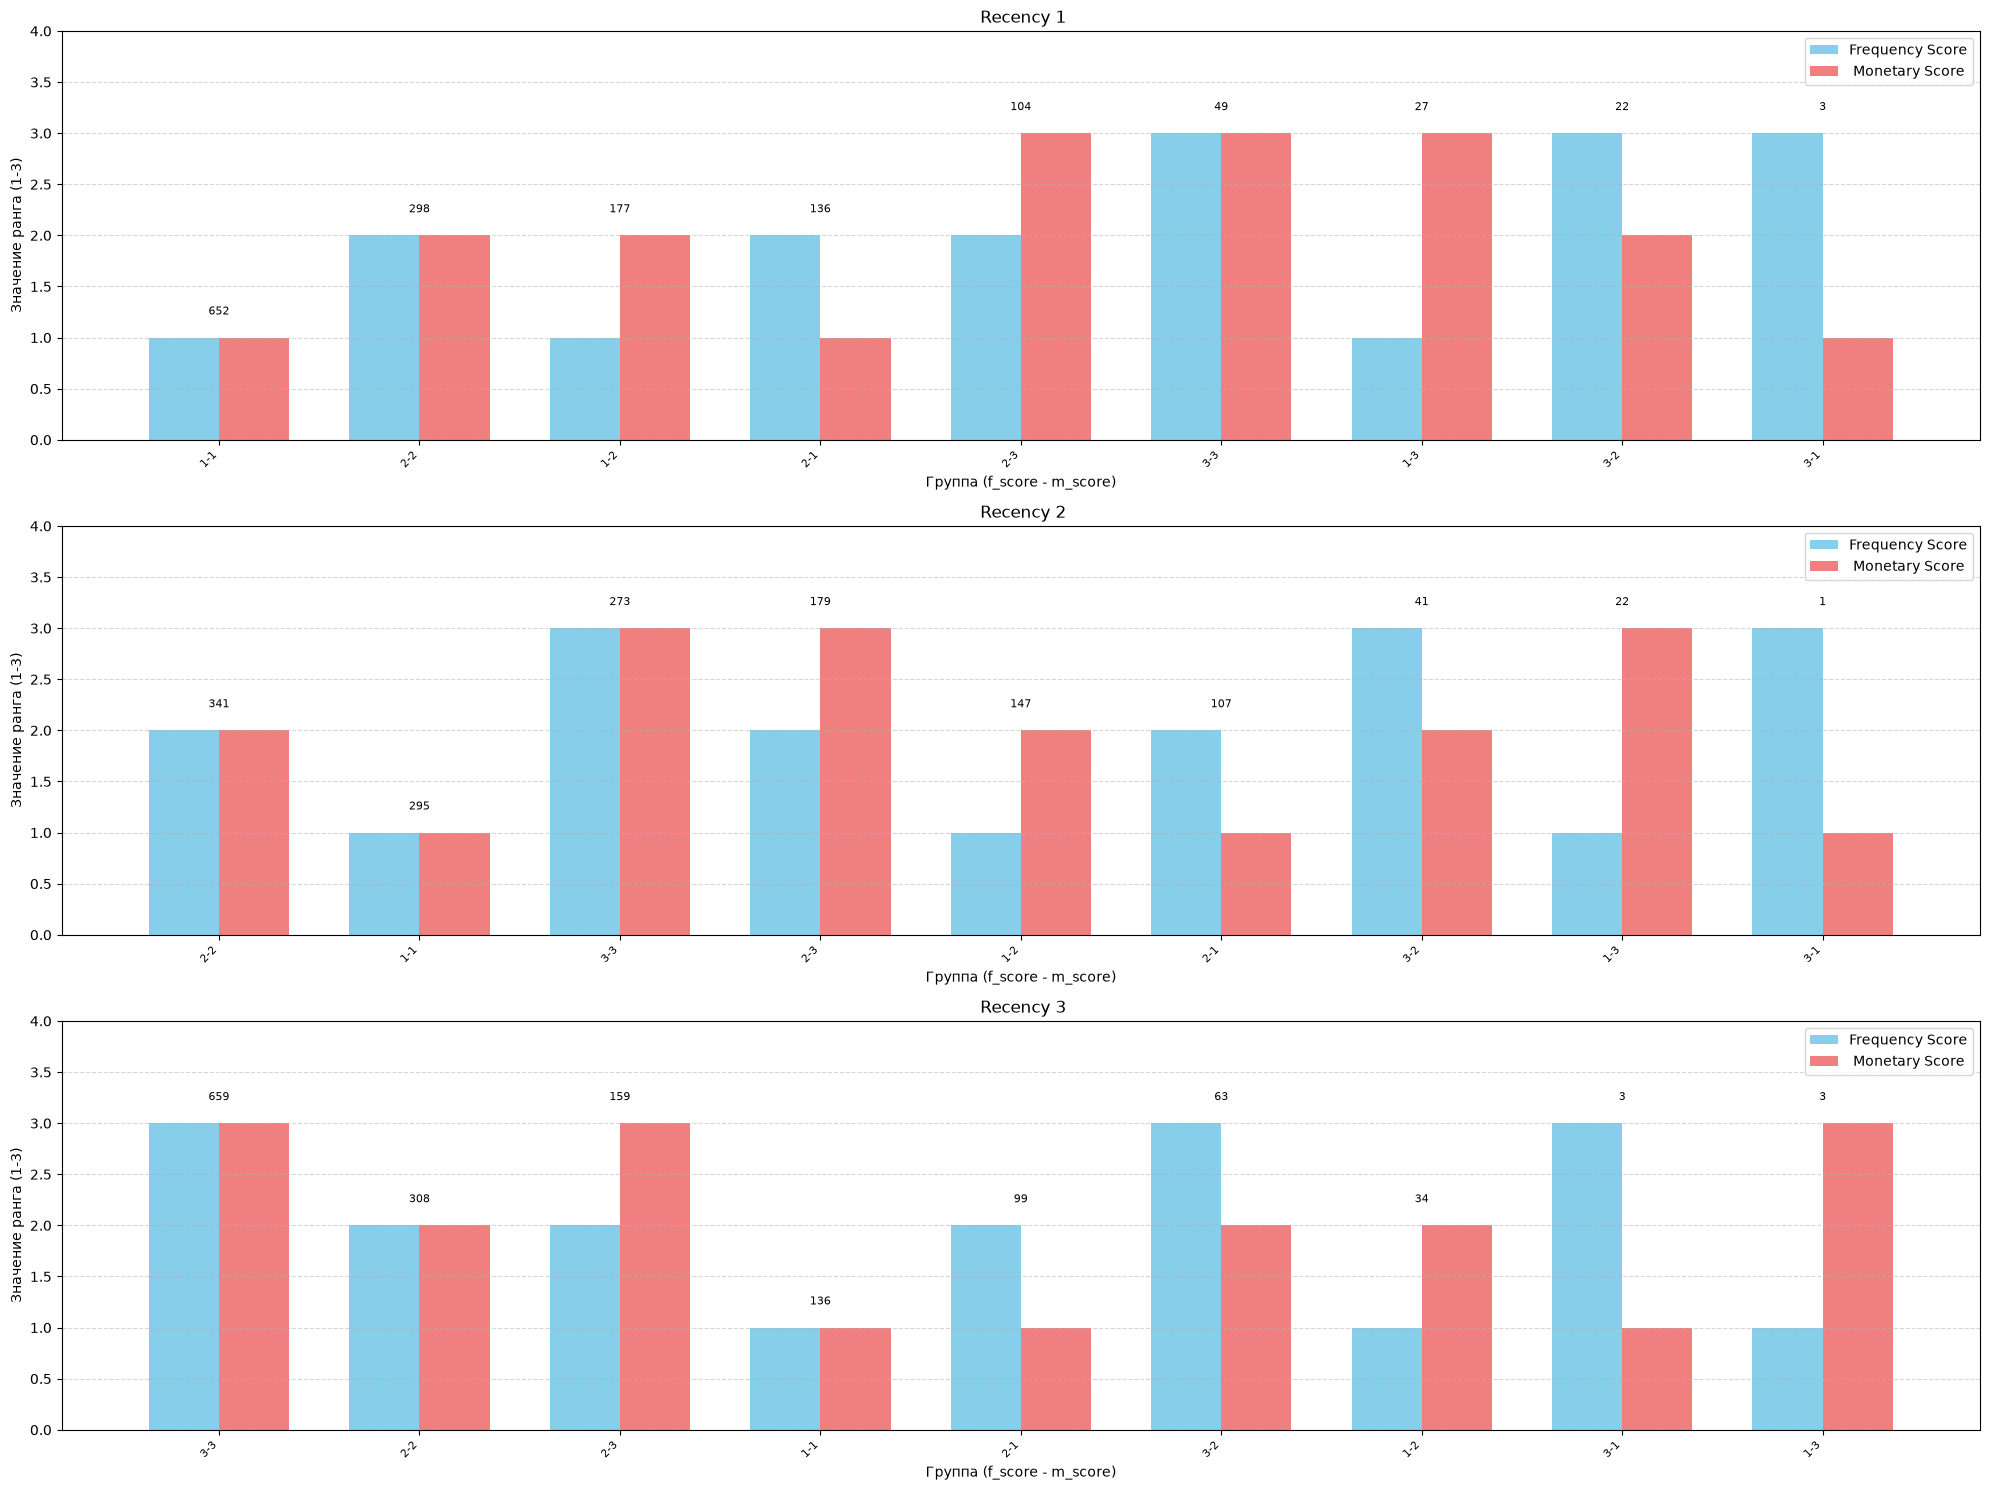

In [113]:
# Подсчёт количества наблюдений в группах
rfm_counts = customer_df.groupby(['m_score', 'f_score', 'r_score']).size().reset_index(name='count')

fig, axes = plt.subplots(3, 1, figsize=(20, 15)) 

for idx, m in enumerate(sorted(customer_df['r_score'].unique())):
    ax = axes[idx]
    data = rfm_counts[rfm_counts['r_score'] == m].sort_values(['count'], ascending=[False])
    
    # Подготовка данных
    groups = [f"{row['f_score']}-{row['m_score']}" for _, row in data.iterrows()]
    counts = data['count'].values
    r_vals = data['f_score'].values
    f_vals = data['m_score'].values
    
    x_pos = np.arange(len(groups))
    bar_width = 0.35
    
    # Вертикальные столбцы
    ax.bar(x_pos - bar_width/2, r_vals, width=bar_width, color='skyblue', label='Frequency Score')
    ax.bar(x_pos + bar_width/2, f_vals, width=bar_width, color='lightcoral', label=' Monetary Score')
    
    # Подписи количества клиентов над столбцами (по центру группы)
    for i, (count, r, f) in enumerate(zip(counts, r_vals, f_vals)):
        ax.text(i, max(r, f) + 0.2, f'{count}', ha='center', va='bottom', fontsize=8)
    
    # Настройка осей
    ax.set_xticks(x_pos)
    ax.set_xticklabels(groups, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Значение ранга (1-3)', fontsize=10)
    ax.set_xlabel('Группа (f_score - m_score)', fontsize=10)
    ax.set_title(f" Recency {m}", fontsize=12)
    ax.set_ylim(0, 4) 
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Визуализация сегментов

На круговой диаграмме представлено распределение клиентов по топ-15 сегментам. Оставшиеся 12 сегментов объединены в категорию «Остальные» (около 18% клиентов). Это позволяет сфокусироваться на наиболее значимых группах.

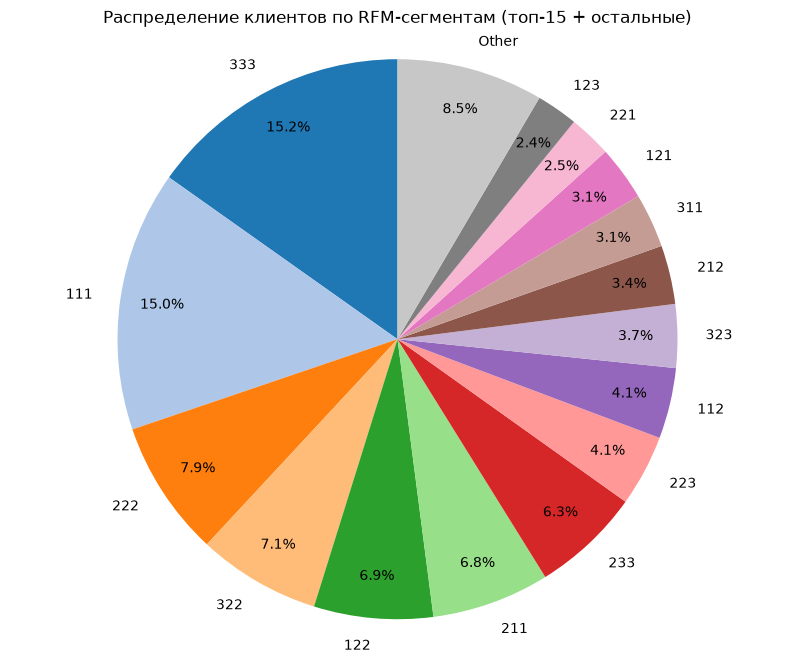

Топ сегментов:
RFM_segment
333    659
111    652
222    341
322    308
122    298
211    295
233    273
223    179
112    177
323    159
212    147
311    136
121    136
221    107
123    104
Name: count, dtype: int64

Остальные (12 сегментов): 367 клиентов


In [114]:
# Создаём комбинированный сегмент
# customer_df['segment'] = (
#     customer_df['r_score'].astype(str) + '-' +
#     customer_df['f_score'].astype(str) + '-' +
#     customer_df['m_score'].astype(str)
# )

# Подсчитываем количество клиентов в каждом сегменте
seg_counts = customer_df['RFM_segment'].value_counts()

# Выбираем топ-15 самых крупных сегментов
top_n = 15
top_segments = seg_counts.head(top_n)
other_count = seg_counts[top_n:].sum()

# цвета из палитры и преобразуем в список
colors = list(plt.cm.tab20.colors[:top_n+1])

# Строим диаграмму
plt.figure(figsize=(10, 8))
plt.pie(list(top_segments.values) + [other_count], labels=list(top_segments.index) + ['Other'], autopct='%1.1f%%', colors=colors, startangle=90, pctdistance=0.85)
plt.title(f'Распределение клиентов по RFM-сегментам (топ-{top_n} + остальные)')
plt.axis('equal')
plt.show()

print("Топ сегментов:")
print(top_segments.T)
print(f"\nОстальные ({len(seg_counts)-top_n} сегментов): {other_count} клиентов")

### Выводы по RFM-сегментации

1. **Клиентская база поляризована:** примерно 30% клиентов относятся к двум крайним сегментам (3-3-3 и 1-1-1).
2. **Топ сегментов:** Топ-7 сегментов охватывают около **63%** всех клиентов, а топ-15 – около **82%**. Это означает, что основная масса клиентов сосредоточена в относительно небольшом числе сегментов, что упрощает разработку целевых стратегий. Также это может означать что кластеризации клиентов другими методами даст более точный результат.
3. **Необходимость углублённого анализа:** RFM-сегменты дают хорошее первичное представление, но для выработки более точных стратегий требуется дополнительное изучение каждого сегмента с учётом других переменных (средний чек, разнообразие товаров, чувствительность к скидкам).

**Дальнейшие шаги:** Мы перейдём к кластеризации клиентов, чтобы выделить более однородные группы и проверить, насколько полученные кластеры согласуются с RFM-сегментами.

### **Дополнительный кластерный анализ**

#### План действий
1. Визуализация данных в пространстве RFM – 3D и попарные графики с цветом по RFM-сегментам.

2. Стандартизация (StandardScaler) для методов, чувствительных к масштабу.

3. Подбор оптимального числа кластеров для KMeans (метод локтя, силуэт).

4. Применение KMeans, Agglomerative и сравнение результатов.

5. Визуализация кластеров (PCA) и интерпретация.

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import dendrogram, linkage


###  Визуализация распределения RFM-переменных с цветом по сегментам

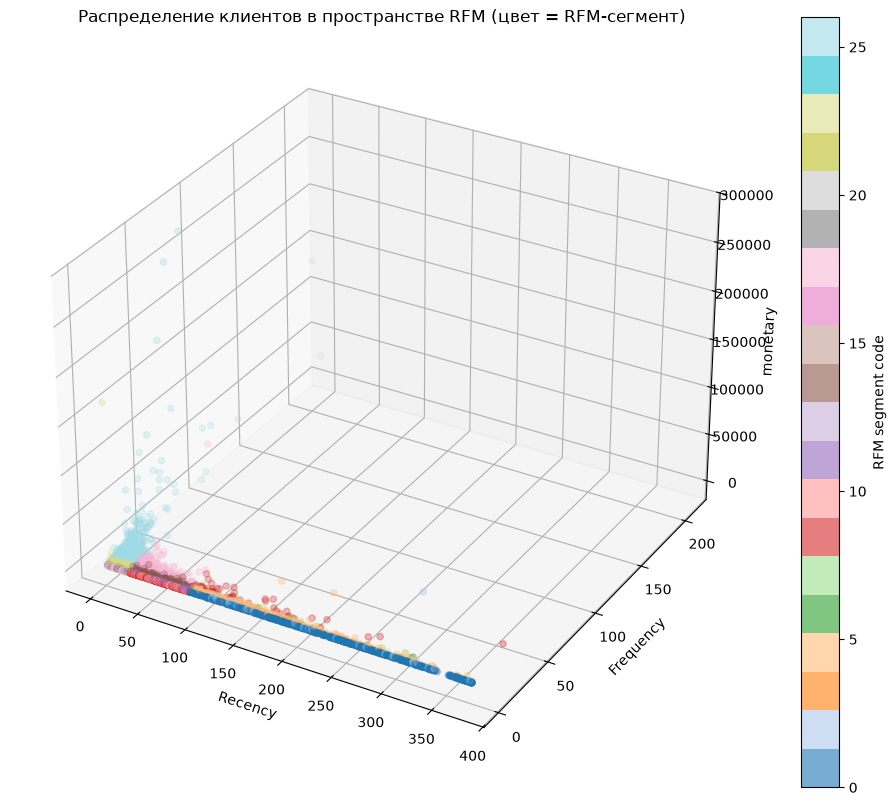

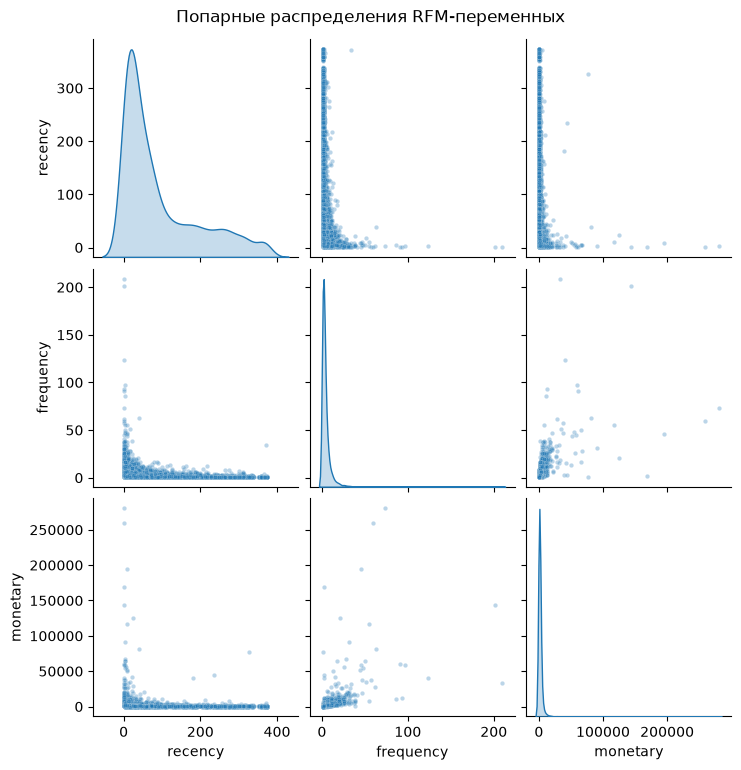

In [116]:
# Создаём числовую метку сегмента для цветовой кодировки
segments = customer_df['RFM_segment'].astype('category')
seg_codes = segments.cat.codes

# 3D график
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(customer_df['recency'], customer_df['frequency'], customer_df['monetary'], c=seg_codes, cmap='tab20', alpha=0.6, s=20)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('monetary')
ax.set_title('Распределение клиентов в пространстве RFM (цвет = RFM-сегмент)')
plt.colorbar(sc, label='RFM segment code')
plt.show()

# Pairplot (2D попарные графики)
g = sns.pairplot(customer_df[['recency','frequency','monetary']], diag_kind='kde', plot_kws={'alpha':0.3, 's':10})
g.fig.suptitle('Попарные распределения RFM-переменных', y=1.02)
plt.show()

### Исходная структура данных

Перед применением методов кластеризации мы визуализировали распределение клиентов в трёхмерном пространстве RFM.

1. **Сильный правый хвост.** На 3D-графике и pairplot видно, что основная масса клиентов сконцентрирована вблизи начала координат (низкие значения frequency и monetary, средние recency). Отдельные точки («супер-клиенты») находятся далеко в хвосте, создавая видимый «разрыв» между основной массой и выбросами.

2. **Различные масштабы.** Переменные имеют сильно отличающиеся диапазоны значений:
   - Recency: 1–374 дня
   - Frequency: 1–209 заказов
   - Monetary: 3.75–280 206 ₽

   Это означает, что monetary будет доминировать в расчётах расстояний, если не провести стандартизацию.

3. **Форма облака точек.** Данные не образуют сферических кластеров, скорее напоминают «комету» с плотным ядром и длинным хвостом. Это важно для выбора метода кластеризации.

4. **Неравномерная плотность.** Основная масса клиентов сосредоточена в одном регионе, а частые экстремальные значения создают разреженные области. Алгоритмы, чувствительные к плотности (например, DBSCAN), могут не дать хорошего результата без предварительной обработки.

**Вывод:** Прямое применение кластеризации к исходным данным приведёт к тому, что алгоритмы либо «не заметят» структуру в основной массе (из-за доминирования выбросов), либо выделят отдельные кластеры из крайних точек, оставив основную массу в одном большом кластере. Поэтому перед кластеризацией необходимо **отделить суперэлиту** и, при необходимости, рассмотреть трансформацию переменных.

## Отделение элиты

### Выделение суперэлиты (экстремальных значений)

Для отделения суперэлиты мы использовали **правило IQR с множителем 3** (межквартильный размах). Это статистически обоснованный метод, устойчивый к выбросам.

**Расчёт границ:**
- Monetary: Q1 = 306.5, Q3 = 1660.6, IQR = 1354.1. Верхняя граница: 1660.6 + 3 × 1354.1 = **5723**
- Frequency: Q1 = 1, Q3 = 5, IQR = 4. Верхняя граница: 5 + 3 × 4 = **17 заказов**

**Почему пересечение, а не объединение?**
- Если взять только monetary (> 5723), в группу попадают 222 клиента, включая тех, кто сделал одну крупную покупку и больше не возвращался (recency до 326 дней).
- Если взять только frequency (> 17 заказов), в группу попадают 133 клиента, включая тех, кто делает много мелких покупок, но не обязательно с высокими тратами.
- **Пересечение условий** (monetary > 5723 И frequency > 17 заказов) даёт 105 клиентов, которые сочетают высокую частоту и высокие траты — **VIP**.

In [117]:
# Вычисляем квартили и IQR для monetary и frequency
def find_iqr_threshold(data, multiplier=1.5, side='upper'):
    """
    Находит порог для выбросов по правилу IQR.
    side: 'upper' — только верхняя граница, 'both' — обе границы.
    """
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    upper_bound = Q3 + multiplier * IQR
    lower_bound = Q1 - multiplier * IQR
    
    if side == 'upper':
        return upper_bound
    elif side == 'both':
        return lower_bound, upper_bound
    else:
        return lower_bound, upper_bound

# Для monetary
upper_monetary = find_iqr_threshold(customer_df['monetary'].values, multiplier=3, side='upper')
print(f"Monetary: Q1={np.percentile(customer_df['monetary'], 25):.2f}, Q3={np.percentile(customer_df['monetary'], 75):.2f}, IQR={np.percentile(customer_df['monetary'], 75) - np.percentile(customer_df['monetary'], 25):.2f}")
print(f"Верхняя граница (3×IQR): {upper_monetary:.2f}")

# Для frequency
upper_frequency = find_iqr_threshold(customer_df['frequency'].values, multiplier=3, side='upper')
print(f"\nFrequency: Q1={np.percentile(customer_df['frequency'], 25):.0f}, Q3={np.percentile(customer_df['frequency'], 75):.0f}, IQR={np.percentile(customer_df['frequency'], 75) - np.percentile(customer_df['frequency'], 25):.0f}")
print(f"Верхняя граница (3×IQR): {upper_frequency:.0f}")

# Количество клиентов, попадающих в суперэлиту
n_elite_monetary = (customer_df['monetary'] > upper_monetary).sum()
n_elite_frequency = (customer_df['frequency'] > upper_frequency).sum()
n_elite_combined = ((customer_df['monetary'] > upper_monetary) | (customer_df['frequency'] > upper_frequency)).sum()

print(f"\nКоличество клиентов-суперэлиты по monetary (> {upper_monetary:.2f}): {n_elite_monetary}")
print(f"Количество клиентов-суперэлиты по frequency (> {upper_frequency:.0f}): {n_elite_frequency}")
print(f"Количество клиентов-суперэлиты (объединённое условие): {n_elite_combined}")

Monetary: Q1=306.48, Q3=1660.60, IQR=1354.11
Верхняя граница (3×IQR): 5722.94

Frequency: Q1=1, Q3=5, IQR=4
Верхняя граница (3×IQR): 17

Количество клиентов-суперэлиты по monetary (> 5722.94): 222
Количество клиентов-суперэлиты по frequency (> 17): 133
Количество клиентов-суперэлиты (объединённое условие): 250


In [118]:
# Выделение суперэлиты на основе IQR (3×)

# Создаём метку
customer_df['is_super_elite'] = ((customer_df['monetary'] > upper_monetary) & 
                                 (customer_df['frequency'] > upper_frequency)).astype(int)

print(f"Суперэлита: {customer_df['is_super_elite'].sum()} клиентов ({customer_df['is_super_elite'].mean()*100:.1f}%)")
print(f"Обычные клиенты: {(customer_df['is_super_elite'] == 0).sum()} клиентов")

display(customer_df.groupby('is_super_elite')[['frequency', 'monetary']].describe().round(2))

Суперэлита: 105 клиентов (2.4%)
Обычные клиенты: 4233 клиентов


frequency                                               \
                   count   mean    std   min   25%   50%   75%    max   
is_super_elite                                                          
0                 4233.0   3.48   3.53   1.0   1.0   2.0   4.0   39.0   
1                  105.0  36.01  30.36  18.0  21.0  26.0  37.0  209.0   

               monetary                                                  \
                  count      mean       std      min      25%       50%   
is_super_elite                                                            
0                4233.0   1390.22   3768.97     3.75   302.10    646.68   
1                 105.0  28594.37  45383.27  5781.73  8134.94  13027.45   

                                     
                     75%        max  
is_super_elite                       
0                1540.42  168472.50  
1               26626.80  280206.02

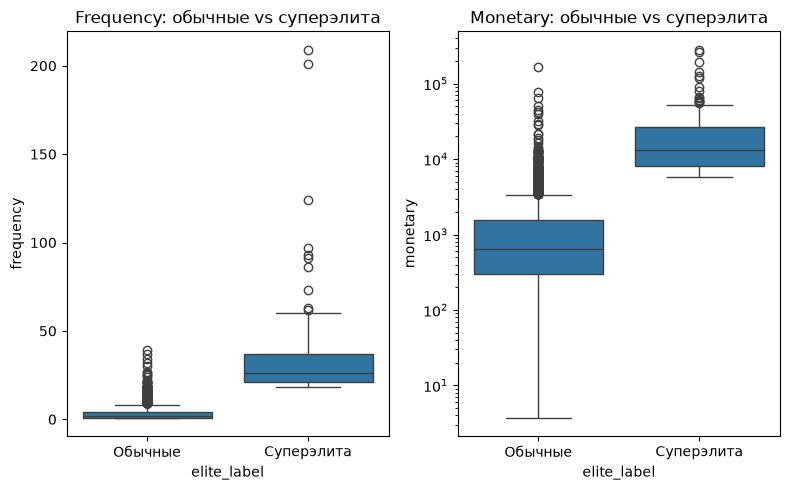

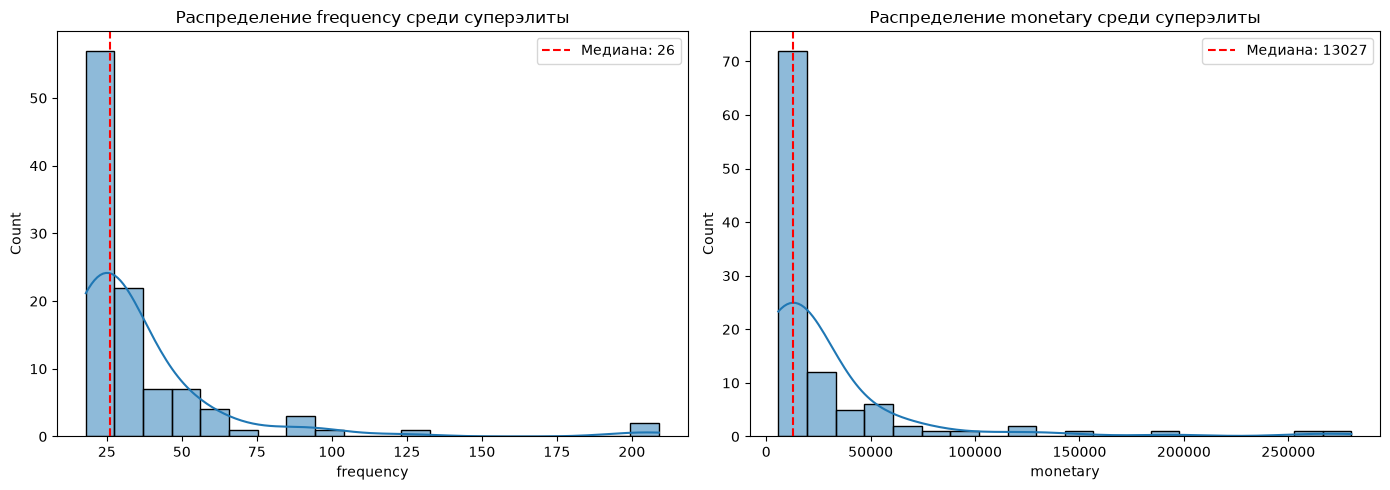

In [119]:
# Boxplot для frequency и monetary

# Создаём копию с категориальной меткой
customer_df['elite_label'] = customer_df['is_super_elite'].map({0: 'Обычные', 1: 'Суперэлита'})

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

sns.boxplot(x='elite_label', y='frequency', data=customer_df, ax=axes[0])
axes[0].set_title('Frequency: обычные vs суперэлита')

sns.boxplot(x='elite_label', y='monetary', data=customer_df, ax=axes[1])
axes[1].set_title('Monetary: обычные vs суперэлита')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()


# Распределение суперэлиты по частоте и monetary (гистограммы)

# Только суперэлита
elite = customer_df[customer_df['is_super_elite'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(elite['frequency'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Распределение frequency среди суперэлиты')
axes[0].axvline(elite['frequency'].median(), color='red', linestyle='--', label=f'Медиана: {elite["frequency"].median():.0f}')
axes[0].legend()

sns.histplot(elite['monetary'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('Распределение monetary среди суперэлиты')
axes[1].axvline(elite['monetary'].median(), color='red', linestyle='--', label=f'Медиана: {elite["monetary"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

**Сравнение групп:**
- VIP: 105 клиентов (2.4% от всей базы)
- Обычные клиенты: 4233 клиента (97.6% от всей базы)

| Показатель | Обычные клиенты | VIP | Разница |
|------------|----------------|------------|---------|
| Frequency (среднее) | 3.5 | 36.0 | **в 10 раз** |
| Monetary (среднее) | 1,390 | 28,594 | **в 20 раз** |
| Recency (медиана) | 53 дня | 4 дня | **элита значительно активнее** |

VIP — это клиенты, которые:
- Делают в среднем 36 заказов (против 3.5 у обычных)
- Тратят в среднем 28,594 (против 1,390 у обычных)
- Почти все совершили последнюю покупку в течение последней недели (recency медиана 4 дня)

**Решение:** VIP будет выделена в отдельную группу и исключена из основной кластеризации, чтобы не искажать структуру остальных клиентов.

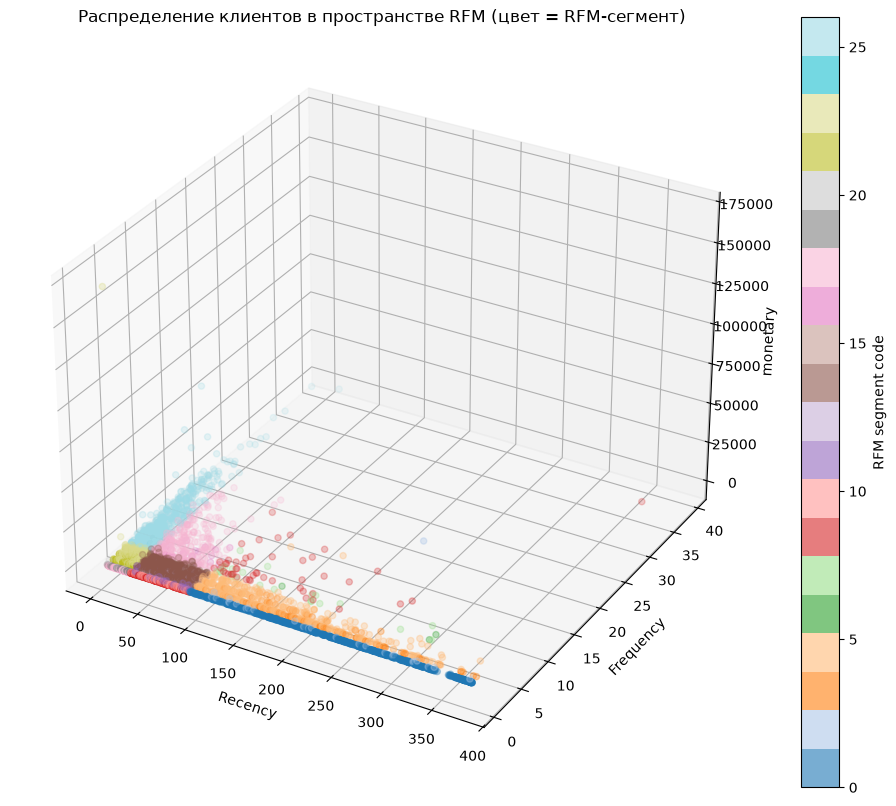

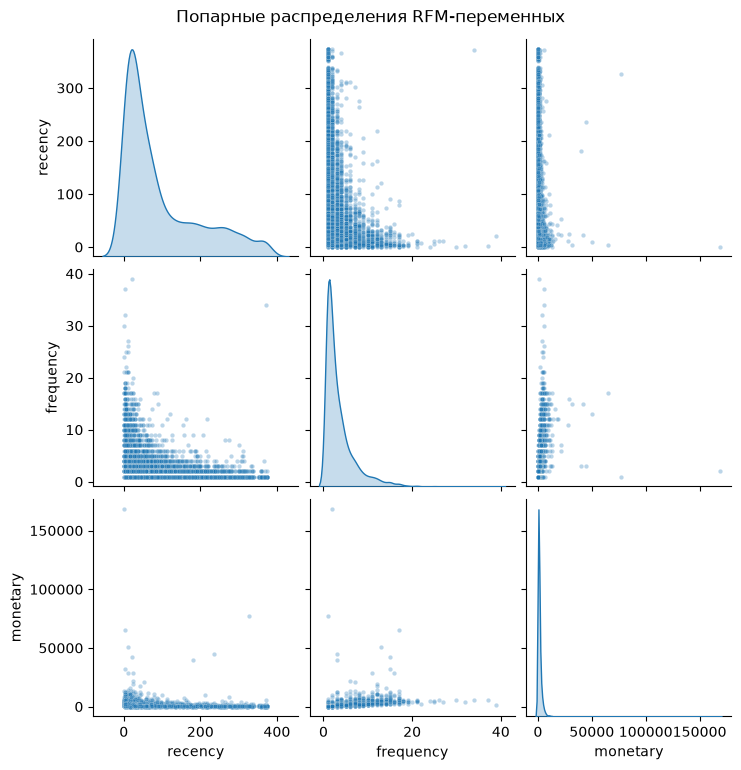

In [120]:
# ------- Тот же график, но без VIP
segments = customer_df[customer_df['is_super_elite']==0]['RFM_segment'].astype('category')
seg_codes = segments.cat.codes

# 3D график
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(customer_df[customer_df['is_super_elite']==0]['recency'], customer_df[customer_df['is_super_elite']==0]['frequency'], customer_df[customer_df['is_super_elite']==0]['monetary'], 
                c=seg_codes, cmap='tab20', alpha=0.6, s=20)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('monetary')
ax.set_title('Распределение клиентов в пространстве RFM (цвет = RFM-сегмент)')
plt.colorbar(sc, label='RFM segment code')
plt.show()

# Pairplot 
g = sns.pairplot(customer_df[customer_df['is_super_elite']==0][['recency','frequency','monetary']], diag_kind='kde', plot_kws={'alpha':0.3, 's':10})
g.fig.suptitle('Попарные распределения RFM-переменных', y=1.02)
plt.show()

### Подбор числа кластеров для KMeans

In [121]:
# Подготовка данных (без VIP)

rfm_cols = ['recency', 'frequency', 'monetary']

# Данные без VIP (сохраняем все колонки для дальнейшего анализа)
customer_df_usual = customer_df[customer_df['is_super_elite'] == 0].copy()
X_rfm = customer_df_usual[rfm_cols].copy()

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfm)

print(f"Размер данных: {X_scaled.shape[0]} клиентов")
print(f"Переменные: {rfm_cols}")

Размер данных: 4233 клиентов
Переменные: ['recency', 'frequency', 'monetary']


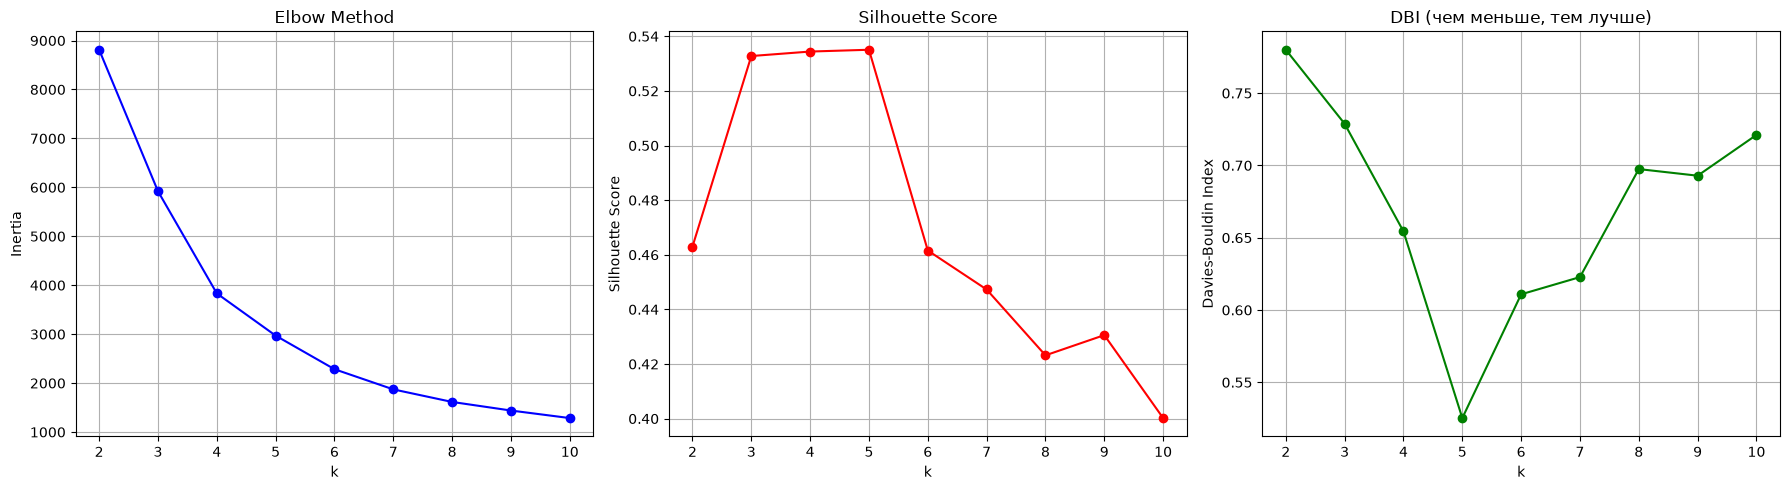

In [122]:
# 1. Подбор оптимального k для KMeans (Elbow, Silhouette, DBI)

inertia = []
sil_scores = []
dbi_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].grid(True)

axes[2].plot(K_range, dbi_scores, 'go-')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('DBI (чем меньше, тем лучше)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

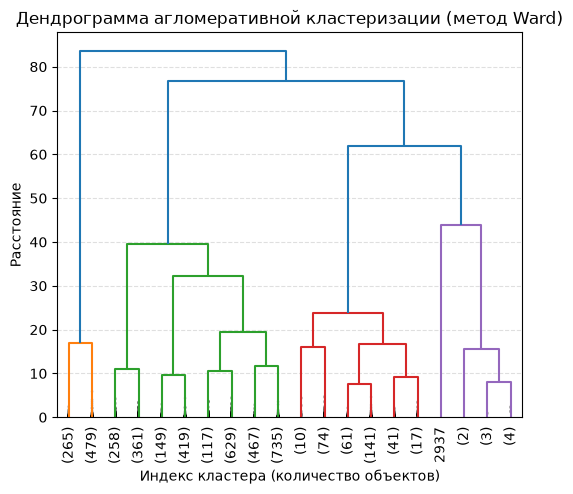

In [123]:
# Используем стандартизированные данные (X_scaled) без суперэлиты
# Строим матрицу связей методом Ward (минимизирует внутрикластерную дисперсию)
linked = linkage(X_scaled, method='ward')

# Построение дендрограммы
plt.figure(figsize=(6, 5))
dendrogram(linked,
           truncate_mode='lastp',    # показываем только последние p слияний
           p=20,                     # число показываемых кластеров
           show_leaf_counts=True,    # показываем количество объектов в листьях
           leaf_rotation=90.,
           leaf_font_size=10.,
           show_contracted=True)     # сжимаем длинные ветки для наглядности
plt.title('Дендрограмма агломеративной кластеризации (метод Ward)')
plt.xlabel('Индекс кластера (количество объектов)')
plt.ylabel('Расстояние')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# === Возможное число кластеров: 2, 3, 4, 5, 6 и т.д.

### Выбор метода и числа кластеров

Для кластеризации клиентов (без суперэлиты) мы сравнили два метода: **KMeans** и **Agglomerative**. Для каждого метода были протестированы варианты с 3, 4, 5 и 6 кластерами. Оценка производилась по трём критериям:

1. **Silhouette Score** — оценивает компактность и разделимость кластеров. Чем выше, тем лучше. (Пик при 5 класетрах)
2. **Davies-Bouldin Index (DBI)** — отношение внутрикластерного разброса к межкластерному. Чем ниже, тем лучше (Так же пик при 5 кластерах).
3. **Коэффициент Крамера (Cramér's V)** — показывает (оценивает силу связи категориальных переменных), насколько кластеры согласуются с RFM-сегментами. Чем выше, тем лучше.

In [124]:
# # Функция для расчета коэффициента Крамера V
def cramers_v(confusion_matrix):
    """Рассчитывает коэффициент Крамера V для таблицы сопряженности."""
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

In [125]:
# 2. Перебор методов и количества кластеров, вычисление Cramér's V

# Список методов и значений k для тестирования
methods = ['KMeans', 'Agglomerative']
k_values = [3, 4, 5, 6]   # --- количество кластеров.  

results = []

for method in methods:
    for k in k_values:
        if method == 'KMeans':
            model = KMeans(n_clusters=k, random_state=42, n_init=10)
        elif method == 'Agglomerative':
            model = AgglomerativeClustering(n_clusters=k)
        else:
            continue
        
        # Кластеризация
        labels = model.fit_predict(X_scaled)
        
        # Сохраняем метки во временный датафрейм для расчёта Cramér's V
        temp_df = X_rfm.copy()
        temp_df['cluster'] = labels
        temp_df['RFM_segment'] = customer_df_usual['RFM_segment'].values  # добавляем RFM-сегмент
        
        # Таблица сопряжённости
        cross_tab = pd.crosstab(temp_df['RFM_segment'], temp_df['cluster'])
        
        # Расчёт Cramér's V
        cramer_v = cramers_v(cross_tab)
        
        # Дополнительные метрики (для информации)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1) if -1 in labels else 0
        sil = silhouette_score(X_scaled, labels) if n_clusters > 1 else np.nan
        dbi = davies_bouldin_score(X_scaled, labels) if n_clusters > 1 else np.nan
        
        results.append({
            'method': method,
            'k': k,
            'cramers_v': cramer_v,
            'silhouette': sil,
            'dbi': dbi,
            'n_clusters': n_clusters,
            'noise': n_noise
        })

# Сводная таблица результатов
results_df = pd.DataFrame(results)
print("\n=== Сравнение методов и числа кластеров ===")
display(results_df[['method', 'k', 'cramers_v', 'silhouette', 'dbi']].sort_values(by='cramers_v',ascending=False).round(3))


=== Сравнение методов и числа кластеров ===


,method,k,cramers_v,silhouette,dbi
0,KMeans,3,0.761,0.533,0.729
4,Agglomerative,3,0.648,0.523,0.707
1,KMeans,4,0.644,0.534,0.654
2,KMeans,5,0.558,0.535,0.525
7,Agglomerative,6,0.552,0.404,0.624
3,KMeans,6,0.551,0.462,0.611
5,Agglomerative,4,0.530,0.520,0.628
6,Agglomerative,5,0.459,0.521,0.497


#### Результаты сравнения

| Метод | k | Интерпретация |
|-------|---|---------------|
| **KMeans** | **3** |  **Чёткие, бизнес-логичные кластеры** |
| KMeans | 4 |Появляется микро-кластер (7 клиентов) |
| KMeans | 5 | Ещё больше дробление, кластер с 1 клиентом |
| Agglomerative | 3 | Менее чёткое разделение, уступает KMeans |
| Agglomerative | 4 | Значительное падение Cramér's V |
| Agglomerative | 5 | Низкая согласованность с RFM |

#### Почему KMeans с k=3 

1. **Наивысшая согласованность с RFM (Cramér's V = 0.761).** Это означает, что кластеры максимально точно отражают бизнес-логику, заложенную в RFM-сегментах.

2. **Стабильность и интерпретируемость.** Три кластера имеют чёткие характеристики, которые легко использовать. При k=4 и k=5 появляются микро-кластеры с 1–7 клиентами.

3. **Баланс метрик.** Хотя k=5 даёт немного лучший Silhouette и DBI, разница незначительна, а интерпретация сильно ухудшается.

In [126]:
# Выбираем метод и k
best_method = 'KMeans'
best_k =3
print(f"\nЛучший вариант: {best_method} с k={best_k}")

# Применяем лучший метод ко всем данным (без суперэлиты)
if best_method == 'KMeans':
    final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
else:
    final_model = AgglomerativeClustering(n_clusters=best_k)

final_labels = final_model.fit_predict(X_scaled)
customer_df_usual['cluster_final'] = final_labels

#  Рассчитываем статистики для кластеров
cluster_stats = customer_df_usual.groupby('cluster_final').agg({
    'CustomerID': 'count',  # количество клиентов в кластере
    'recency': ['min', 'median', 'max'],
    'frequency': ['min', 'median', 'max'],
    'monetary': ['min', 'median', 'max'],
}).round(2)

# Переименовываем колонки для удобства
cluster_stats.columns = ['_'.join(col).strip() for col in cluster_stats.columns.values]
cluster_stats = cluster_stats.rename(columns={'CustomerID_count': 'n_clients'})

(cluster_stats.sort_values(by='recency_median',ascending=False))


Лучший вариант: KMeans с k=3


,n_clients,recency_min,recency_median,recency_max,frequency_min,frequency_median,frequency_max,monetary_min,monetary_median,monetary_max
cluster_final,,,,,,,,,,
1,1049,142,246.0,374,1,1.0,8,3.75,308.58,9864.26
0,2675,1,37.0,169,1,2.0,8,6.20,692.19,11072.67
2,509,1,12.0,372,1,10.0,39,801.12,3711.77,168472.50


In [127]:
cluster_stats_elit = customer_df.groupby('is_super_elite').agg({
    'CustomerID': 'count',  # количество клиентов в кластере
    'recency': ['min', 'median', 'max'],
    'frequency': ['min', 'median', 'max'],
    'monetary': ['min', 'median', 'max'],
}).round(2)
cluster_stats_elit.columns = ['_'.join(col).strip() for col in cluster_stats_elit.columns.values]
display(cluster_stats_elit)

,CustomerID_count,recency_min,recency_median,recency_max,frequency_min,frequency_median,frequency_max,monetary_min,monetary_median,monetary_max
is_super_elite,,,,,,,,,,
0,4233,1,53.0,374,1,2.0,39,3.75,646.68,168472.50
1,105,1,4.0,39,18,26.0,209,5781.73,13027.45,280206.02


### Описание финальных кластеров (KMeans, k=3)

| Кластер | Название | Размер | Recency (мед) | Frequency (мед) | Monetary (мед) | Характеристика |
|---------|----------|--------|---------------|-----------------|----------------|----------------|
| **1** | **Потерянные** | 1049 | 246 дней | 1 заказ | 308 | Давно не покупали, мало заказов, маленькие чеки. |
| **0** | **Середняки** | 2675 | 37 дней | 2 заказа | 692 | Основная масса клиентов. Умеренная активность. Стимулируем к более частым покупкам. |
| **2** | **Активные** | 509 | 12 дней | 10 заказов | 3 712 | Наиболее ценные клиенты. Активно покупают, высокие чеки. Требуют развития и удержания. |
 **3** | **VIP** | 105 | 4 дней | 26 заказов | 13 027 | VIP |

### Сравнение кластеризации на полных данных (включая суперэлиту) 
**ИЛИ был ли смысл отделять VIP докластеризации?**
(Код анализа анологичный, опущен для краткости. Приведены результаты. )

Для проверки гипотезы о необходимости отделения суперэлиты, мы провели кластеризацию на всех 4338 клиентах (без предварительной фильтрации). Ниже приведены результаты для наилучшего варианта из перебора — **KMeans с k = 3**.

| Кластер | Размер | Recency (медиана) | Frequency (медиана) | Monetary (медиана) | Интерпретация |
|---------|--------|-------------------|---------------------|--------------------|---------------|
| **Потерянные** | 1082 | 242 дня | 1 заказ | 310 | Давние, редкие, мелкие — классический отток |
| **Смешанный** | 3230 | 30 дней | 3 заказа | 916 | Явная смесь середнячков и активных клиентов |
| **Элита** | 26 | 3.5 дня | 53 заказа | 59697 | Экстремальные выбросы с уникальным поведением |


1. **Потеря важной градации.** Кластер «Смешанный» объединил большую часть клиентов, стирая разницу между среднестатистическими покупателями и активными клиентами. Это снижает практическую ценность сегментации — для этих двух групп требуются разные маркетинговые стратегии.

2. **Смешение внутри элиты.** Кластер «Элита» - 26 клиентов. Судя по малой численности и статистикам выделены только наиолее "экстремальные" наблюдения, остальная элита также смешана со среднм кластером.  

#### Вывод

Кластеризация на полных данных приводит к **смешиванию разнородных групп** и потере важных бизнес-различий. Предварительное выделение суперэлиты (105 клиентов) позволяет:

- Чётко разделить основную массу на три однородные группы.
- Получить более высокую согласованность с RFM (0.761).
- Разработать отдельные стратегии для суперэлиты, не смешивая её с другими клиентами.

##### **Отделение суперэлиты с помощю IQR + кластеризация основной массы даёт более интерпретируемые для бизнес-задач группы клентов.**

### Объединение кластеров и суперэлиты в единую таблицу.
**Сменим порядок нумерации кластеров в соответствии с их ценностью для бизнеса**

In [128]:
# Объединение кластеров и суперэлиты в единую таблицу

# 1. Копируем полный датафрейм
all_customers = customer_df.copy()

# 2. Добавляем колонку cluster_final, по умолчанию NaN
all_customers['cluster_final'] = np.nan

# 3. Заполняем для обычных клиентов (is_super_elite == 0)
mask_usual = all_customers['is_super_elite'] == 0
all_customers.loc[mask_usual, 'cluster_final'] = customer_df_usual['cluster_final'].values

# 4. Заполняем для суперэлиты (is_super_elite == 1)
all_customers.loc[all_customers['is_super_elite'] == 1, 'cluster_final'] = 3  # выделяем отдельный номер

# Создаём маппинг для правильного порядка
cluster_mapping = {
    1: 0, 
    0: 1,  
    2: 2,  
    3: 3   
}

all_customers['cluster_final'] = all_customers['cluster_final'].map(cluster_mapping)

# 5. Проверяем распределение
print("Распределение по кластерам (включая суперэлиту):")
print(all_customers['cluster_final'].value_counts().sort_index())

Распределение по кластерам (включая суперэлиту):
cluster_final
0    1049
1    2675
2     509
3     105
Name: count, dtype: int64


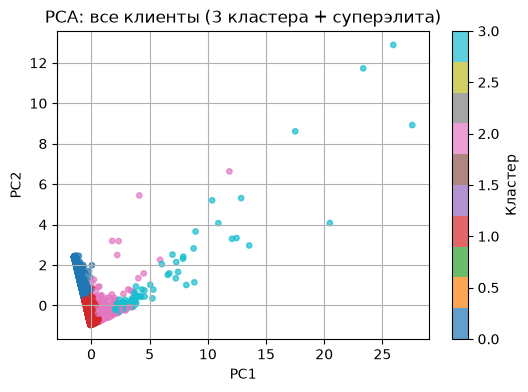

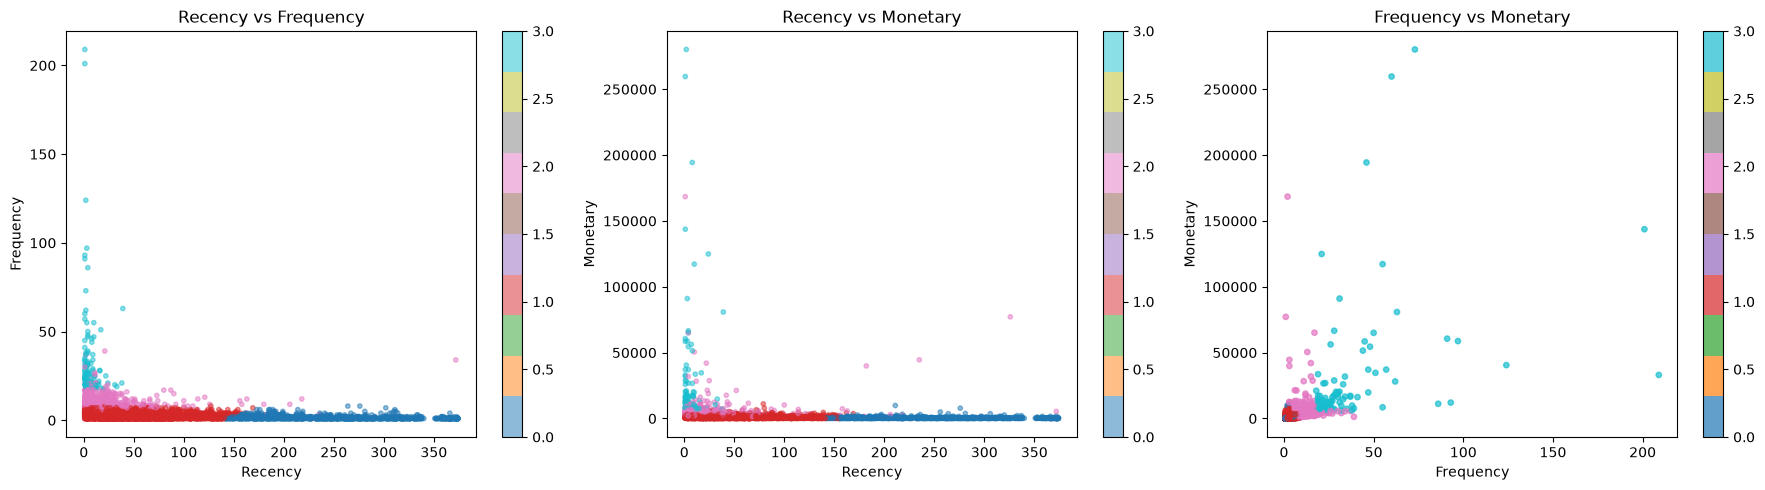

In [129]:
# Визуализация: PCA для всех 4 групп

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Данные для PCA
rfm_cols = ['recency', 'frequency', 'monetary']
X_all = all_customers[rfm_cols].copy()

# Стандартизация (лучше использовать тот же scaler, что и для кластеризации, но для общей визуализации можно заново)
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

# PCA
pca = PCA(n_components=2)
X_pca_all = pca.fit_transform(X_all_scaled)

# Построение графика
plt.figure(figsize=(6, 4))
scatter = plt.scatter(X_pca_all[:, 0], X_pca_all[:, 1], 
                      c=all_customers['cluster_final'], cmap='tab10', alpha=0.7, s=15)
plt.colorbar(scatter, label='Кластер')
plt.title('PCA: все клиенты (3 кластера + суперэлита)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

# Визуализация: Scatter plots по парам переменных

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Recency vs Frequency
scatter1 = axes[0].scatter(all_customers['recency'], all_customers['frequency'], 
                           c=all_customers['cluster_final'], cmap='tab10', alpha=0.5, s=10)
axes[0].set_xlabel('Recency')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Recency vs Frequency')
plt.colorbar(scatter1, ax=axes[0])

# 2. Recency vs Monetary
scatter2 = axes[1].scatter(all_customers['recency'], all_customers['monetary'], 
                           c=all_customers['cluster_final'], cmap='tab10', alpha=0.5, s=10)
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')
axes[1].set_title('Recency vs Monetary')
plt.colorbar(scatter2, ax=axes[1])

# 3. Frequency vs Monetary
scatter3 = axes[2].scatter(all_customers['frequency'], all_customers['monetary'], 
                           c=all_customers['cluster_final'], cmap='tab10', alpha=0.7, s=15)
axes[2].set_xlabel('Frequency')
axes[2].set_ylabel('Monetary')
axes[2].set_title('Frequency vs Monetary')
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.show()

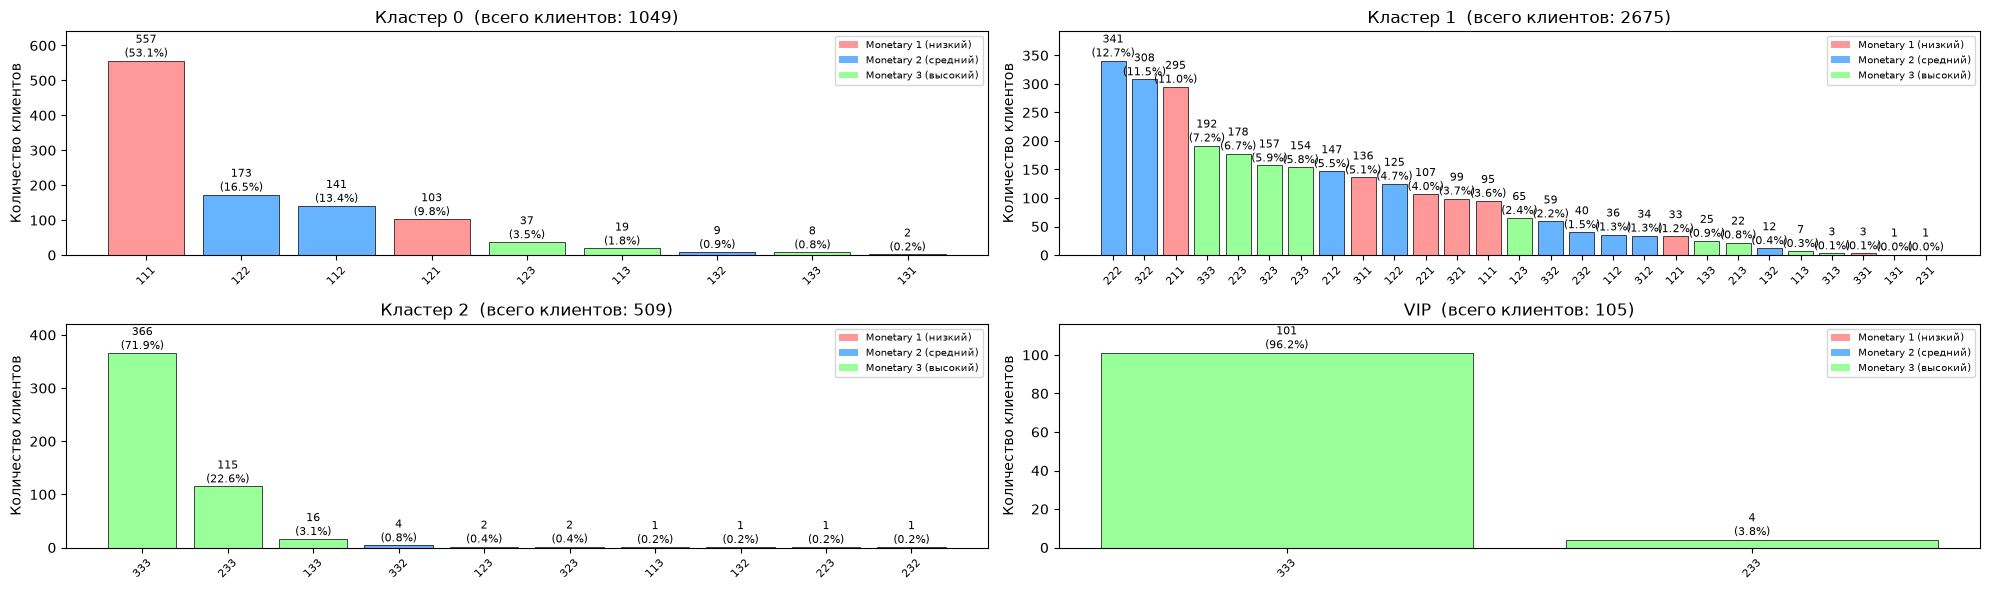

In [130]:
# Столбчатые диаграммы: состав кластеров по RFM-сегментам

# Группировка по кластеру и RFM-сегменту
cluster_segment_counts = all_customers.groupby(['cluster_final', 'RFM_segment']).size().reset_index(name='count')

# Цвета по первому символу сегмента (r_score)
r_colors = {'1': '#FF9999', '2': '#66B3FF', '3': '#99FF99'}

clusters = sorted(all_customers['cluster_final'].unique())
n_clusters = len(clusters)

fig, axes = plt.subplots(2, 2, figsize=(20, 6))
axes = axes.flatten()

for idx, cluster in enumerate(clusters):
    ax = axes[idx]
    data = cluster_segment_counts[cluster_segment_counts['cluster_final'] == cluster]
    data = data.sort_values('count', ascending=False)
    segments = data['RFM_segment'].values
    counts = data['count'].values
    total = counts.sum()
    pcts = (counts / total * 100).round(1)
    
    # Цвета для столбцов (по m_score)
    colors = [r_colors[seg[2]] for seg in segments]  # seg[2] — третий символ, m_score
    
    bars = ax.bar(segments, counts, color=colors, edgecolor='black', linewidth=0.5)
    
    # Подписи на столбцах
    for bar, cnt, pct in zip(bars, counts, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{cnt}\n({pct}%)', ha='center', va='bottom', fontsize=8)
    
    # Название кластера
    cluster_name = "VIP" if cluster == 3 else f"Кластер {cluster}"
    ax.set_title(f'{cluster_name}  (всего клиентов: {total})', fontsize=12)
    ax.set_ylabel('Количество клиентов', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_ylim(0, max(counts) * 1.15)
    
    # Легенда
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=r_colors['1'], label='Monetary 1 (низкий)'),
                       Patch(facecolor=r_colors['2'], label='Monetary 2 (средний)'),
                       Patch(facecolor=r_colors['3'], label='Monetary 3 (высокий)')]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=7)

plt.tight_layout()
plt.show()

#  0 == Среднячки
#  1 == Потерянные
#  2 == Активные
#  3 == VIP

### Интерпретация кластеров через RFM-сегменты

После объединения трёх кластеров и VIP в единую структуру, мы проанализировали RFM-состав каждой группы.


#### 1. Кластер 0 — «Потерянные» (1049 клиентов)

- **Состав:** на 53% состоит из сегмента `1-1-1` (давние, редкие, мелкие). Также присутствуют `1-2-2` (16.5%) и `1-1-2` (13.4%) — клиенты, которые когда-то имели средние показатели, но ушли.
- **Интерпретация:** это клиенты, которые либо всегда были неактивными, либо перестали покупать. Они имеют минимальную ценность для бизнеса в текущий момент.

---

#### 2. Кластер 1 — «Середняки» (2675 клиентов)

- **Состав:** наиболее разнородный. Крупнейшие сегменты: `2-2-2` (12.8%), `3-2-2` (11.5%), `2-1-1` (11.0%), `3-3-3` (7.2%). Здесь смешаны клиенты с разными уровнями recency, frequency и monetary.
- **Интерпретация:** это «серая масса» — основа клиентской базы. Часть из них уже активна (3-2-2, 3-3-3), часть — на грани оттока (2-1-1, 2-2-1). Группа неоднородна и требует более детального рассмотрения.

---

#### 3. Кластер 2 — «Активные» (509 клиентов)

- **Состав:** на **71.9%** состоит из сегмента `3-3-3` (недавние, частые, крупные) и на **22.6%** из `2-3-3` (средняя давность, но высокие частота и траты). Это наиболее ценные клиенты из основной массы.
- **Интерпретация:** ядро лояльной аудитории. Клиенты активны, совершают много покупок и тратят значительные суммы. Они уже имеют высокий уровень удовлетворённости и лояльности.
- **Стратегия:** удержание и развитие.
---

#### 4. Кластер 3 — «VIP (105 клиентов)

- **Состав:** **96.2%** — сегмент `3-3-3` и **3.8%** — `2-3-3`. Это абсолютные лидеры по всем показателям.
- **Интерпретация:** уникальная группа, выделенная по IQR-критерию (monetary > 5723 ₽ И frequency > 17 заказов). Эти клиенты находятся на грани выбросов и требуют эксклюзивного подхода.
- **Стратегия:** индивидуальное обслуживание.
---

### Общий вывод

Столбчатые диаграммы наглядно показывают, что кластеры имеют достаточно чёткий RFM-профиль и не являются случайными. Переход от 27 RFM-сегментов к 4 крупным группам позволяет:
- Упростить маркетинговые стратегии, сфокусировавшись на 4 направлениях.
- Точечно распределять бюджет: основные инвестиции — в удержание активных и VIP, активация — для середняков, реактивация — для потерянных.

### Сравнение с RFM-сегментами (перекрёстная таблица)

In [131]:
cross_tab = pd.crosstab(all_customers['RFM_segment'], all_customers['cluster_final'])
print('\n',all_customers[['CustomerID','cluster_final']].groupby('cluster_final').count().sort_values(by='CustomerID',ascending=False).T)
(cross_tab)


 cluster_final     1     0    2    3
CustomerID     2675  1049  509  105


cluster_final,0,1,2,3
RFM_segment,,,,
111,557,95,0,0
112,141,36,0,0
113,19,7,1,0
121,103,33,0,0
122,173,125,0,0
123,37,65,2,0
131,2,1,0,0
132,9,12,1,0
133,8,25,16,0


### Сохранение итогового датафрейма

In [132]:
all_customers.to_csv('all_customers_re.csv', index=False)
print("Файл сохранён: all_customers_re.csv")

Файл сохранён: all_customers_re.csv


In [133]:
path_to_df='all_customers_re.csv'
customer_df_2 = pd.read_csv(path_to_df) 
customer_df_2.head() 

,CustomerID,last_purchase,frequency,monetary,recency,r_score,f_score,m_score,RFM_score,RFM_segment,is_super_elite,elite_label,cluster_final
0,12346.0,2011-01-18 10:01:00,1,77183.60,326,1,1,3,5,113,0,Обычные,2
1,12347.0,2011-12-07 15:52:00,7,4310.00,2,3,3,3,9,333,0,Обычные,2
2,12348.0,2011-09-25 13:13:00,4,1797.24,75,2,2,3,7,223,0,Обычные,1
3,12349.0,2011-11-21 09:51:00,1,1757.55,19,3,1,3,7,313,0,Обычные,1
4,12350.0,2011-02-02 16:01:00,1,334.40,310,1,1,1,3,111,0,Обычные,0


# Детальный анализ групп с доп переменными

In [134]:
# При необходимости повторно загружаем и очищаем оригинальный df для создания дополнительных переменных.
# ========================================================================================================

display(df.head() )
display(df.info() )
display(customer_df_2.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  str           
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 30.0 MB


None

,CustomerID,last_purchase,frequency,monetary,recency,r_score,f_score,m_score,RFM_score,RFM_segment,is_super_elite,elite_label,cluster_final
0,12346.0,2011-01-18 10:01:00,1,77183.60,326,1,1,3,5,113,0,Обычные,2
1,12347.0,2011-12-07 15:52:00,7,4310.00,2,3,3,3,9,333,0,Обычные,2
2,12348.0,2011-09-25 13:13:00,4,1797.24,75,2,2,3,7,223,0,Обычные,1
3,12349.0,2011-11-21 09:51:00,1,1757.55,19,3,1,3,7,313,0,Обычные,1
4,12350.0,2011-02-02 16:01:00,1,334.40,310,1,1,1,3,111,0,Обычные,0


## Ещё переменные?
### Формирование дополнительных метрик для профилирования кластеров

После выделения финальных групп (3 кластера + суперэлита) мы переходим к их . Для более детального описания добавим ряд переменных, выходящих за рамки классического RFM.

#### 1. Временные метрики (лояльность и регулярность)

Эти переменные показывают, насколько клиент привязан к магазину во времени.

| Переменная | Описание | Бизнес-смысл |
|------------|----------|--------------|
| **tenure_days** | Количество дней между первой и последней покупкой | Долгосрочность сотрудничества. Высокое значение → лояльный клиент. |
| **avg_days_between_orders** | Среднее количество дней между заказами | Частота покупок. Низкое значение → клиент покупает часто. |
| **purchase_regularity** | Стандартное отклонение дней между заказами | Стабильность поведения. Низкое значение → клиент покупает регулярно (например, раз в месяц). Высокое значение → импульсивные/сезонные покупки. |

**Как рассчитывается purchase_regularity:**
Для каждого клиента вычисляются все интервалы между его последовательными заказами (в днях), затем берётся их стандартное отклонение. Чем меньше это значение, тем более предсказуем клиент.

#### 2. Ценовые метрики

Показывают, на каком ценовом уровне покупает клиент.

| Переменная | Описание | Бизнес-смысл |
|------------|----------|--------------|
| **avg_unit_price** | Средняя цена за единицу товара | Ориентация клиента на бюджетный или премиум-сегмент. |
| **median_unit_price** | Медианная цена | Более устойчивая к выбросам альтернатива среднему. |
| **min_unit_price** | Минимальная цена в корзине | Покупает ли клиент самые дешёвые товары. |
| **max_unit_price** | Максимальная цена в корзине | Покупает ли клиент дорогие товары. |
| **avg_order_value** | Средняя сумма чека | Сколько клиент тратит за один визит. |

#### 3. Количественные метрики

Характеризуют объём и разнообразие покупок.

| Переменная | Описание | Бизнес-смысл |
|------------|----------|--------------|
| **total_quantity** | Общее количество купленных единиц товара | Масштаб покупок клиента за всё время. |
| **avg_order_quantity** | Среднее количество единиц одного товара в заказе | Покупает ли клиент товары поштучно или оптом. |
| **avg_items_per_order** | Среднее количество различных товаров в чеке | Глубина корзины. Широкий ассортимент → исследовательское поведение. |
| **product_diversity** | Количество уникальных StockCode в покупках клиента | Насколько клиент готов пробовать новое. |

#### 4. Скидочные метрики

Показывают, как клиент взаимодействует с акциями и скидками.

| Переменная | Описание | Бизнес-смысл |
|------------|----------|--------------|
| **avg_discount** | Средний размер скидки (в %) | Насколько клиент «скидкозависим». |
| **max_discount** | Максимальная полученная скидка | Был ли клиент вовлечён в крупные акции. |
| **pct_discounted** | Доля покупок со скидкой | Частота использования скидок. |
| **discount_rate** | Доля оборота, приходящаяся на скидочные товары | Насколько скидки влияют на общую выручку клиента. |

In [135]:
# df['TotalPrice']=df['Quantity']*df['UnitPrice']


last_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Дата среза для Recency: {last_date}")

# Агрегация по CustomerID
customer_df_dop = df.groupby('CustomerID').agg(
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    frequency=('InvoiceNo', 'nunique'),          # количество уникальных заказов (чеков, независимо от количества товаров в чеке)
    monetary=('TotalPrice', 'sum'),              # общая сумма покупок
    
    total_quantity=('Quantity', 'sum'),          # общее количество товаров
    avg_order_quantity=('Quantity', 'mean'),     # среднее количество товаров в строке (не в заказе, пока)
    min_unit_price=('UnitPrice', 'min'),        # min цена за единицу 
    avg_unit_price=('UnitPrice', 'mean'),        # средняя цена за единицу 
    max_unit_price=('UnitPrice', 'max'),        # max цена за единицу 
    median_unit_price=('UnitPrice', 'median'),        # median цена за единицу 
    country=('Country', 'first'),                 # страна (берем первую, обычно одна)
    product_diversity=('StockCode', 'nunique'),
).reset_index()

customer_df_dop['recency'] = (last_date - customer_df_dop['last_purchase']).dt.days

# Рассчитаем время сотрудничества (дней между первой и последней покупкой)
customer_df_dop['tenure_days'] = (customer_df_dop['last_purchase'] - customer_df_dop['first_purchase']).dt.days

# Средний чек (Monetary / Frequency)
customer_df_dop['avg_order_value'] = customer_df_dop['monetary'] / customer_df_dop['frequency']

# Частота покупок (среднее количество дней между заказами) 
#  tenure_days / (frequency - 1) для клиентов с >1 заказа, иначе 0.
customer_df_dop['avg_days_between_orders'] = customer_df_dop.apply(
    lambda row: row['tenure_days'] / (row['frequency'] - 1) if row['frequency'] > 1 else 0,
    axis=1
)

# Среднее количество товаров за транзакцию (сумма Quantity / количество заказов)
# total_quantity / frequency (среднее количество товаров на заказ)
customer_df_dop['avg_items_per_order'] = customer_df_dop['total_quantity'] / customer_df_dop['frequency']


customer_df_dop.sort_values(by='frequency',ascending=False).head(5)


Дата среза для Recency: 2011-12-10 12:50:00


,CustomerID,first_purchase,last_purchase,frequency,monetary,total_quantity,avg_order_quantity,min_unit_price,avg_unit_price,max_unit_price,median_unit_price,country,product_diversity,recency,tenure_days,avg_order_value,avg_days_between_orders,avg_items_per_order
326,12748.0,2010-12-01 12:48:00,2011-12-09 12:20:00,209,33053.19,25287,5.731414,0.04,2.671874,850.50,1.65,United Kingdom,1768,1,372,158.149234,1.788462,120.990431
1879,14911.0,2010-12-01 14:05:00,2011-12-08 15:54:00,201,143711.17,80240,14.151675,0.04,4.612055,1687.17,2.10,EIRE,1787,1,372,714.980945,1.860000,399.203980
4010,17841.0,2010-12-01 14:41:00,2011-12-08 12:07:00,124,40519.84,22834,2.974726,0.04,2.536696,39.95,1.65,United Kingdom,1323,2,371,326.772903,3.016260,184.145161
562,13089.0,2010-12-05 10:27:00,2011-12-07 09:02:00,97,58762.08,31025,17.103087,0.19,2.737955,39.95,1.65,United Kingdom,636,3,366,605.794639,3.812500,319.845361
1661,14606.0,2010-12-01 16:57:00,2011-12-08 19:28:00,93,12076.15,6187,2.311169,0.12,2.814789,85.00,1.65,United Kingdom,819,1,372,129.851075,4.043478,66.526882


In [136]:
# Расчёт регулярности покупок (std интервалов между заказами)
orders_df = df.groupby(['CustomerID', 'InvoiceNo'])['InvoiceDate'].min().reset_index()
orders_df = orders_df.sort_values(['CustomerID', 'InvoiceDate'])

# Вычисляем интервалы между заказами для каждого клиента
regularity_df = orders_df.groupby('CustomerID')['InvoiceDate'].apply(
    lambda x: x.diff().dropna().dt.days.std()
).reset_index()
regularity_df.columns = ['CustomerID', 'purchase_regularity']

# Объединяем с основным датафреймом
customer_df_dop = customer_df_dop.merge(regularity_df, on='CustomerID', how='left')
customer_df_dop.head()

,CustomerID,first_purchase,last_purchase,frequency,monetary,total_quantity,avg_order_quantity,min_unit_price,avg_unit_price,max_unit_price,median_unit_price,country,product_diversity,recency,tenure_days,avg_order_value,avg_days_between_orders,avg_items_per_order,purchase_regularity
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,74215,74215.000000,1.04,1.040000,1.04,1.040,United Kingdom,1,326,0,77183.600000,0.000000,74215.000000,NaN
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,7,4310.00,2458,13.505495,0.25,2.644011,12.75,2.015,Iceland,103,2,365,615.714286,60.833333,351.142857,18.478817
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,2341,75.516129,0.29,5.764839,40.00,0.550,Finland,22,75,282,449.310000,94.000000,585.250000,70.149840
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,631,8.643836,0.42,8.289041,300.00,2.550,Italy,73,19,0,1757.550000,0.000000,631.000000,NaN
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,11.588235,0.85,3.841176,40.00,1.650,Norway,17,310,0,334.400000,0.000000,197.000000,NaN


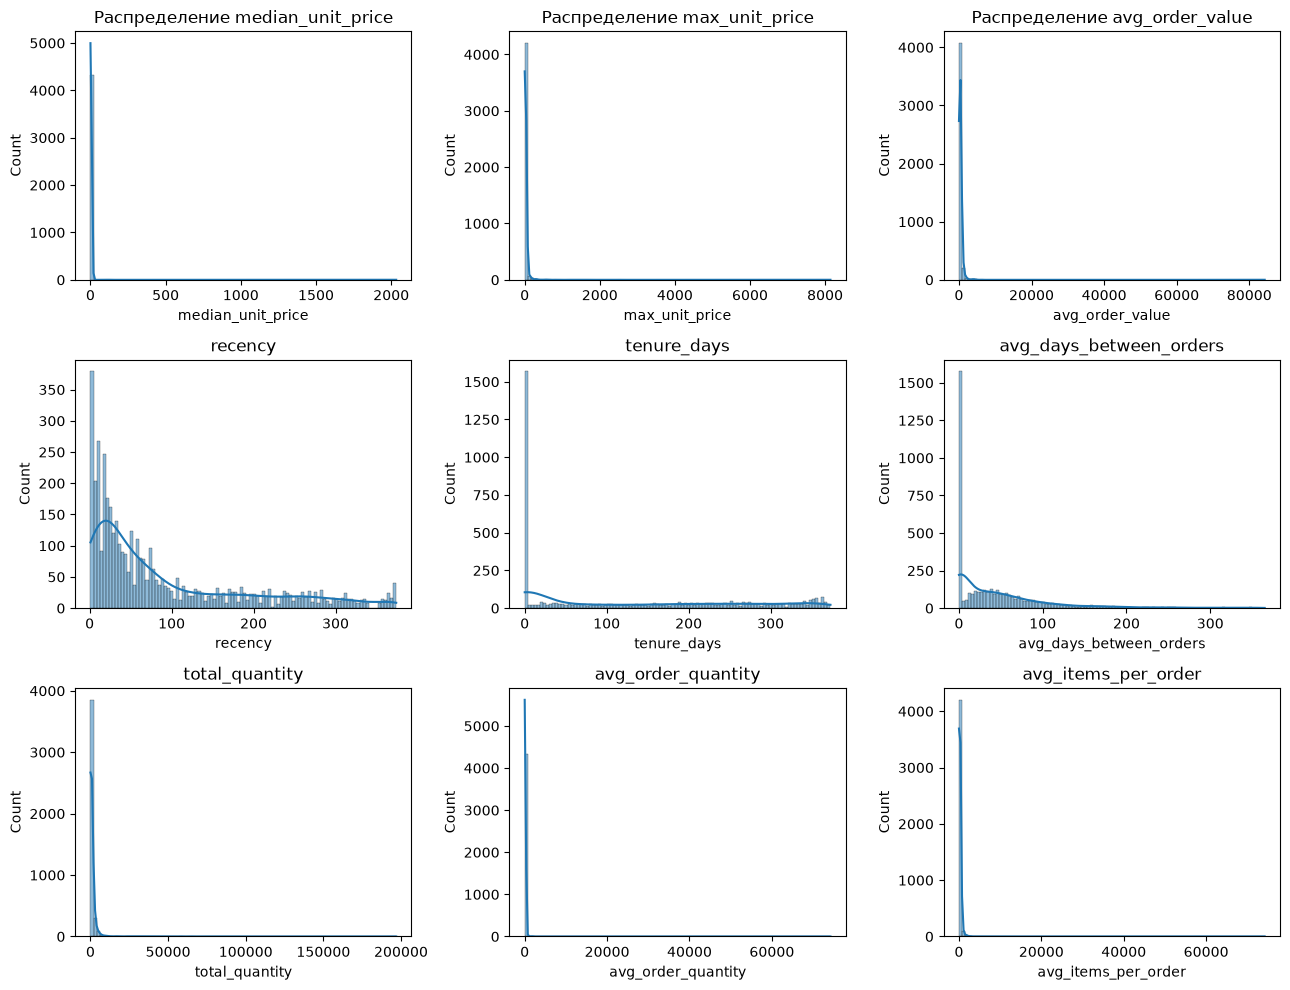

In [137]:
# Визуализация распределений основных метрик
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
# ================================================================================ Цена

# median_unit_price
sns.histplot(customer_df_dop['median_unit_price'], bins=100, kde=True, ax=axes[0,0])
axes[0,0].set_title('Распределение median_unit_price')

# max_unit_price
sns.histplot(customer_df_dop['max_unit_price'], bins=100, kde=True, ax=axes[0,1])
axes[0,1].set_title('Распределение max_unit_price')

# avg_order_value
sns.histplot(customer_df_dop['avg_order_value'], bins=100, kde=True, ax=axes[0,2])
axes[0,2].set_title('Распределение avg_order_value')
# ================================================================================ Время
# recency
sns.histplot(customer_df_dop['recency'], bins=100, kde=True, ax=axes[1,0])
axes[1,0].set_title('recency')

# tenure_days
sns.histplot(customer_df_dop['tenure_days'], bins=100, kde=True, ax=axes[1,1])
axes[1,1].set_title('tenure_days')

# avg_days_between_orders
sns.histplot(customer_df_dop['avg_days_between_orders'], bins=100, kde=True, ax=axes[1,2])
axes[1,2].set_title('avg_days_between_orders')

# ================================================================================ Частота/количество (F)
# total_quantity
sns.histplot(customer_df_dop['total_quantity'], bins=100, kde=True, ax=axes[2,0])
axes[2,0].set_title('total_quantity')

# avg_order_quantity
sns.histplot(customer_df_dop['avg_order_quantity'], bins=100, kde=True, ax=axes[2,1])
axes[2,1].set_title('avg_order_quantity')

# avg_items_per_order
sns.histplot(customer_df_dop['avg_items_per_order'], bins=100, kde=True, ax=axes[2,2])
axes[2,2].set_title('avg_items_per_order')

plt.tight_layout()
plt.show()

### Метрики для анализа скидок на уровне клиентов

Для понимания чувствительности клиентов к скидкам мы создали набор метрик, основанных на сравнении фактической цены покупки с максимальной ценой товара.

#### Методология расчёта скидок

Мы используем **максимальную цену товара (`max_price`)** как базовую цену. Это позволяет:

1. Обнаружить все случаи снижения цены относительно максимальной.
2. Оценить «глубину» скидки в процентах.
3. Выявить клиентов, которые систематически покупают товары со скидкой.

**Почему максимальная цена, а не средняя или медианная?**
- Максимальная цена — это цена, по которой товар продавался в своей самой дорогой версии. Снижение относительно неё означает, что клиент получил скидку.
- В отличие от медианы, максимальная цена не усредняет скидки и позволяет зафиксировать даже разовые глубокие акции.

**Почему порог скидки > 5%?**
- Мы считаем скидкой только снижение цены более чем на 5%. Меньшие отклонения могут быть связаны с:
  - Округлением цен.
  - Техническими погрешностями.
  - Естественной изменчивостью цен на разные партии товара.
- Порог в 5% отсекает «шум» и позволяет выделить именно маркетинговые скидки и акции.

#### Итоговый набор скидочных метрик

| Переменная | Описание | Бизнес-смысл |
|------------|----------|--------------|
|`avg_discount` | Средний размер скидки по всем покупкам клиента (%) | Насколько клиент в среднем экономит. |
| `max_discount` | Максимальная скидка, полученная клиентом (%) | Участвовал ли клиент в крупных акциях. |
| `pct_discounted` | Доля покупок со скидкой (от 0 до 1) | Как часто клиент использует скидки. |
|`discount_rate` | Доля оборота, приходящаяся на скидочные товары | Насколько клиент «скидкозависим» (чем выше, тем сильнее). |

In [138]:
# Расчёт скидочных метрик 
# ==================================

# Добавляем максимальную цену товара
max_prices = df.groupby('StockCode')['UnitPrice'].max().reset_index()
max_prices.columns = ['StockCode', 'max_price']

df_discount = df.merge(max_prices, on='StockCode', how='left')

# Рассчитываем процент скидки относительно максимальной цены
df_discount['discount_pct'] = (df_discount['max_price'] - df_discount['UnitPrice']) / df_discount['max_price'] * 100

# Флаг: была ли скидка (>5%)
df_discount['is_discounted'] = df_discount['discount_pct'] > 5

# Агрегация по клиентам
discount_metrics = df_discount.groupby('CustomerID').agg(
    # Базовые метрики
    avg_discount=('discount_pct', lambda x: x[x > 5].mean() if (x > 5).any() else 0),
    max_discount=('discount_pct', 'max'),
    pct_discounted=('is_discounted', 'mean'),
    discount_monetary=('TotalPrice', lambda x: x[df_discount.loc[x.index, 'is_discounted']].sum()),

).reset_index()

# Добавляем discount_rate (доля скидки в обороте)
discount_metrics['discount_rate'] = discount_metrics['discount_monetary'] / customer_df['monetary']
discount_metrics['discount_rate'] = discount_metrics['discount_rate'].fillna(0)

# Объединяем с основным датафреймом
customer_df_dop = customer_df_dop.merge(discount_metrics, on='CustomerID', how='left')
customer_df_dop.head(5)

,CustomerID,first_purchase,last_purchase,frequency,monetary,total_quantity,avg_order_quantity,min_unit_price,avg_unit_price,max_unit_price,...,tenure_days,avg_order_value,avg_days_between_orders,avg_items_per_order,purchase_regularity,avg_discount,max_discount,pct_discounted,discount_monetary,discount_rate
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,74215,74215.000000,1.04,1.040000,1.04,...,0,77183.600000,0.000000,74215.000000,NaN,16.800000,16.800000,1.000000,77183.60,1.000000
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,7,4310.00,2458,13.505495,0.25,2.644011,12.75,...,365,615.714286,60.833333,351.142857,18.478817,49.741217,78.991597,0.714286,3112.65,0.722193
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,2341,75.516129,0.29,5.764839,40.00,...,282,449.310000,94.000000,585.250000,70.149840,63.422636,99.508765,0.645161,1008.24,0.560994
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,631,8.643836,0.42,8.289041,300.00,...,0,1757.550000,0.000000,631.000000,NaN,50.749246,96.315741,0.602740,1197.29,0.681227
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,11.588235,0.85,3.841176,40.00,...,0,334.400000,0.000000,197.000000,NaN,53.317618,99.508765,0.705882,238.70,0.713816


In [139]:
# Объединяем  датафреймы
col_rfm_class=['CustomerID','r_score', 'f_score', 'm_score', 'RFM_score','RFM_segment', 'RFM_segment', 'is_super_elite','cluster_final']
customer_df_dop = customer_df_dop.merge(all_customers[col_rfm_class], on='CustomerID', how='left')
# # Сохраняем в CSV
# customer_df_dop.to_csv('customer_df_dop.csv', index=False)
# print("Файл сохранён: customer_df_dop.csv")
customer_df_dop.head()

,CustomerID,first_purchase,last_purchase,frequency,monetary,total_quantity,avg_order_quantity,min_unit_price,avg_unit_price,max_unit_price,...,discount_monetary,discount_rate,r_score,f_score,m_score,RFM_score,RFM_segment,RFM_segment,is_super_elite,cluster_final
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,74215,74215.000000,1.04,1.040000,1.04,...,77183.60,1.000000,1,1,3,5,113,113,0,2
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,7,4310.00,2458,13.505495,0.25,2.644011,12.75,...,3112.65,0.722193,3,3,3,9,333,333,0,2
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,2341,75.516129,0.29,5.764839,40.00,...,1008.24,0.560994,2,2,3,7,223,223,0,1
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,631,8.643836,0.42,8.289041,300.00,...,1197.29,0.681227,3,1,3,7,313,313,0,1
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,11.588235,0.85,3.841176,40.00,...,238.70,0.713816,1,1,1,3,111,111,0,0


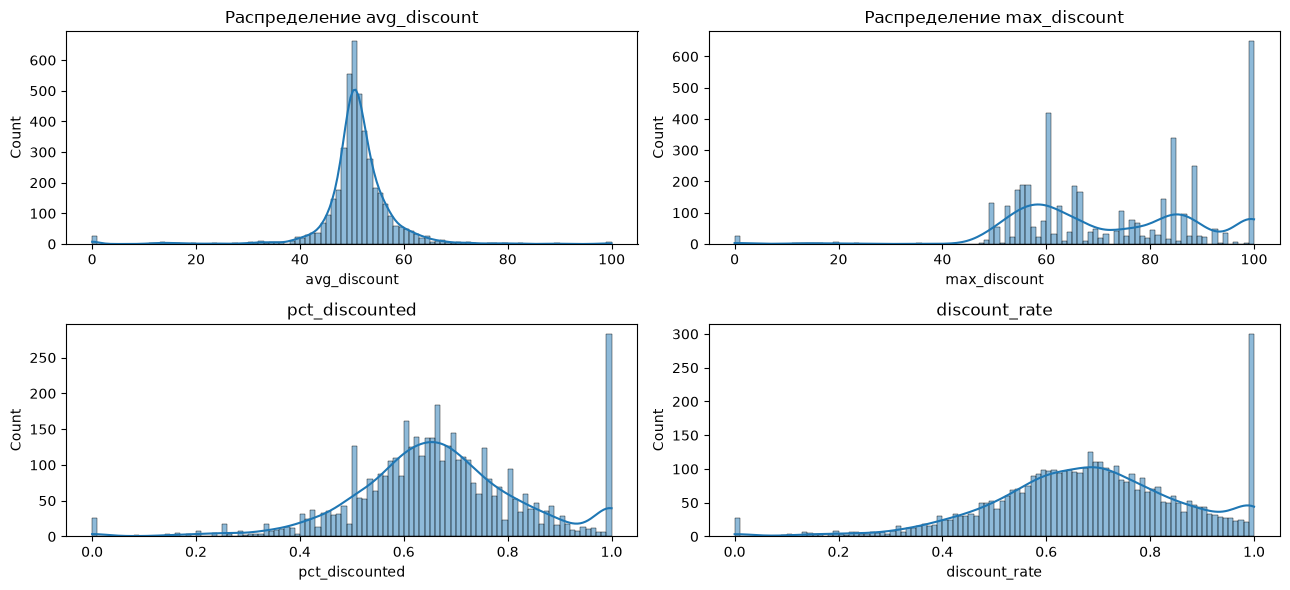

In [140]:
# Визуализация распределений основных метрик
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

discount_columns=[
'avg_discount', # средняя скидка (при скидке >5%)
'max_discount', #
'pct_discounted', # mean по всем скидкам 
'discount_rate', # = discount_monetary/monetary
]
# ================================================================================ 
# avg_discount
sns.histplot(customer_df_dop['avg_discount'], bins=100, kde=True, ax=axes[0,0])
axes[0,0].set_title('Распределение avg_discount')

# max_discount
sns.histplot(customer_df_dop['max_discount'], bins=100, kde=True, ax=axes[0,1])
axes[0,1].set_title('Распределение max_discount')

# ================================================================================ 
# pct_discounted
sns.histplot(customer_df_dop['pct_discounted'], bins=100, kde=True, ax=axes[1,0])
axes[1,0].set_title('pct_discounted')

# discount_rate
sns.histplot(customer_df_dop['discount_rate'], bins=100, kde=True, ax=axes[1,1])
axes[1,1].set_title('discount_rate')

plt.tight_layout()
plt.show()

### Распределения скидочных метрик

Для понимания структуры скидочного поведения клиентов мы визуализировали распределения ключевых метрик. Все они имеют характерные для розничных данных черты: скошенность, длинные правые хвосты и концентрацию на определённых значениях.

---

#### 1. Базовые метрики скидок

| Переменная | Распределение | Интерпретация |
|------------|---------------|---------------|
| `avg_discount` | Узкий пик около 50%, хвосты до 0% и 100% | Большинство клиентов получают скидку в районе 50% (средний размер скидки стабилен). Длинные хвосты означают, что есть как клиенты без скидок, так и те, кто покупает почти бесплатно. |
| `max_discount` | Три пика: 60%, 80% и 100% | Многие клиенты хотя бы раз получили очень высокую (100%) или существенную (80%) скидку. Это указывает на наличие агрессивных акций или оптовых скидок. |
| `pct_discounted` | Колоколообразное с левым хвостом и пиком в 100% | Большинство клиентов имеют долю скидочных покупок около 60–70%. Заметное число клиентов (более 250) покупают исключительно со скидкой (100% всех покупок). |
| `discount_rate` | Очень похоже на `pct_discounted`, но с более гладким хвостом | Доля оборота, приходящаяся на скидочные товары, у большинства клиентов составляет 60–70%. Это подтверждает, что скидки — важная часть модели потребления. |

**Вывод:** Основная масса клиентов получает скидки в 50–60% и использует их в 2/3 своих покупок. При этом есть значительная группа «скидкозависимых» (pct_discounted = 100%) и клиентов, получивших экстремально высокие максимальные скидки.
Почти все клиенты хотя бы раз покупали со скидкой, и для большинства скидки — это норма, а не исключение. Это указывает на то, что магазин активно использует акции.

In [141]:
# == Ценовые
price_columns=[
'monetary', #
'avg_unit_price',
'median_unit_price',
'max_unit_price',
'min_unit_price',
'avg_order_value', # средний чек
]
# == Временные
time_columns=[
'recency',
'tenure_days',   # время сотрудничества
'avg_days_between_orders',# среднее количество дней между покупками (частота покупок)
'purchase_regularity' #(регулярность покупок): стандартное отклонение дней между покупками. 
# Низкое значение указывает на очень регулярного клиента, высокое — на спонтанного.
] 

# == Количественные
quantity_columns=[
'frequency',
'total_quantity', # общее количество
'avg_order_quantity', # среднее кол-во товаров за 1 вид товара
'avg_items_per_order', # среднее кол-во товаров в 1м чеке
'product_diversity'  #(разнообразие товаров): количество уникальных StockCode (или Description) в покупках клиента. Это покажет, насколько широки интересы покупателя.
]  

# == Скидки 
discount_columns=[
'avg_discount', # средняя скидка (при скидке >5%)
'max_discount', #
'pct_discounted', # mean по всем скидкам 
'discount_rate', # = discount_monetary/monetary
]

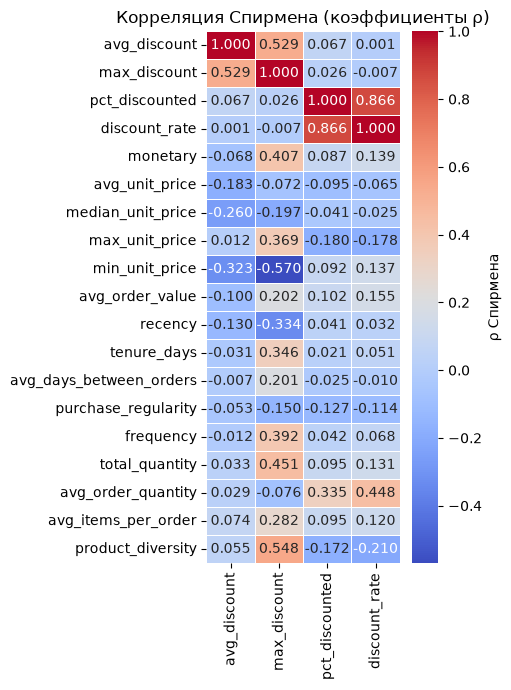

Корреляция Спирмена (коэффициенты):


,avg_discount,max_discount,pct_discounted,discount_rate,monetary,avg_unit_price,median_unit_price,max_unit_price,min_unit_price,avg_order_value,recency,tenure_days,avg_days_between_orders,purchase_regularity,frequency,total_quantity,avg_order_quantity,avg_items_per_order,product_diversity
avg_discount,1.000,0.529,0.067,0.001,-0.068,-0.183,-0.260,0.012,-0.323,-0.100,-0.130,-0.031,-0.007,-0.053,-0.012,0.033,0.029,0.074,0.055
max_discount,0.529,1.000,0.026,-0.007,0.407,-0.072,-0.197,0.369,-0.570,0.202,-0.334,0.346,0.201,-0.150,0.392,0.451,-0.076,0.282,0.548
pct_discounted,0.067,0.026,1.000,0.866,0.087,-0.095,-0.041,-0.180,0.092,0.102,0.041,0.021,-0.025,-0.127,0.042,0.095,0.335,0.095,-0.172
discount_rate,0.001,-0.007,0.866,1.000,0.139,-0.065,-0.025,-0.178,0.137,0.155,0.032,0.051,-0.010,-0.114,0.068,0.131,0.448,0.120,-0.210


p-values:


,avg_discount,max_discount,pct_discounted,discount_rate
avg_discount,0.0,0.0,0.0,0.9467
max_discount,0.0,0.0,0.0827,0.6247
pct_discounted,0.0,0.0827,0.0,0.0
discount_rate,0.9467,0.6247,0.0,0.0


In [142]:
from scipy.stats import spearmanr

# Расчёт корреляции Спирмена с p-значениями
corr_spearman = customer_df_dop[discount_columns+price_columns+time_columns+quantity_columns].corr(method='spearman')[discount_columns]
p_values = pd.DataFrame(index=corr_spearman.columns, columns=corr_spearman.columns)

for i in corr_spearman.columns:
    for j in corr_spearman.columns:
        if i == j:
            p_values.loc[i, j] = 0.0
        else:
            _, p = spearmanr(customer_df_dop[i], customer_df_dop[j])
            p_values.loc[i, j] = round(p, 4)

# Визуализация
fig, axes = plt.subplots( figsize=(5, 7))

# Тепловая карта коэффициентов
sns.heatmap(corr_spearman.round(3), annot=True, cmap='coolwarm', fmt='.3f', 
            linewidths=0.5, cbar_kws={'label': 'ρ Спирмена'})
axes.set_title('Корреляция Спирмена (коэффициенты ρ)')

plt.tight_layout()
plt.show()

print("Корреляция Спирмена (коэффициенты):")
display(corr_spearman.round(3)[discount_columns].T)
print("p-values:")
display(p_values)

### Корреляционный анализ скидочных метрик

Для оценки взаимосвязей между скидочными переменными и другими показателями мы рассчитали корреляцию Спирмена (непараметрический метод). 
#### Сильные связи между скидочными метриками

| Переменные | ρ Спирмена | Вывод |
|------------|------------|-------|
| `pct_discounted` - `discount_rate` | **0.866** | **Очень сильная связь.** Обе метрики показывают долю скидок (в покупках и в деньгах). Можно использовать одну из них. |
| `avg_discount` - `max_discount` | 0.529 | Умеренная связь. Клиенты с высоким средним размером скидки склонны иметь и высокую максимальную. |
| `avg_discount` - `discount_rate` | **0.001** (p=0.95) | **Связь отсутствует.** средний процент скидки не связан с долей оборота со скидкой. |

#### Связь с RFM-метриками

| Переменная | Связь с monetary | Связь с frequency | Вывод |
|------------|------------------|-------------------|-------|
| `max_discount` | **0.407** | **0.392** | **Умеренная положительная.** Более ценные и частые клиенты получали более высокие максимальные скидки. |
| `avg_discount` | -0.068 | -0.012 | **Практически отсутствует.**|
| `pct_discounted` | 0.087 | 0.042 | Очень слабая. |
| `discount_rate` | 0.139 | 0.068 | Очень слабая. |

**Вывод:** Только `max_discount` имеет заметную связь с ценностью клиента (`monetary`). 

#### Связь с временными и количественными переменными

- `max_discount` отрицательно связана с `recency` (-0.334) — более активные клиенты получали большие скидки.
- `max_discount` положительно связана с `tenure_days` (0.346) — долгосрочные клиенты участвовали в крупных акциях.
Более лояльным и ативным клиентам чаще предлагают больший процент скидки или клиенты сами следят за акциями магазина.
- `pct_discounted` и `discount_rate` показывают связь с `avg_order_quantity` (0.335 и 0.448) — клиенты, которые покупают много товаров одного вида, имеют более высокую долю скидок. Это может указывать на оптовые закупки со скидками.

### Корреляционный анализ всех переменных

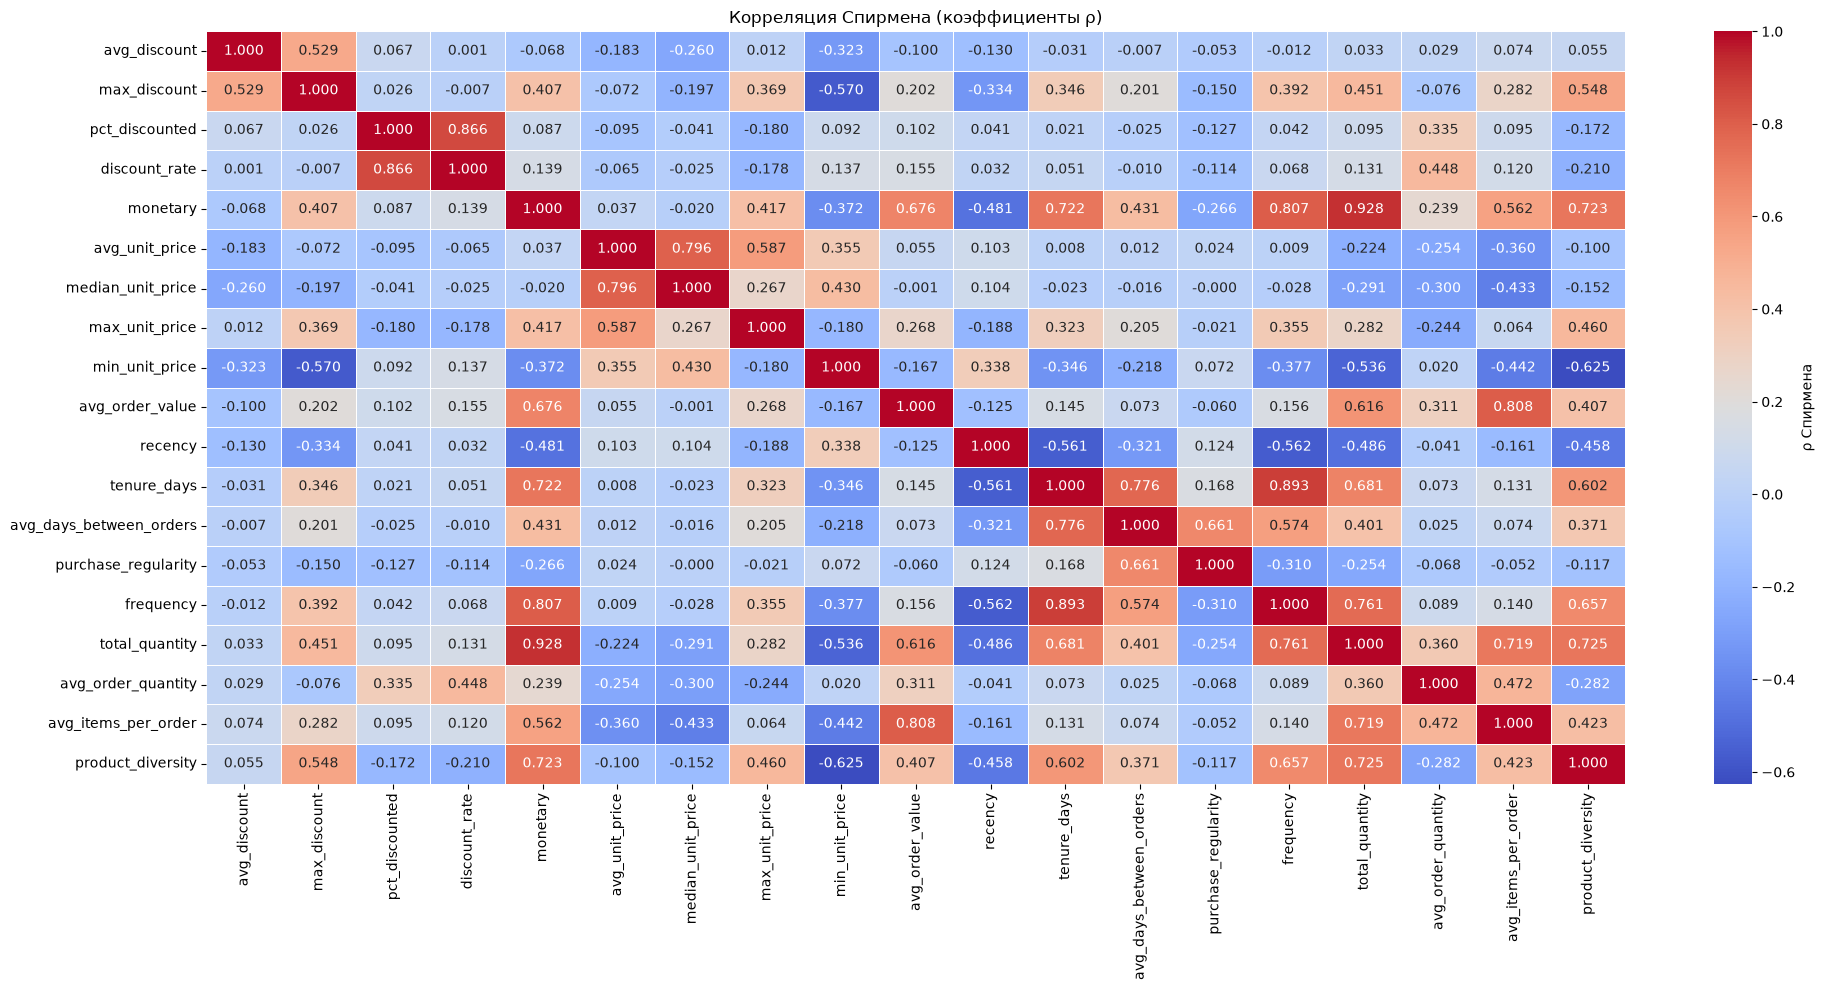

p-values:


,avg_discount,max_discount,pct_discounted,discount_rate,monetary,avg_unit_price,median_unit_price,max_unit_price,min_unit_price,avg_order_value,recency,tenure_days,avg_days_between_orders,purchase_regularity,frequency,total_quantity,avg_order_quantity,avg_items_per_order,product_diversity
avg_discount,0.0,0.0,0.0,0.9467,0.0,0.0,0.0,0.4165,0.0,0.0,0.0,0.0413,0.6586,NaN,0.4335,0.0297,0.0581,0.0,0.0003
max_discount,0.0,0.0,0.0827,0.6247,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
pct_discounted,0.0,0.0827,0.0,0.0,0.0,0.0,0.0074,0.0,0.0,0.0,0.0071,0.1703,0.0997,NaN,0.0061,0.0,0.0,0.0,0.0
discount_rate,0.9467,0.6247,0.0,0.0,0.0,0.0,0.0965,0.0,0.0,0.0,0.0373,0.0007,0.4944,NaN,0.0,0.0,0.0,0.0,0.0
monetary,0.0,0.0,0.0,0.0,0.0,0.0149,0.1869,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
avg_unit_price,0.0,0.0,0.0,0.0,0.0149,0.0,0.0,0.0,0.0,0.0003,0.0,0.588,0.4147,NaN,0.5448,0.0,0.0,0.0,0.0
median_unit_price,0.0,0.0,0.0074,0.0965,0.1869,0.0,0.0,0.0,0.0,0.9303,0.0,0.1352,0.2983,NaN,0.0635,0.0,0.0,0.0,0.0
max_unit_price,0.4165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
min_unit_price,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.1959,0.0,0.0
avg_order_value,0.0,0.0,0.0,0.0,0.0,0.0003,0.9303,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0


In [144]:
from scipy.stats import spearmanr

# Расчёт корреляции Спирмена с p-значениями
corr_spearman = customer_df_dop[discount_columns+price_columns+time_columns+quantity_columns].corr(method='spearman')
p_values = pd.DataFrame(index=corr_spearman.columns, columns=corr_spearman.columns)

for i in corr_spearman.columns:
    for j in corr_spearman.columns:
        if i == j:
            p_values.loc[i, j] = 0.0
        else:
            _, p = spearmanr(customer_df_dop[i], customer_df_dop[j])
            p_values.loc[i, j] = round(p, 4)

# Визуализация
fig, axes = plt.subplots( figsize=(20, 10))

# Тепловая карта коэффициентов
sns.heatmap(corr_spearman.round(3), annot=True, cmap='coolwarm', fmt='.3f', 
            linewidths=0.5, cbar_kws={'label': 'ρ Спирмена'})
axes.set_title('Корреляция Спирмена (коэффициенты ρ)')

plt.tight_layout()
plt.show()

# print("Корреляция Спирмена (коэффициенты):")
# display(corr_spearman.round(3).T)
print("p-values:")
display(p_values)

####  Денежные показатели (monetary, avg_order_value)

| Связь | Коэффициент | Интерпретация |
|-------|-------------|---------------|
| **monetary - total_quantity** | **0.928** | Почти полная линейная связь. Клиенты, которые покупают больше товаров, приносят больше выручки. |
| **monetary - frequency** | **0.807** | Сильная связь.|
| **monetary - avg_order_value** | 0.676 | Умеренная связь. Средний чек растёт с выручкой, но не так сильно, как частота. |
| **avg_order_value - avg_items_per_order** | **0.808** | Сильная связь. Чем больше товаров в чеке, тем выше средний чек. |

**Вывод:** Monetary определяется частотой и объёмом, а не ценой товара. Увеличение частоты покупок важнее, чем повышение чека.

---

#### Временные показатели (recency, tenure_days, avg_days_between_orders)

| Связь | Коэффициент | Интерпретация |
|-------|-------------|---------------|
| **recency - frequency** | **-0.562** | Умеренная отрицательная. Чем меньше recency (свежее), тем выше частота. |
| **recency - monetary** | **-0.481** | Умеренная отрицательная. Свежие клиенты приносят больше денег. |
| **tenure_days - frequency** | **0.893** | Очень сильная связь. Чем дольше клиент с нами, тем чаще он покупает. |
| **tenure_days - monetary** | **0.722** | Сильная связь. Долгосрочные клиенты приносят больше выручки. |
| **tenure_days - avg_days_between_orders** | **0.776** | Сильная связь. У долгосрочных клиентов интервалы между заказами больше (они покупают стабильно, но реже). |
| **recency - tenure_days** | **-0.561** | Свежие клиенты имеют меньший tenure (новые), ушедшие — больший (давно не покупали). |

**Вывод:** tenure_days и frequency тесно связаны — лояльные клиенты покупают чаще и приносят больше денег. Recency — самостоятельный показатель, отражающий актуальность клиента.

---

#### Количественные показатели (total_quantity, product_diversity)

| Связь | Коэффициент | Интерпретация |
|-------|-------------|---------------|
| **total_quantity - product_diversity** | 0.725 | Сильная связь. Клиенты, покупающие много товаров, пробуют и больше разных позиций. |
| **product_diversity - max_discount** | 0.548 | Умеренная связь. Широкий ассортимент коррелирует с получением более глубоких скидок. |
| **product_diversity - monetary** | 0.723 | Сильная связь. Разнообразие товаров — маркер высокой ценности. |

**Вывод:** Крупные и ценные клиенты не просто покупают много, но и пробуют разные товары. 

### Корреляционный анализ переменных с ценностью кластера

Для оценки того, какие характеристики клиентов наиболее тесно связаны с их принадлежностью к тому или иному кластеру (и, следовательно, с их ценностью для бизнеса), мы рассчитали коэффициент ранговой корреляции Спирмена между финальным кластером (`cluster_final`) и всеми числовыми переменными. 

**Важно:**  кластеры были перенумерованы в порядке **возрастания бизнес-ценности**:
- 1 — Потерянные (наименьшая ценность)
- 2 — Середняки
- 3 — Активные
- 4 — Суперэлита (наибольшая ценность)

Это позволит интерпретировать знак и величину корреляции: положительный коэффициент означает, что переменная растёт с переходом к более ценным группам, отрицательный — что она снижается.

=== Корреляция Спирмена с cluster_final ===

frequency: rho = 0.651, p = 0.0000
tenure_days: rho = 0.612, p = 0.0000
monetary: rho = 0.605, p = 0.0000
total_quantity: rho = 0.603, p = 0.0000
product_diversity: rho = 0.502, p = 0.0000
max_discount: rho = 0.340, p = 0.0000
avg_days_between_orders: rho = 0.267, p = 0.0000
avg_items_per_order: rho = 0.230, p = 0.0000
max_unit_price: rho = 0.225, p = 0.0000
avg_order_value: rho = 0.213, p = 0.0000
avg_order_quantity: rho = 0.120, p = 0.0000
avg_discount: rho = 0.069, p = 0.0000
discount_rate: rho = 0.056, p = 0.0002
pct_discounted: rho = 0.029, p = 0.0542
avg_unit_price: rho = -0.078, p = 0.0000
median_unit_price: rho = -0.103, p = 0.0000
purchase_regularity: rho = -0.297, p = nan
min_unit_price: rho = -0.343, p = 0.0000
recency: rho = -0.757, p = 0.0000


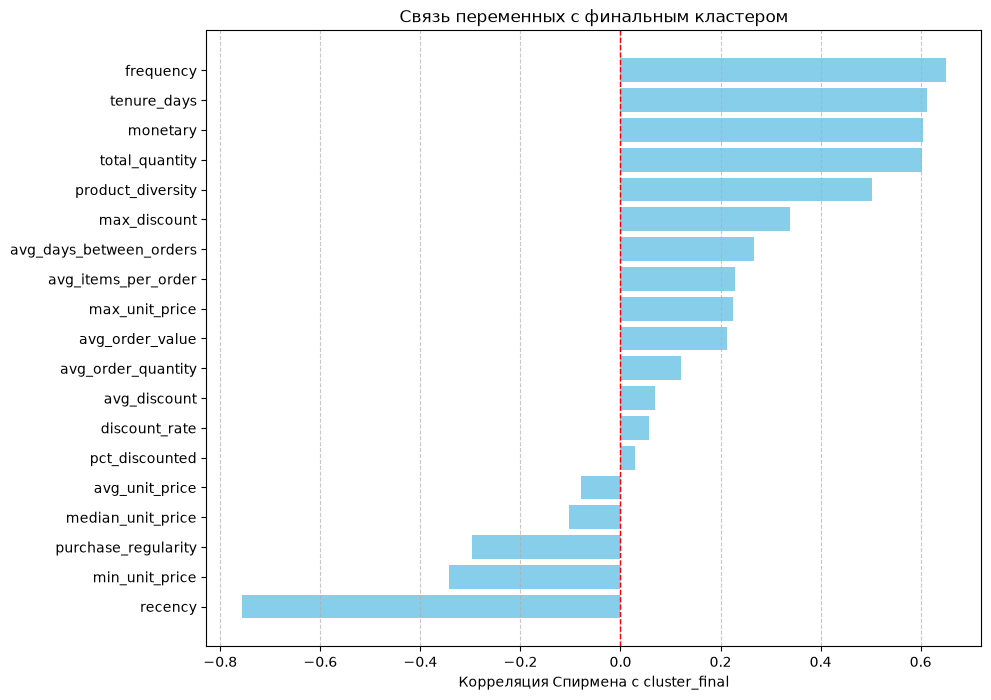

In [145]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. Подготовка данных
# ============================================================

# Используем customer_df_dop (содержит все 4338 клиентов, включая суперэлиту)
df_corr = customer_df_dop.copy()

# Все переменные для корреляции (включая кластер)
all_vars = ['cluster_final'] + time_columns + price_columns + quantity_columns + discount_columns

# Проверяем, что все колонки есть в df
missing = [v for v in all_vars if v not in df_corr.columns]
if missing:
    print(f"Отсутствуют колонки: {missing}")
    # Если каких-то нет, можно их исключить или создать (но у нас всё должно быть)

# Создаём подмножество с нужными колонками
df_subset = df_corr[all_vars].copy()

# 2. Расчёт корреляций Спирмена
corr_matrix = df_subset.corr(method='spearman')
p_values = pd.DataFrame(index=corr_matrix.columns, columns=corr_matrix.columns)

for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i == j:
            p_values.loc[i, j] = 0.0
        else:
            _, p = spearmanr(df_subset[i], df_subset[j])
            p_values.loc[i, j] = round(p, 4)

# 3. Вывод результатов (только связи с cluster_final)
print("=== Корреляция Спирмена с cluster_final ===\n")
cluster_corr = corr_matrix['cluster_final'].drop('cluster_final').sort_values(ascending=False)
cluster_p = p_values.loc['cluster_final'].drop('cluster_final').reindex(cluster_corr.index)

for var in cluster_corr.index:
    print(f"{var}: rho = {cluster_corr[var]:.3f}, p = {cluster_p[var]:.4f}")

# Визуализация корреляций с cluster_final
cluster_corr = corr_matrix['cluster_final'].drop('cluster_final').sort_values()

plt.figure(figsize=(10, 8))
plt.barh(cluster_corr.index, cluster_corr.values, color='skyblue')
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Корреляция Спирмена с cluster_final')
plt.title('Связь переменных с финальным кластером')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

####  результаты

| Переменная | Коэффициент ρ | Значимость | Интерпретация |
|------------|---------------|------------|---------------|
| **`recency`** | **-0.757** | p < 0.001 | **Сильнейшая отрицательная связь.** Чем выше кластер, тем меньше дней с последней покупки. Активные и суперэлита — самые «свежие» клиенты. |
| **`frequency`** | **0.651** | p < 0.001 | **Очень сильная положительная.** Частота заказов резко растёт с ценностью кластера. |
| **`tenure_days`** | **0.612** | p < 0.001 | **Длительность сотрудничества** также сильно коррелирует с ценностью — лояльные клиенты оказываются самыми ценными. |
| **`monetary`** | **0.605** | p < 0.001 | Ожидаемо — общая выручка растёт с классом. |
| **`total_quantity`** | **0.603** | p < 0.001 | Общий объём покупок почти так же сильно связан с ценностью, как и monetary. |
| **`product_diversity`** | **0.502** | p < 0.001 | Разнообразие ассортимента (количество уникальных товаров) также сильно растёт с ценностью. |
| **`max_discount`** | **0.340** | p < 0.001 | Максимальная полученная скидка умеренно положительно связана с ценностью. |
| **`min_unit_price`** | **-0.343** | p < 0.001 | Чем ценнее клиент, тем **ниже** минимальная цена товара в его корзине — они покупают и дешёвые позиции. Это так же связано с `max_discount` получаемой клиентом. Из корреляции Спирмена выше r(`max_discount`&`min_unit_price`)=-0.57 |
| **`purchase_regularity`** | **-0.297** | p < 0.001 | Стандартное отклонение интервалов между покупками снижается с ростом ценности — более ценные клиенты покупают регулярнее и стабильнее. |
| **`avg_days_between_orders`** | **0.267** | p < 0.001 | Чем выше кластер, тем **короче** средний интервал между заказами — покупают чаще. |
| **`avg_order_value`** | **0.213** | p < 0.001 | Средний чек тоже растёт, но связь заметно слабее, чем у частоты. |

**Слабые или незначимые связи:**
- `avg_order_quantity` (ρ = 0.120)
- `discount_rate` (ρ = 0.056)
- `pct_discounted` (ρ = 0.029, p = 0.054 – статистически незначимо)
- `avg_unit_price` и `median_unit_price` – слабые отрицательные корреляции.
- *Скорее всего эти метрики будут примерно равны у всех кластеров.*)
---

#### Выводы

1. **Самый сильный предиктор ценности — это свежесть (`recency`).** Клиенты, которые покупали недавно, с высокой вероятностью относятся к более ценным кластерам. Это подтверждает классическую RFM-логику.

2. **Частота и долгосрочность сотрудничества.** Высокие корреляции `frequency` и `tenure_days` показывают, что бизнес-успех строится на повторных покупках и удержании клиентов.

3. **Объём и разнообразие покупок.** Ценные клиенты не только тратят больше и ориентированы на более широкий ассортимент (высокое `product_diversity`). 

4. **Регулярность поведения — отличительная черта ценных клиентов.** Чем меньше разброс между покупками (`purchase_regularity`), тем выше класс. В наиболее ценный класс попадают регулярные закупщики.

---

#### Что нового?

- **Для середняков** (кластер 2): стимулировать рост частоты и регулярности, внедрять программы лояльности, напоминания о покупках.
- **Для активных** (кластер 3): увеличивать разнообразие товаров в корзине, предлагать новинки, премиум-условия.
- **Для суперэлиты** (кластер 4): обеспечить ранний доступ к новинкам.

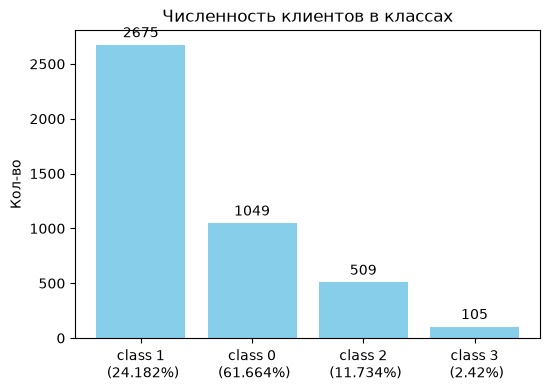

In [152]:
segments_count=customer_df_dop[['CustomerID','cluster_final']].groupby('cluster_final').count()
all=segments_count['CustomerID'].sum()
segments_count['pie']=(segments_count['CustomerID']*100/all).round(3)
segments_count=segments_count.sort_values(by='pie',ascending=False)
labels_s_prs=[]
for i in range(len(segments_count.index)):
    labels_s_prs.append('class '+str(segments_count.index[i])+'\n ('+str(segments_count['pie'][i])+'%)')
fig, ax = plt.subplots(figsize=(6, 4))
bars_1 = ax.bar(labels_s_prs,segments_count['CustomerID'], color='skyblue')

# Добавление меток
ax.bar_label(bars_1, padding=3) 

ax.set_title('Численность клиентов в классах')
ax.set_ylabel('Кол-во')
plt.show()

## **Детальное рассмотрение кластеров** 

In [153]:
customer_df_dop[['cluster_final']+price_columns+time_columns+quantity_columns+discount_columns].groupby('cluster_final').median().round(2).sort_values(by='recency',ascending=False).T

cluster_final,0,1,2,3
monetary,308.58,692.19,3711.77,13027.45
avg_unit_price,3.23,2.84,2.91,2.94
median_unit_price,2.10,1.95,1.95,1.95
max_unit_price,9.95,12.50,15.95,16.65
min_unit_price,0.55,0.39,0.29,0.19
avg_order_value,229.26,294.71,338.89,465.42
recency,246.00,37.00,12.00,4.00
tenure_days,0.00,118.00,324.00,361.00
avg_days_between_orders,0.00,47.67,32.09,14.00
purchase_regularity,23.28,39.94,24.43,11.43


### 1. Общий портрет клиентов и специфика магазина

На основе медиан можно составить общее представление о клиентской базе и бизнес-модели магазина подарков.

#### Основные характеристики клиентов (медианы по кластерам)

| Показатель | Потерянные (0) | Середние (1) | Активные (2) | Суперэлита (3) | Интерпретация |
|------------|---------------|---------------|--------------|----------------|---------------|
| **Размер** | 1049 (24.8%) | 2675 (63.2%) | 509 (12.0%) | 105 (2.4%) | Преобладают середние клиенты, но именно активные и элита приносят основную выручку. |
| **Recency** | 246 дн. | 37 дн. | 12 дн. | 4 дн. | Резкое снижение recency с ростом ценности — ключевой признак. |
| **Frequency** | 1 | 2 | 10 | 26 | Частота растёт экспоненциально — от разовых до сверхактивных. |
| **Monetary** | 309 | 692 | 3712 | 13027 | Выручка растёт пропорционально частоте, а не чеку. |
| **Avg_order_value** | 229 | 295 | 339 | 465 | Средний чек растёт медленно, особенно по сравнению с частотой. |
| **Total_quantity** | 149 шт | 397 шт | 2088 шт | 6176 шт | Объём покупок резко увеличивается у активных и элиты. |
| **Product_diversity** | 17 | 37 | 119 | 178 | Разнообразие товаров также кратно растёт с классом. |
| **Tenure_days** | 0 | 118 | 324 | 361 | Длительность сотрудничества  показатель лояльности. |
| **Avg_days_between_orders** | 0 | 48 | 32 | 14 | Интервал между покупками сокращается (0 - соответствуюе только 1 покупке за всё время). |
| **Purchase_regularity** | 23.3 | 39.9 | 24.4 | 11.4 | Чем ценнее клиент, тем стабильнее его покупки. |
| **Max_discount** | 60% | 73% | 85% | 88% | Максимальная скидка растёт с классом — элита участвует в крупных акциях. |

---

#### Ключевые наблюдения

1. **Ценность клиента определяется частотой и стабильностью, а не разовыми тратами.**
   - `avg_order_value` растёт медленно (от 229 до 465 ₽), в то время как `frequency` увеличивается в 26 раз. Это значит, что клиенты становятся ценными не потому, что покупают дороже, а потому что покупают чаще и регулярнее.
   - Наиболее ценные клиенты (Суперэлита) имеют самую низкую `purchase_regularity` (11.4), то есть их покупки предсказуемы и стабильны.

2. **`avg_days_between_orders`**
   - У Середних клиентов (`avg_days_between_orders` = 48 дней) и Активных (32 дня) такие интервалы между покупками могут указывать на сезонные всплески (праздники, подарки к событиям). Специфику товара — подарки покупают не каждый день, а к определённым датам.
   - При этом Суперэлита покупает почти каждые две недели, что говорит о регулярных оптовых закупках (возможно, для перепродажи).

3. **Скидки — универсальный инструмент, но элита получает эксклюзивные условия.**
   - Доля покупок со скидкой (`pct_discounted`) колеблется от 0.65 до 0.73, то есть все клиенты активно пользуются скидками.
   - Однако `max_discount` значительно выше у элиты (88% против 60% у потерянных), для крупных клиентов существуют специальные условия или они участвуют в акциях с высокими скидками.

4. **Разнообразие товаров — маркер зрелости клиента.**
   - `product_diversity` растёт с классом: от 17 уникальных товаров у потерянных до 178 у суперэлиты. Это означает, что ценные клиенты со временем расширяют свой ассортимент.
---

### Сравнение кластеров по временным показателям

Временные метрики позволяют оценить, как давно клиент совершил последнюю покупку, как долго он взаимодействует с магазином, насколько стабильны интервалы между его заказами и какова общая частота покупок.

In [65]:
# Сводная таблица: медиана и IQR в одну строку
def cluster_summary(dfq, cluster_col, vars_list):
    summary = {}
    for var in vars_list:
        q1 = dfq.groupby(cluster_col)[var].quantile(0.25)
        med = dfq.groupby(cluster_col)[var].median()
        q3 = dfq.groupby(cluster_col)[var].quantile(0.75)
        summary[var] = pd.DataFrame({
            'Q1': q1, 'Median': med, 'Q3': q3
        }).round(2)
    return summary


summary = cluster_summary(customer_df_dop, 'cluster_final', time_columns+['frequency'])
for var, dfq in summary.items():
    print(f"\n=== {var} ===")
    print(dfq.T)


=== recency ===
cluster_final      0     1     2    3
Q1             192.0  18.0   4.0  2.0
Median         246.0  37.0  12.0  4.0
Q3             302.0  71.0  28.0  9.0

=== tenure_days ===
cluster_final     0      1      2      3
Q1              0.0    0.0  261.0  350.0
Median          0.0  118.0  324.0  361.0
Q3             29.0  237.0  354.0  366.0

=== avg_days_between_orders ===
cluster_final     0      1      2      3
Q1              0.0   0.00  24.50   9.67
Median          0.0  47.67  32.09  14.00
Q3             17.0  88.67  40.50  16.81

=== purchase_regularity ===
cluster_final      0      1      2      3
Q1             12.00  22.53  16.94   8.13
Median         23.28  39.94  24.43  11.43
Q3             50.93  65.95  35.21  14.85

=== frequency ===
cluster_final    0    1     2     3
Q1             1.0  1.0   8.0  21.0
Median         1.0  2.0  10.0  26.0
Q3             2.0  4.0  13.0  37.0


**Кластер 0 — Потерянные (1049 клиентов, 24.8%)**

- **Recency (медиана 246 дней, IQR 192–302):** Клиенты из этого кластера не совершали покупок более полугода. Это явный признак оттока. 
- **Tenure_days (медиана 0 дней, IQR 0–29):** Подавляющее большинство клиентов совершили лишь одну покупку и больше не возвращались.
- **Avg_days_between_orders (медиана 0, IQR 0–17):** Нулевая медиана подтверждает, что у большинства клиентов не было повторных заказов. У 25% клиентов интервал между покупками составляет до 17 дней, что говорит о том, что они могли совершить 2-3 покупки за короткий промежуток времени (например, перед праздником) и затем уйти.
- **Purchase_regularity (медиана 23.3, IQR 12–50.9):** Этот показатель рассчитан только для клиентов с >1 заказа. Относительно высокое значение говорит о нерегулярных покупках у тех, кто всё же совершал повторные заказы.
- **Frequency (медиана 1, IQR 1–2):** Почти все клиенты совершили только одну покупку.

**Вывод:** Кластер 0 — это классический отток. Клиенты пришли, совершили 1–2 покупки (вероятно, по случаю праздника) и больше не возвращались. Их возврат маловероятен без сильных стимулов, и даже с ними эффективность будет низкой.

---

**Кластер 1 — Середняки (2675 клиентов, 63.2%)**

- **Recency (медиана 37 дней, IQR 18–71):** Клиенты покупали в среднем 1–2 месяца назад. Они ещё «тёплые» — не потеряны, но требуют внимания, чтобы не перейти в кластер 0.
- **Tenure_days (медиана 118 дней, IQR 0–237):** Здесь ситуация смешанная: половина клиентов имеет историю сотрудничества около 4 месяцев, но у 25% tenure = 0 (это новые клиенты, которые сделали одну покупку и пока не вернулись). Разброс говорит о неоднородности группы.
- **Avg_days_between_orders (медиана 47.7 дней, IQR 0–88.7):** Интервал между заказами составляет около 1.5 месяцев, что может указывать на сезонные покупки (например, к праздникам). При этом 25% клиентов имеют нулевой интервал (одна покупка).
- **Purchase_regularity (медиана 39.9, IQR 22.5–66):** Высокое стандартное отклонение говорит о нестабильности поведения: клиенты покупают нерегулярно, с большими разрывами между визитами.
- **Frequency (медиана 2, IQR 1–4):** Большинство клиентов совершили 2–4 покупки. Это уже лучше, чем в кластере 0, но до активных им далеко.

**Вывод:** Кластер 1 — это «серая зона». Часть клиентов — новые (одна покупка), часть — уже имеют некоторую историю, но покупают редко и нерегулярно. Это группа с высоким потенциалом: если стимулировать их частоту и регулярность, они могут перейти в кластер 2. Однако без действий они рискуют скатиться в кластер 0.

---

**Кластер 2 — Активные (509 клиентов, 12.0%)**

- **Recency (медиана 12 дней, IQR 4–28):** Клиенты покупали в течение последних двух недель. Это активная, «горячая» аудитория.
- **Tenure_days (медиана 324 дня, IQR 261–354):** Почти год сотрудничества. Это лояльные клиенты, которые остаются с магазином надолго.
- **Avg_days_between_orders (медиана 32.1 дня, IQR 24.5–40.5):** Интервал около месяца — стабильный, предсказуемый ритм покупок. Это может говорить о ежемесячных закупках (возможно, для бизнеса).
- **Purchase_regularity (медиана 24.4, IQR 16.9–35.2):** Относительно невысокое стандартное отклонение указывает на стабильное, регулярное поведение. Клиенты покупают с предсказуемой периодичностью.
- **Frequency (медиана 10, IQR 8–13):** В среднем 10 заказов за историю (~год). Это уже значительная частота.

**Вывод:** Кластер 2 — ядро лояльных клиентов. Они покупают регулярно (примерно раз в месяц), сотрудничают с магазином почти год и имеют стабильные паттерны поведения. Их удержание — приоритетная задача. Основной фокус  на расширении ассортимента и увеличении частоты покупок.

---

**Кластер 3 — Суперэлита (105 клиентов, 2.4%)**

- **Recency (медиана 4 дня, IQR 2–9):** Почти все покупки совершены в течение последней недели. Клиенты максимально актуальны.
- **Tenure_days (медиана 361 день, IQR 350–366):** Почти ровно год с первой покупки. Это самые лояльные клиенты с максимальной длительностью сотрудничества.
- **Avg_days_between_orders (медиана 14 дней, IQR 9.7–16.8):** Интервал около двух недель — очень высокая частота. Это говорит о регулярных оптовых закупках или бизнес-потребностях.
- **Purchase_regularity (медиана 11.4, IQR 8.1–14.9):** Самое низкое стандартное отклонение среди всех кластеров. Это означает максимальную стабильность и предсказуемость времени очередной покупки.
- **Frequency (медиана 26, IQR 21–37):** Огромное число заказов — в среднем 26 за год.

**Вывод:** Суперэлита — идеальные клиенты. Они покупают часто (каждые две недели), регулярно, давно и стабильно. Их потеря — критична для бизнеса. Требуется эксклюзивный подход, персональное обслуживание и постоянный мониторинг удовлетворённости.

In [66]:
summary = cluster_summary(customer_df_dop, 'cluster_final', quantity_columns+price_columns)
for var, dfq in summary.items():
    print(f"\n=== {var} ===")
    print(dfq.T)


=== frequency ===
cluster_final    0    1     2     3
Q1             1.0  1.0   8.0  21.0
Median         1.0  2.0  10.0  26.0
Q3             2.0  4.0  13.0  37.0

=== total_quantity ===
cluster_final      0      1       2        3
Q1              80.0  191.5  1323.0   4528.0
Median         149.0  397.0  2088.0   6176.0
Q3             291.0  810.5  3283.0  15968.0

=== avg_order_quantity ===
cluster_final      0      1      2      3
Q1              5.00   6.16   6.82  11.60
Median          8.94  10.09  10.78  16.12
Q3             13.25  14.44  15.95  35.74

=== avg_items_per_order ===
cluster_final      0      1       2       3
Q1              67.0  100.0  123.06  176.00
Median         114.0  168.5  196.20  261.81
Q3             201.0  278.0  305.00  402.44

=== product_diversity ===
cluster_final     0     1      2      3
Q1              8.0  18.0   74.0   80.0
Median         17.0  37.0  119.0  178.0
Q3             30.0  70.0  196.0  295.0

=== monetary ===
cluster_final       0      

### 3. Количественные показатели: объём и разнообразие покупок

Количественные метрики показывают, сколько и каких товаров покупают клиенты, а также насколько широк их ассортимент. Эти показатели тесно связаны с частотой покупок (корреляция frequency с total_quantity: 0.76, с product_diversity: 0.66) и позволяют понять, является ли клиент «глубоким» (много товаров за раз) или «широким» (много разных товаров).

---

####  Детальная интерпретация

**Кластер 0 — Потерянные**

- **Total_quantity (медиана 149, IQR 80–291):** Объём покупок минимален. Клиенты покупают очень мало товаров за всю историю.
- **Avg_items_per_order (114, IQR 67–201):** В одном чеке в среднем около 100 товаров. Это может показаться много, но учитывая, что у большинства клиентов всего 1 заказ, это просто размер их единственной покупки.
- **Product_diversity (17, IQR 8–30):** Очень узкий ассортимент. Клиенты покупают ограниченный набор товаров (вероятно, самые популярные позиции).
- **Avg_order_quantity (8.9, IQR 5.0–13.3):** В среднем 9 единиц одного товара за раз. Это указывает на то, что клиенты берут не по одной штуке, а небольшими наборами (например, 6–12 свечей или салфеток).

**Вывод:** Потерянные клиенты — это разовые покупатели, которые пришли за конкретным товаром (вероятно, подарком), купили его в небольшом количестве и ушли. Их ассортимент крайне узок, что говорит об отсутствии интереса к другим категориям.

---

**Кластер 1 — Середняки**

- **Total_quantity (397, IQR 191–811):** Уже заметно больше, чем в кластере 0. Клиенты совершают повторные покупки и накапливают объём.
- **Avg_items_per_order (168.5, IQR 100–278):** Средняя корзина больше, чем у потерянных. Клиенты покупают больше разных товаров за один визит.
- **Product_diversity (37, IQR 18–70):** Ассортимент шире, чем у потерянных, но всё ещё ограничен. Клиенты пробуют новые товары, но не слишком активно.
- **Avg_order_quantity (10.1, IQR 6.2–14.4):** Немного выше, чем у потерянных, что говорит о чуть более крупных партиях.

 **Вывод:** Середняки — это клиенты, которые уже делают повторные покупки и постепенно расширяют свой ассортимент. 

---

**Кластер 2 — Активные**

- **Total_quantity (2088, IQR 1323–3283):** Объём покупок кратно выше, чем у середняков. Клиенты покупают много.
- **Avg_items_per_order (196.2, IQR 123–305):** Корзина значительно шире. Клиенты берут много разных товаров за один визит.
- **Product_diversity (119, IQR 74–196):** Ассортимент в 3–4 раза шире, чем у середняков. Клиенты активно пробуют новые для себя товары и расширяют свои интересы.
- **Avg_order_quantity (10.8, IQR 6.8–16.0):** Немного выше, чем у середняков, но незначительно. Это говорит о том, что рост объёма идёт в основном за счёт количества позиций, а не размера партии.

**Вывод:** Активные клиенты — это покупатели с широким ассортиментом и большими объёмами. Они уже сформировали свои предпочтения и активно исследуют новые категории.

---

**Кластер 3 — VIP**

- **Total_quantity (6176, IQR 4528–15968):** Огромные объёмы — в 3 раза больше, чем у активных.
- **Avg_items_per_order (261.8, IQR 176–402):** Самая широкая корзина. Клиенты покупают много разных товаров за раз.
- **Product_diversity (178, IQR 80–295):** Широкий ассортимент, сравнимый с активными, но с большим разбросом. У 25% клиентов diversity превышает 295. С учётом того, что медианное значение frequency = 26, то это примернерно 11 (295/26~=11.35) разных товаров в каждом чеке.
- **Avg_order_quantity (16.1, IQR 11.6–35.7):** Заметно выше, чем у других кластеров. Это говорит о том, что VIP покупает не только много разных товаров, но и большими партиями (оптовый характер).

**Вывод:** VIP — это оптовые клиенты, которые закупают большие партии товаров (avg_order_quantity = 16), при этом имеют очень широкий ассортимент. Они покупают и много, и разнообразно. Это бизнес-клиенты (магазины, офисы, организаторы мероприятий), которые обеспечивают стабильный крупный спрос.

---

###  Ценовые показатели: уровень и структура цен

Ценовые метрики показывают, на каком ценовом уровне покупают клиенты. 

---

**Monetary и Avg_order_value**

- **Monetary** растёт экспоненциально с классом: от 309 ₽ у потерянных до 13027 ₽ у суперэлиты.
- **Avg_order_value** растёт медленно: от 229 ₽ до 465 ₽. Это подтверждает вывод из временного анализа: ценность клиента определяется не размером чека, а частотой покупок. VIP тратит в 42 раза больше, но её средний чек всего в 2 раза выше, чем у потерянных.

**Ценовой диапазон (min_unit_price — max_unit_price)**

- **max_unit_price** растёт с классом: 9.95 → 12.50 → 15.95 → 16.65. Более ценные клиенты покупают более дорогие товары. Это связано с расширением ассортимента (корреляция max_unit_price с product_diversity: 0.46).
- **min_unit_price** падает с классом: 0.55 → 0.39 → 0.29 → 0.19. Чем ценнее клиент, тем более большая скидка ему предоставляется, что сильно влияет на минимальную цену. 
- **avg_unit_price** и **median_unit_price** почти не различаются между кластерами. Это означает, что «средняя цена товара» не является дифференцирующим фактором. Важно не то, сколько в среднем стоит товар, а то, покупает ли клиент дорогие товары (max) и дешёвые (min).

**Вывод:** Ценные клиенты характеризуются не высокой средней ценой, а широким ценовым диапазоном. Они покупают и дорогие, и дешёвые товары, что говорит о разнообразии их потребностей и готовности экспериментировать.

---

###  Обобщающие выводы по количественным и ценовым показателям

1. **Объём покупок (`total_quantity`) и разнообразие (`product_diversity`) растут синхронно с ценностью кластера.** Корреляция между ними составляет 0.73 (см. матрицу). Это значит, что ценные клиенты не просто покупают больше, но и пробуют больше разных товаров.

2. **Средний чек (`avg_order_value`) растёт медленно.** Это подтверждает, что основной драйвер ценности — частота, а не разовый размер покупки. Клиенты становятся ценными за счёт регулярности, а не крупных трат.

3. **Ценовой диапазон расширяется с ростом ценности.** Активные и VIP покупают как самые дорогие, так и самые дешёвые товары. Это указывает на то, что они покрывают широкий спектр потребностей — от бюджетных подарков до премиальных позиций.

4. **Потерянные клиенты имеют узкий ценовой диапазон и низкое разнообразие.** Они покупают что-то одно, в небольшом количестве, и уходят. Их поведение не является целевым для развития.

5. **Середняки находятся в переходной фазе.** Они уже начинают расширять ассортимент и увеличивать объёмы, но ещё не достигли уровня активных. Это группа с высоким потенциалом, которую можно развивать через рекомендации новых категорий и стимулирование повторных покупок.

###  Скидочные метрики: глубина и частота использования скидок

Как мы уже выяснили ранее (корреляционный анализ), скидки предоставляются всем клиентам примерно одинаково — доля покупок со скидкой (`pct_discounted`) и доля оборота со скидкой (`discount_rate`) слабо дифференцируют кластеры. Однако **глубина максимальной скидки** (`max_discount`) и её распределение внутри кластеров дают важные дополнителнения.

In [67]:
customer_df_dop[['cluster_final']+discount_columns].groupby('cluster_final').median().sort_values(by='avg_discount',ascending=False).round(2).T

cluster_final,1,2,3,0
avg_discount,51.13,50.80,50.26,50.25
max_discount,73.22,84.92,88.34,60.12
pct_discounted,0.65,0.67,0.73,0.67
discount_rate,0.67,0.71,0.81,0.70


In [68]:
summary = cluster_summary(customer_df_dop, 'cluster_final', discount_columns)
for var, dfq in summary.items():
    print(f"\n=== {var} ===")
    print(dfq.T)


=== avg_discount ===
cluster_final      0      1      2      3
Q1             47.87  49.38  49.22  48.47
Median         50.25  51.13  50.80  50.26
Q3             52.62  53.97  52.70  51.50

=== max_discount ===
cluster_final      0      1      2      3
Q1             54.56  60.05  74.77  78.41
Median         60.12  73.22  84.92  88.34
Q3             74.23  86.19  99.08  99.24

=== pct_discounted ===
cluster_final     0     1     2     3
Q1             0.55  0.57  0.62  0.67
Median         0.67  0.65  0.67  0.73
Q3             0.81  0.74  0.75  0.85

=== discount_rate ===
cluster_final     0     1     2     3
Q1             0.54  0.57  0.62  0.71
Median         0.70  0.67  0.71  0.81
Q3             0.84  0.78  0.79  0.94


#### Ключевые наблюдения

**1. `avg_discount` почти не различает кластеры**
- Во всех группах медиана составляет 50–51%, а межквартильные размахи перекрываются.
- Все клиенты получают скидки примерно одного размера.

**2. `max_discount` — главное различие**
- Медиана растёт от 60% у потерянных до 88% у суперэлиты.
- У 25% суперэлиты максимальная скидка превышает 99% — это значит, что они хотя бы раз получали товары практически бесплатно (возможно, в рамках акций или компенсаций).
- У потерянных клиентов максимальная скидка значительно ниже (60%), что может быть связано с тем, что они сделали всего одну покупку и не успели попасть под крупные акции.

**3. `pct_discounted` и `discount_rate` немного выше у суперэлиты**
- У суперэлиты доля покупок со скидкой (0.73) и доля оборота со скидкой (0.81) выше, чем у других кластеров.
- Это говорит о том, что элитные клиенты не только получают более высокие скидки, но и используют их чаще.
- Однако разница не драматична: все кластеры имеют `pct_discounted` в диапазоне 0.65–0.73.

---

####  Рекомендации по скидкам

- **0 — Потерянные** - Низкая максимальная скидка, но средняя доля скидочных покупок.  Для реактивации можно использовать точечные предложения с глубокой скидкой (например, 30–40%), чтобы привлечь внимание. Но из-за низкой исторической активности возврат может быть неэффективным. 

- **1 — Середняки** - Умеренная максимальная скидка, средняя частота использования. Можно предлагать скидки за повторные покупки, чтобы стимулировать частоту и перевести их в активные. 
- **2 — Активные** - Высокая максимальная скидка, стабильное использование. Скидки для этой группы — скорее инструмент удержания, а не привлечения.
- **3 — Суперэлита** - Максимальная скидка и доля скидочных покупок. Им нужны персональные условия и эксклюзивные предложения. Скидки для них — часть бизнес-модели, поэтому их отмена может привести к уходу.

### Общая характеристика кластеров на основе нормализованных показателей

Для наглядного сравнения кластеров мы нормализовали медианные значения ключевых переменных (0 — минимальное значение среди кластеров, 1 — максимальное). Это позволяет увидеть относительную силу каждого кластера по каждому показателю.

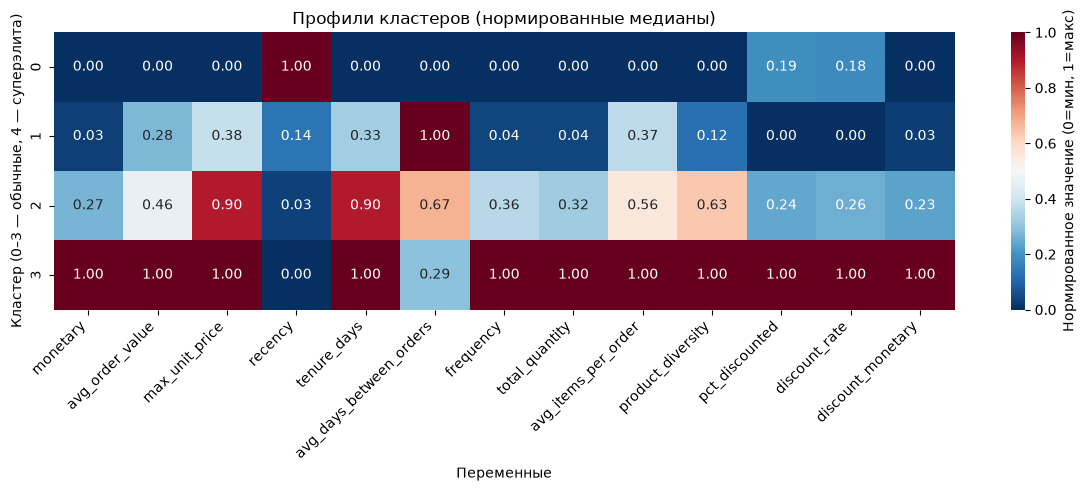

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Выбираем переменные, которые наиболее информативны
vars_for_heatmap = [
    # Ценовые
    'monetary', 'avg_order_value', 'max_unit_price',
    # Временные
    'recency', 'tenure_days', 'avg_days_between_orders',
    # Количественные
    'frequency', 'total_quantity', 'avg_items_per_order', 'product_diversity',
    # Скидки
    'pct_discounted', 'discount_rate', 'discount_monetary'
]

# Рассчитываем медианы по кластерам
medians = customer_df_dop.groupby('cluster_final')[vars_for_heatmap].median()

# Нормализуем (MinMaxScaler) — каждая переменная в диапазоне 0..1
scaler = MinMaxScaler()
medians_norm = pd.DataFrame(
    scaler.fit_transform(medians),
    index=medians.index,
    columns=medians.columns
)

# Строим тепловую карту
plt.figure(figsize=(12, 5))
sns.heatmap(
    medians_norm,
    annot=True,
    cmap='RdBu_r',
    center=0.5,
    fmt='.2f',
    cbar_kws={'label': 'Нормированное значение (0=мин, 1=макс)'}
)
plt.title('Профили кластеров (нормированные медианы)')
plt.xlabel('Переменные')
plt.ylabel('Кластер (0–3 — обычные, 4 — суперэлита)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# display(medians_norm.round(3).T)

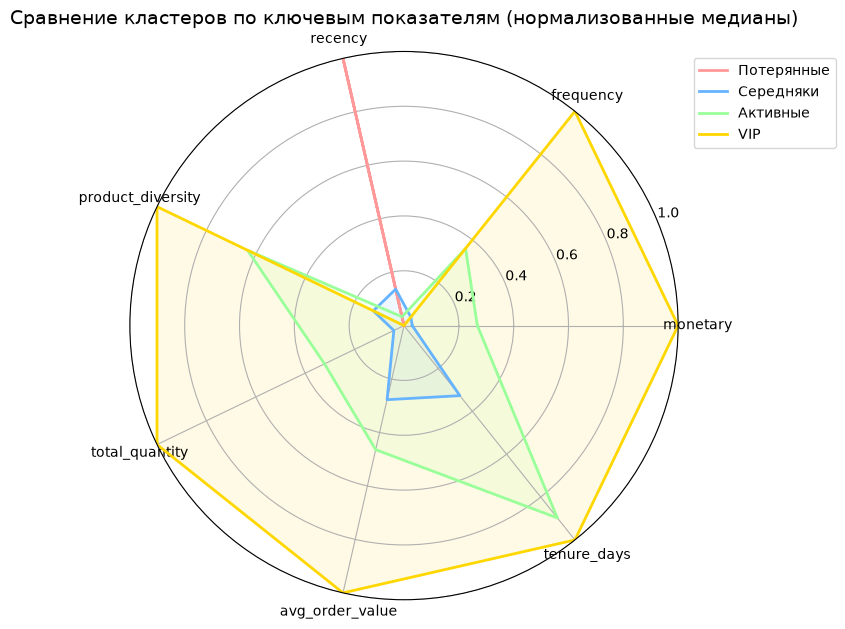

In [ ]:
from math import pi

# Выбираем переменные для радара (7–8 ключевых)
radar_vars = ['monetary', 'frequency', 'recency', 'product_diversity', 
              'total_quantity', 'avg_order_value', 'tenure_days']

# Подготовка
N = len(radar_vars)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Фигура
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

# Цвета кластеров
colors = ['#FF9999', '#66B3FF', '#99FF99', '#FFD700']
labels = ['Потерянные', 'Середняки', 'Активные', 'VIP']

for i, cluster in enumerate(medians_norm.index):
    values = medians_norm.loc[cluster, radar_vars].values.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='-', color=colors[i], label=labels[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

# Настройка
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_vars, size=10)
ax.set_ylim(0, 1)
ax.set_title('Сравнение кластеров по ключевым показателям (нормализованные медианы)', size=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

**1. Потерянные (кластер 0)**
- По всем ключевым показателям (monetary, frequency, tenure, diversity) они имеют значение 0 — это наихудший профиль.
- Единственный показатель, где они "лидируют" — **recency = 1** наибольшая давность. 
<!-- - При этом доля клиентов в кластере — 24%, а доля выручки — всего 5.4%. -->
- Это классические «одноразовые» клиенты: пришли, купили, ушли.

**2. Середние (кластер 1) — «зона риска»**
- У них один из самых высоких показателей **avg_days_between_orders = 1** — они покупают реже всех среди тех, кто делает повторные покупки.
- Их профиль близок к потерянным по monetary (0.030) и frequency (0.040), но они уже имеют некоторую историю.
<!-- - При этом их доля в базе — 62%, а выручки — 30%. Это значит, что каждый середняк в среднем приносит в 5 раз меньше, чем активный клиент. -->
- Это самая опасная группа: они «зависли» между оттоком и активностью. Если их не стимулировать, они скатятся в кластер 0.

**3. Активные (кластер 2) — «Золотая середина»**
- По большинству показателей они находятся на уровне 0.3–0.6 от максимума — значительно лучше среднего класса.
- При этом они не достигают уровня VIP по monetary (0.268) и частоте (0.360), но уже заметно выделяются на фоне остальных. Особенно обнадёживает длительность сотрудничества.
<!-- - Доля клиентов — 12%, выручки — 31%. Один активный клиент приносит в среднем в 3 раза больше выручки, чем середняк. -->

**4. VIP (кластер 3) — «Абсолютный максимум»**
- По всем ключевым показателям (monetary, frequency, diversity, quantity) они имеют значение **1**.
- Вместе с тем это самые «свежие» клиенты (recency = 0 ).
<!-- - Доля клиентов — всего 2.4%, а выручки — 33.8%. Один VIP-клиент приносит в среднем в 14 раз больше выручки, чем середняк. -->

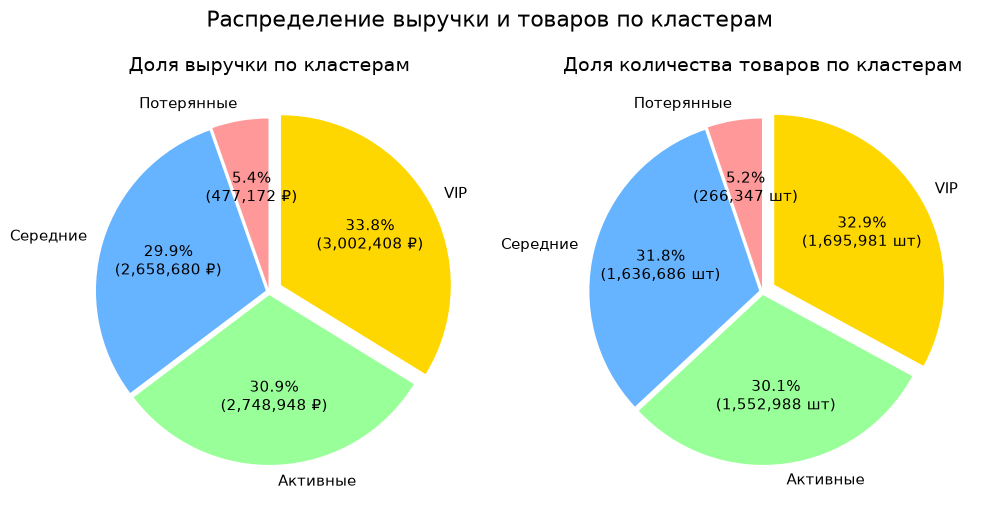


=== Сравнение долей ===
Кластер         Клиенты    Выручка    Товары    
---------------------------------------------
Потерянные      24.2%   5.4%    5.2%
Середние        61.7%   29.9%   31.8%
Активные        11.7%   30.9%   30.1%
VIP             2.4%    33.8%   32.9%


In [157]:
import matplotlib.pyplot as plt

# Данные по кластерам
cluster_labels = ['Потерянные', 'Середние', 'Активные', 'VIP']
colors = ['#FF9999', '#66B3FF', '#99FF99', '#FFD700']
explode = (0.02, 0.02, 0.02, 0.08)  # немного выделяем VIP

# Доли выручки и товаров
monetary_by_cluster = customer_df_dop.groupby('cluster_final')['monetary'].sum()
quantity_by_cluster = customer_df_dop.groupby('cluster_final')['total_quantity'].sum()

# Общие суммы
total_monetary = monetary_by_cluster.sum()
total_quantity = quantity_by_cluster.sum()

# Создаём фигуру с двумя subplot'ами в одной строке
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Первая диаграмма: выручка
wedges1, texts1, autotexts1 = ax1.pie(
    monetary_by_cluster,
    labels=cluster_labels,
    autopct=lambda pct: f'{pct:.1f}%\n({pct/100 * total_monetary:,.0f} ₽)',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 11}
)
ax1.set_title('Доля выручки по кластерам', fontsize=14)

# Вторая диаграмма: количество товаров
wedges2, texts2, autotexts2 = ax2.pie(
    quantity_by_cluster,
    labels=cluster_labels,
    autopct=lambda pct: f'{pct:.1f}%\n({pct/100 * total_quantity:,.0f} шт)',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 11}
)
ax2.set_title('Доля количества товаров по кластерам', fontsize=14)

# Общий заголовок
fig.suptitle('Распределение выручки и товаров по кластерам', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

# Сравнение: доля клиентов vs доля выручки vs доля товаров
print("\n=== Сравнение долей ===")
print(f"{'Кластер':<15} {'Клиенты':<10} {'Выручка':<10} {'Товары':<10}")
print("-"*45)
for i, label in enumerate(cluster_labels):
    clients_pct = customer_df_dop[customer_df_dop['cluster_final']==i].shape[0] / len(customer_df_dop) * 100
    mon_pct = monetary_by_cluster.iloc[i] / monetary_by_cluster.sum() * 100
    qty_pct = quantity_by_cluster.iloc[i] / quantity_by_cluster.sum() * 100
    print(f"{label:<15} {clients_pct:.1f}%{' ' * (7 - len(f'{clients_pct:.1f}%'))} {mon_pct:.1f}%{' ' * (7 - len(f'{mon_pct:.1f}%'))} {qty_pct:.1f}%")

####  Распределение долей: клиенты vs выручка vs количество товаров

Для сравнения эффективности классов:

Эффективность % выручки/ %клиентов
0) Потерянные: 5.4 / 24.2 ≈ 0.22 (в 2 раза хуже середних)
1) Средние: 9.9 / 61.7 ≈ 0.48
2) Активные: 30.9 / 11.7 ≈ 2.64 (в 5.5 раз эффективнее середних)
3) VIP: 33.8 / 2.4 ≈ 14.08 (в 29 раз эффективнее Середних(1) и в 5 раз эффективнее Активных(2))

Потерянные: 

---

0. **Потерянные (24.2% базы) приносят всего 5.4% выручки.**  
   Несмотря на то что эта группа вторая по численности затраты на их возврат могут не окупиться. Более того, их доля в товарах (5.2%) совпадает с долей выручки — они покупают мало и дёшево. Это группа, где реактивация должна быть точечной и дешёвой, либо их можно не возвращать вообще.

1. **средние клиенты (61.7% базы) дают 29.9% выручки.**  
   Это основная масса, но её эффективность (0.48) в 5 раз ниже, чем у активных. Это группа с наибольшим потенциалом роста: если сместить хотя бы часть средние в активные, выручка может значительно вырасти.

2. **Активные (11.7% базы) дают 30.9% выручки.**  
  Их доля в товарах (30.1%) почти равна доле выручки, что говорит о том, что в общем они покупают столько же товаров, сколько средние, но приносят такую же выручку — то есть один активный клиент гораздо ( ~ в 5 раз ) ценнее 1ого среднего.

3. **VIP (2.4% базы) дают 33.8% выручки.**  
    Самые ценные клиенты, один VIP в 29 раз эффективнее Середнего(1) и в 5 раз эффективнее Активного(2)

---

#### Почему оттоком (кластер 0) пренебрегают

Кластер кластер 0 (потерянные) составляет более 20% базы, это казалось слишком большой долей. Теперь стала ясна причина почему так происходит:

1. **Они не приносят денег.** При 24% клиентов они дают только 5.4% выручки. Это значит, что даже если удастся вернуть хотябы 10% из них, прирост выручки будет менее 0.5% от общей — несоизмеримо с затратами на кампанию.

2. **Их возврат сложен.** У них низкая частота (1–2 покупки), давняя recency и узкий ассортимент. Это значит, что у бизнеса нет данных о их предпочтениях, и персонализация будет сложной.

3. **Ресурсы ограничены.** Гораздо эффективнее вложить бюджет в удержание VIP  или в развитие средних.

**Вывод:**  
Основной фокус должен быть на:
- **Удержании VIP** (100% приоритет).
- **Переводе средние в активные** (наибольший потенциал роста).
- **Точечной реактивации** только тех средние, у которых есть признаки потенциала (например, высокий `product_diversity` или `max_unit_price`).
- **Потерянные** — только если есть свободный бюджет и дешёвые каналы коммуникации (например, email-рассылка).

### Кластер 3 - VIP

In [74]:
segments_3 = customer_df_dop[customer_df_dop['cluster_final'] == 3]
segments_3[price_columns+time_columns+quantity_columns+discount_columns].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
monetary,105.0,28594.37,45383.27,5781.73,8134.94,13027.45,26626.80,280206.02
avg_unit_price,105.0,3.43,3.44,1.07,2.44,2.94,3.61,36.19
median_unit_price,105.0,2.15,0.88,1.04,1.65,1.95,2.10,6.75
max_unit_price,105.0,134.29,810.97,2.55,12.75,16.65,20.80,8142.75
min_unit_price,105.0,0.29,0.26,0.04,0.12,0.19,0.39,1.65
avg_order_value,105.0,763.28,910.08,129.85,354.47,465.42,699.16,5948.31
recency,105.0,6.70,7.68,1.00,2.00,4.00,9.00,39.00
tenure_days,105.0,349.62,29.17,203.00,350.00,361.00,366.00,373.00
avg_days_between_orders,105.0,13.21,5.05,1.79,9.67,14.00,16.81,21.88
purchase_regularity,105.0,11.65,5.17,1.87,8.13,11.43,14.85,28.35


### Портрет кластера VIP (Кластер 3)

**Размер:** 105 клиентов (2.4% от всей базы)  
**Характер:** Крупные оптовые клиенты, бизнес-покупатели (магазины подарков, организаторы мероприятий, офисные закупки).

---

**Денежные показатели:** VIP-клиенты тратят большие суммы, но не за счёт огромных чеков, а за счёт высокой частоты и количества покупок. 

**Временные показатели:** VIP-клиенты — это «идеальные» клиенты с точки зрения времени: они покупают часто, регулярно, стабильно и давно. Их поведение максимально предсказуемо, что позволит бизнесу точно под них планировать акции.

**Объём и разнообразие:** VIP-клиенты покупают в больших объёмах и с большим разнообразием. Они не просто берут много одного товара, а закупают целый ассортимент, что говорит о том, что это оптовики (магазины, закупщики).

**Скидочное поведение:** VIP-клиенты активно используют скидки и получают самые высокие из всех групп. Это связано с оптовыми условиями и эксклюзивными предложениями.

---

#### Рекомендации для VIP-кластера

1. **Персональное обслуживание.** Учитывая высокую ценность и частоту, каждому такому клиенту стоит выделить персонального менеджера для оперативного решения вопросов.

2. **Эксклюзивные условия.** Предлагать закрытые распродажи, ранний доступ к новинкам, индивидуальные скидки (не ниже текущего уровня). 

3. **Мониторинг удовлетворённости.** Регулярно собирать обратную связь, чтобы предотвратить возможный отток. Даже один потерянный VIP-клиент — это существенная потеря выручки.

4. **Расширение ассортимента.** У них высокое разнообразие, но есть потенциал ещё больше увеличить `product_diversity`. Предлагать новинки, категории, которые они ещё не пробовали.

5. **Предсказание потребностей.** Учитывая высокую регулярность, можно строить прогнозы и предлагать товары на основе их истории покупок (алгоритмы рекомендаций).

6. **Специальные мероприятия.** Приглашать на закрытые презентации, дегустации, мастер-классы — для укрепления эмоциональной связи.

### Кластер 2

In [75]:
segments_2 = customer_df_dop[customer_df_dop['cluster_final'] == 2]
segments_2[price_columns+time_columns+quantity_columns+discount_columns].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
monetary,509.0,5400.68,9700.69,801.12,2527.92,3711.77,5398.30,168472.50
avg_unit_price,509.0,4.63,20.26,0.40,2.35,2.91,3.72,434.65
median_unit_price,509.0,3.38,28.71,0.24,1.65,1.95,2.10,649.50
max_unit_price,509.0,63.41,333.53,0.40,12.75,15.95,19.95,4161.06
min_unit_price,509.0,0.32,0.36,0.04,0.19,0.29,0.39,4.95
avg_order_value,509.0,838.91,5122.54,33.24,233.92,338.89,500.16,84236.25
recency,509.0,23.78,36.39,1.00,4.00,12.00,28.00,372.00
tenure_days,509.0,297.20,75.70,0.00,261.00,324.00,354.00,372.00
avg_days_between_orders,509.0,32.99,14.68,0.00,24.50,32.09,40.50,204.00
purchase_regularity,507.0,27.41,15.67,0.00,16.94,24.43,35.21,105.58


### Портрет кластера Активные (Кластер 2)
**Размер:** 509 клиентов (11.7% от всей базы)

**Характер:** Лояльные, регулярные покупатели с высоким потенциалом перехода в VIP. Это клиенты, которые уже сформировали привычку покупать, но ещё не достигли максимального уровня.

---

**Денежные показатели:** Активные клиенты тратят значительно больше, чем середние (медиана monetary — 3 712 ₽ против 692 ₽), но их средний чек (339 ₽) лишь немного выше (середние — 295 ₽).

**Временные показатели:** Это клиенты с высокой лояльностью (tenure — 324 дня, почти год). Они покупают регулярно (avg_days_between_orders — 32 дня), но их поведение менее стабильно, чем у VIP (purchase_regularity — 24.4 против 11.4). Они уже «созрели» для перехода на следующий уровень.

**Объём и разнообразие:** Активные клиенты покупают в 5 раз больше товаров, чем середние (total_quantity — 2088 шт), и их ассортимент в 3 раза шире (product_diversity — 119 против 37). Они уже пробуют разные категории, но до VIP им ещё не хватает масштаба.

**Скидочное поведение:** Активные клиенты активно используют скидки (pct_discounted — 0.67, discount_rate — 0.71), но их максимальная скидка (84.9%) ниже, чем у VIP (88.3%). Они участвуют в акциях, но не имеют эксклюзивных условий.

---
**Рекомендации для кластера Активные**
1. Стимулирование частоты. У них уже хорошая регулярность, но можно усилить — например, программа лояльности с бонусами за каждую 5-ю покупку.

2. Увеличение среднего чека. Их avg_order_value (339 ₽) ниже, чем у VIP (465 ₽).

3. Расширение ассортимента. Product_diversity (119) уже выше среднего, но до VIP (178) ещё далеко. Рекомендовать новинки, товары из категорий, которые они ещё не пробовали.

4. Персонализация. У них уже достаточно истории покупок для построения рекомендаций. Использовать алгоритмы, чтобы предлагать товары на основе их предпочтений.

5. Удержание. Они уже почти «дозрели» до VIP. Важно не потерять их на этом этапе. Отслеживать признаки снижения активности (увеличение recency по сравнению с avg_days_between_orders, падение frequency).

### Кластер 1

In [76]:
segments_1 = customer_df_dop[customer_df_dop['cluster_final'] == 1]
segments_1[price_columns+time_columns+quantity_columns+discount_columns].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
monetary,2675.0,993.90,949.82,6.20,343.48,692.19,1324.50,11072.67
avg_unit_price,2675.0,4.32,41.20,0.12,2.15,2.84,3.68,2033.10
median_unit_price,2675.0,3.37,41.22,0.11,1.55,1.95,2.55,2033.10
max_unit_price,2675.0,18.66,59.33,0.17,8.25,12.50,16.95,2033.10
min_unit_price,2675.0,1.51,40.37,0.00,0.21,0.39,0.55,2033.10
avg_order_value,2675.0,365.71,360.85,3.45,182.62,294.71,426.00,6207.67
recency,2675.0,47.41,37.03,1.00,18.00,37.00,71.00,169.00
tenure_days,2675.0,131.25,121.23,0.00,0.00,118.00,237.00,371.00
avg_days_between_orders,2675.0,62.66,71.97,0.00,0.00,47.67,88.67,365.00
purchase_regularity,1290.0,50.01,39.83,0.00,22.53,39.94,65.95,242.54


### Портрет кластера Середние (Кластер 1)
**Размер:** 2675 клиентов (61.7% от всей базы)

**Характер:** Основная масса клиентов, «серая зона» между оттоком и активностью. Часть из них — новые клиенты, часть — уже имеют некоторую историю, но покупают нерегулярно. Это группа с наибольшим потенциалом для роста.

**Денежные показатели:** Середние тратят умеренно (медиана monetary — 692 ₽), их средний чек (295 ₽) лишь немного выше, чем у потерянных (229 ₽). Основная выручка формируется за счёт количества клиентов, а не их активности.

**Временные показатели:** Это самая неоднородная группа. Медиана recency — 37 дней, но 25% клиентов имеют recency менее 18 дней (активные), а 25% — более 71 дня (близки к оттоку). Tenure (118 дней) показывает, что часть клиентов уже имеет некоторую историю, но 25% клиентов — новые (tenure = 0). Средний интервал между заказами (47.7 дней) указывает на сезонные покупки (возможно, к праздникам).

**Объём и разнообразие:** Середние покупают в 2.7 раза больше товаров, чем потерянные (total_quantity — 397 шт), и их ассортимент шире (product_diversity — 37 против 17). Однако до активных им ещё далеко.

**Скидочное поведение:** Середние используют скидки умеренно (pct_discounted — 0.65, discount_rate — 0.67), их максимальная скидка (73.2%) ниже, чем у активных (84.9%). Они получают скидки, но не являются приоритетной группой для эксклюзивных предложений.

---

**Рекомендации для кластера Середние**
Стимулирование повторных покупок. У них уже есть история, но частота низкая. Запустить кампании «скидка на следующую покупку», напоминания о магазине через email или push-уведомления.

Вовлечение новых клиентов. Часть кластера — новые клиенты (tenure = 0).

Расширение ассортимента. Product_diversity (37) почти в 3 раза ниже, чем у активных (119). Предлагать товары из категорий, которые они уже покупали, и смежные категории.

Сезонные кампании. Интервал 47.7 дней может указывать на покупки к праздникам. Планировать коммуникации к сезонным событиям.

Персонализация. У них уже достаточно данных для начала персонализации. 

Предотвращение оттока. Часть середняков (с recency > 71 дня) рискует перейти в потерянные. Для них — реактивационные кампании.

### кластер 0

In [77]:
segments_0 = customer_df_dop[customer_df_dop['cluster_final'] == 0]
segments_0[price_columns+time_columns+quantity_columns+discount_columns].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
monetary,1049.0,454.88,598.04,3.75,167.55,308.58,517.55,9864.26
avg_unit_price,1049.0,4.89,17.69,0.37,2.29,3.23,4.56,451.42
median_unit_price,1049.0,3.77,17.50,0.19,1.65,2.10,2.95,451.42
max_unit_price,1049.0,16.08,34.17,0.42,5.95,9.95,14.95,523.00
min_unit_price,1049.0,1.95,17.44,0.00,0.29,0.55,0.85,451.42
avg_order_value,1049.0,311.08,325.44,3.75,139.35,229.26,363.65,4932.13
recency,1049.0,249.56,65.87,142.00,192.00,246.00,302.00,374.00
tenure_days,1049.0,25.55,49.54,0.00,0.00,0.00,29.00,223.00
avg_days_between_orders,1049.0,19.29,40.03,0.00,0.00,0.00,17.00,223.00
purchase_regularity,108.0,33.45,28.30,1.73,12.00,23.28,50.93,147.79


#### Портрет кластера Потерянные (Кластер 0)

**Размер:** 1049 клиентов (24.2% от всей базы)

**Характер:** Клиенты, совершившие одну-две покупки и более не возвращавшиеся. Они либо пришли по разовому поводу (подарок), либо не нашли причину остаться.

---

**Денежные показатели:** Минимальные траты (медиана monetary — 309 ₽), средний чек (229 ₽) — самый низкий среди всех кластеров. Они покупают дёшево и мало.

**Временные показатели:** Самая высокая recency, у большинства клиентов одна покупка. Те, у кого есть история, совершили 2–3 покупки за короткий промежуток времени (avg_days_between_orders = 0 у 75% клиентов).

**Объём и разнообразие:** Минимальные объёмы (total_quantity — 149 шт), очень узкий ассортимент (product_diversity — 17). Клиенты покупают только самые популярные товары, не проявляя интереса к другим категориям.

**Скидочное поведение:** Используют скидки примерно так же часто, как и другие (pct_discounted — 0.67).

---

**Рекомендации для кластера Потерянные**

1. Точечная реактивация. Не все потерянные одинаковы: у 25% клиентов recency < 192 дней (ещё не критично), у 25% tenure > 0 (были повторные покупки). Можно выделить подгруппу с потенциалом возврата (recency < 6 месяцев, tenure > 0) и предложить им персонализированную скидку к крупным праздникам.

2. Минимальные инвестиции. Учитывая низкую эффективность (0.22), затраты на возврат должны быть минимальными — email-рассылка, push-уведомления, без дорогих каналов.

3. Анализ причин ухода. Возможно, они не нашли нужный товар или не получили достаточного сервиса. 

4. Не тратить бюджет на всех. Большинство потерянных (recency > 6 месяцев, одна покупка) вряд ли вернутся.

### Возможные дополнения к анализу

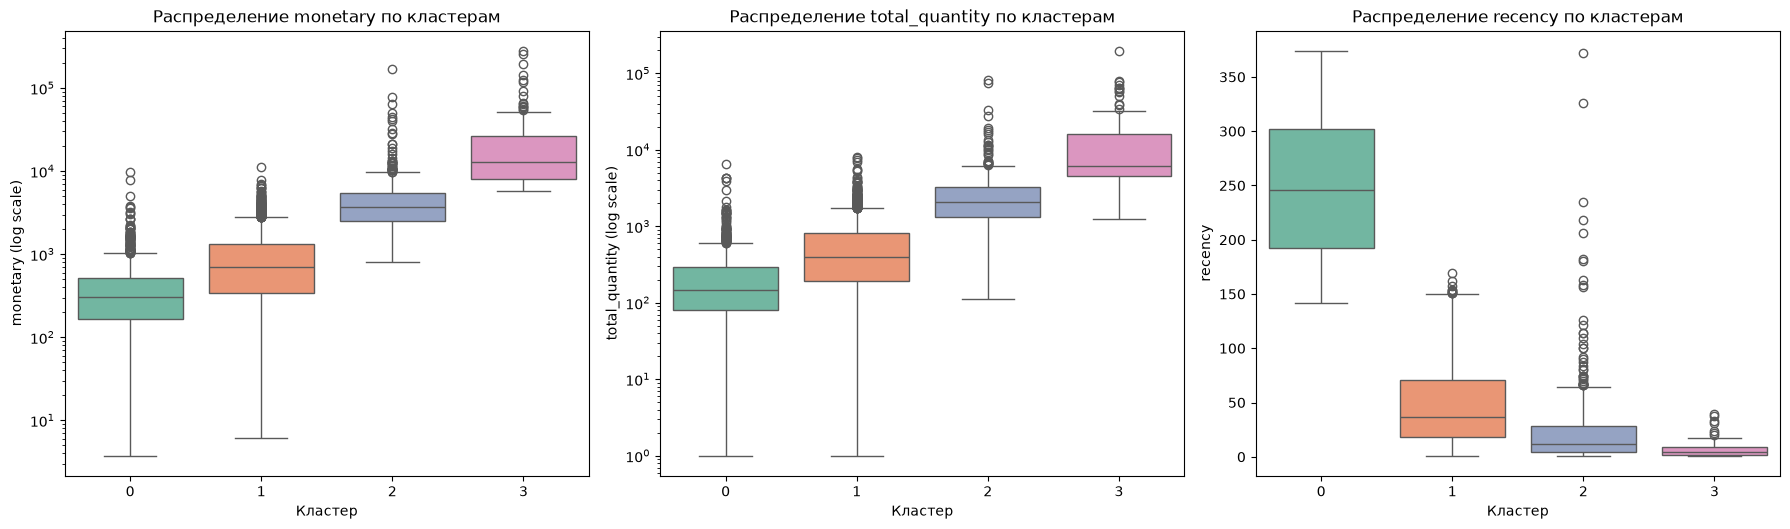

In [131]:
# Переменные, которые лучше всего разделяют кластеры
boxplot_vars = [
    'monetary',
    # 'avg_order_value',
    'total_quantity',
    'recency',
    # 'pct_discounted'
]

# Настройка сетки
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(boxplot_vars):
    ax = axes[idx]
    sns.boxplot(
        x='cluster_final',
        y=var,
        data=customer_df_dop,
        ax=ax,
        palette='Set2',
        hue='cluster_final',
        legend=False
    )
    ax.set_title(f'Распределение {var} по кластерам')
    ax.set_xlabel('Кластер')
    ax.set_ylabel(var)
    # Для monetary, total_quantity используем логарифмическую шкалу
    if var in ['monetary', 'total_quantity']:
        ax.set_yscale('log')
        ax.set_ylabel(f'{var} (log scale)')

# Убираем пустой график (если boxplot_vars меньше 6)
if len(boxplot_vars) < 6:
    for i in range(len(boxplot_vars), 6):
        fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
clusters_1 = customer_df_dop[customer_df_dop['cluster_final']==1]
extra_vars = ['tenure_days', 'avg_days_between_orders', 'monetary', 'frequency', 'recency']

# Группировка по кластеру и сегменту, вычисляем медианы
segment_medians = clusters_1.groupby(['cluster_final', 'RFM_segment'])[extra_vars].median().round(2).reset_index()


print(f"\n=== Кластер 1 — медианы по RFM-сегментам ===")
data = segment_medians[segment_medians['cluster_final'] == 1]

display(data.sort_values('recency'))



=== Кластер 1 — медианы по RFM-сегментам ===


,cluster_final,segment,tenure_days,avg_days_between_orders,monetary,frequency,recency
26,1,3-3-3,264.5,55.98,1935.49,6.0,10.0
20,1,3-1-3,0.0,0.00,1757.55,1.0,11.0
25,1,3-3-2,273.0,58.40,962.39,5.0,11.0
24,1,3-3-1,269.0,52.33,220.10,6.0,12.0
23,1,3-2-3,182.0,75.00,1643.18,4.0,12.0
21,1,3-2-1,117.0,96.00,271.40,2.0,12.0
22,1,3-2-2,153.0,75.83,692.54,3.0,13.0
18,1,3-1-1,0.0,0.00,196.92,1.0,16.5
19,1,3-1-2,0.0,0.00,542.25,1.0,19.0
16,1,2-3-2,271.0,56.71,888.32,5.0,41.0


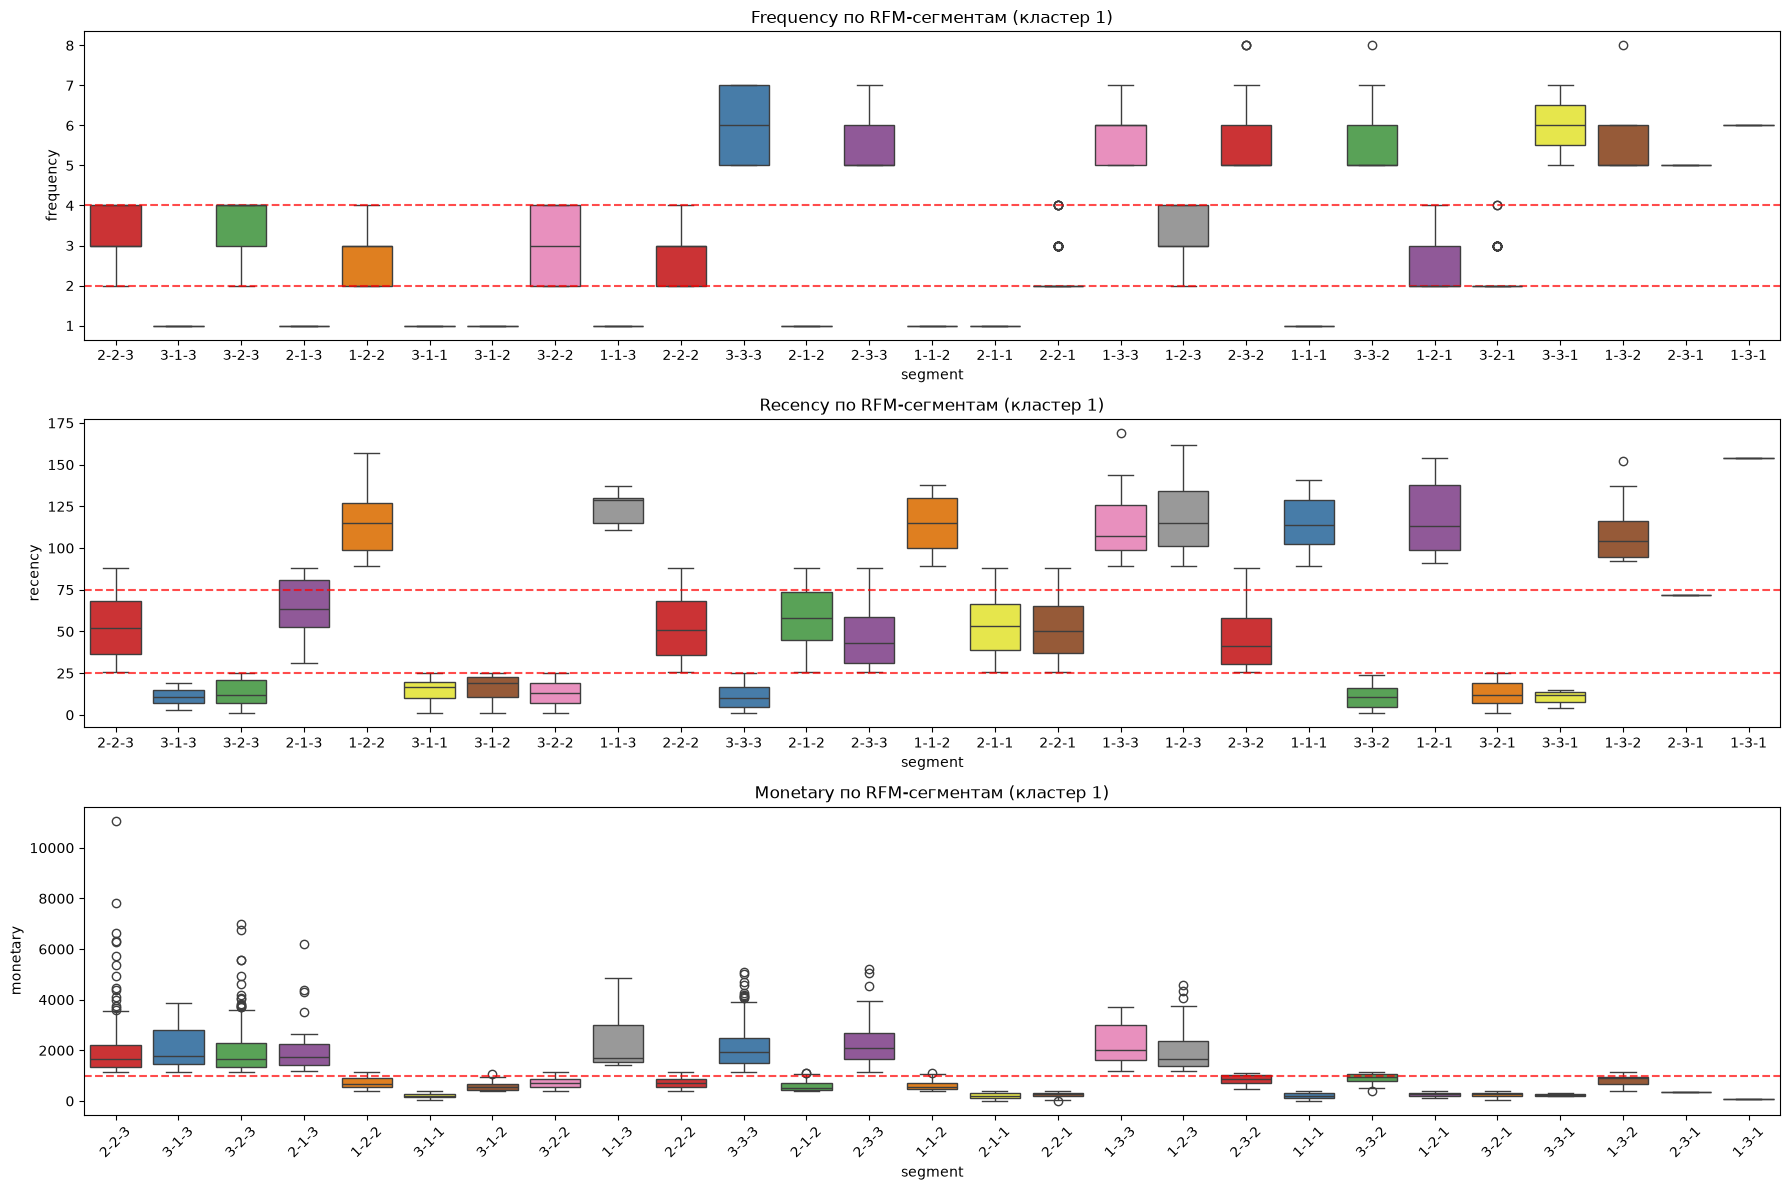

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Возьмём только кластер 1
cluster1 = customer_df_dop[customer_df_dop['cluster_final'] == 1]

# Выберем топ-10 сегментов по численности
top_segments = cluster1['RFM_segment'].value_counts().index
cluster1_top = cluster1[cluster1['RFM_segment'].isin(top_segments)]

fig, axes = plt.subplots(3, 1, figsize=(18, 12))

sns.boxplot(x='RFM_segment', y='frequency', data=cluster1_top, 
            hue='RFM_segment', palette='Set1', legend=False, ax=axes[0])
axes[0].axhline(2, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].axhline(4, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].set_title('Frequency по RFM-сегментам (кластер 1)')

sns.boxplot(x='RFM_segment', y='recency', data=cluster1_top, 
            hue='RFM_segment', palette='Set1', legend=False, ax=axes[1])
axes[1].axhline(25, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].axhline(75, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].set_title('Recency по RFM-сегментам (кластер 1)')

sns.boxplot(x='RFM_segment', y='monetary', data=cluster1_top, 
            hue='RFM_segment', palette='Set1', legend=False, ax=axes[2])
axes[2].axhline(1000, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[2].set_title('Monetary по RFM-сегментам (кластер 1)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Детализация кластера 1 (Середних клиентов)

Кластер «Середних клиентов» является самым крупным (61.7% базы) и неоднородным. Чтобы разработать более точные стратегии, мы выделили внутри него **4 подгруппы**, используя комбинацию **recency, tenure_days, frequency и monetary**.

---

#### Обоснование выделения подгрупп

На основе **boxplot** по RFM-сегментам внутри кластера 1 были визуально определены естественные границы:

| Показатель | Низкие значения | Средние значения | Высокие значения |
|------------|----------------|------------------|------------------|
| **Frequency** | < 2 | 2–4 | > 4 |
| **Recency** | > 75 дней | 26–75 дней | < 25 дней |
| **Monetary** | < 1000 | — | > 1000 |

Дополнительно было учтено, что **tenure_days** (длительность сотрудничества) позволяет отделить новых клиентов (tenure = 0) от тех, у кого уже есть история повторных покупок.

In [138]:
# Берём данные по кластеру 1
cluster1 = customer_df_dop[customer_df_dop['cluster_final'] == 1].copy()
print('Всего в классе: ',len(cluster1))

# Присваиваем метки
def assign_subgroup(row):
    rec = row['recency']
    ten = row['tenure_days']
    freq = row['frequency']
    
    # Новые клиенты — одна покупка, нет истории
    if ten < 150 and freq < 3:
        return 'new'
    
    # Перспективные — долгая история, недавние, частые (≥ 6 заказов)
    if ten > 100 and rec <= 50 and freq > 5:
        return '1a_Перспективные'
    
    # Стабильные средние — долгая история,  частота (≥ 3 заказов)
    if ten > 100 and freq >= 3:
        return '1b_Средние'
    
    # Остальные — промежуточная группа с потенциалом
    return '1c_остальные'

cluster1['subgroup'] = cluster1.apply(assign_subgroup, axis=1)

# Проверяем распределение
print("\nРаспределение по подгруппам в кластере 1:")
print(cluster1['subgroup'].value_counts())


# Расчёт статистик по подгруппам
# ============================================================

# Выбираем переменные для описания
vars_to_describe = [
    'monetary', 'avg_order_value', 'recency', 'tenure_days', 'avg_days_between_orders', 'purchase_regularity',
    'frequency', 'total_quantity', 'avg_items_per_order', 'product_diversity',
]

# Группируем и считаем медианы (можно и средние, но медианы устойчивее)
subgroup_medians = cluster1.groupby('subgroup')[vars_to_describe].median().round(2)

print("\n=== Медианы по подгруппам кластера 1 ===")
display(subgroup_medians)

# Дополнительно: основные статистики (mean, std, quartiles) для каждой подгруппы
# Можно вывести describe для каждой подгруппы отдельно
print("\n=== Подробная статистика для подгруппы 1a (Перспективные) ===")
display(cluster1[cluster1['subgroup'] == '1a_Перспективные'][vars_to_describe].describe().round(2))

print("\n=== Подгруппа 1b (Стабильные) ===")
display(cluster1[cluster1['subgroup'] == '1b_Средние'][vars_to_describe].describe().round(2))

print("\n=== Подгруппа new  ===")
display(cluster1[cluster1['subgroup'] == 'new'][vars_to_describe].describe().round(2))

print("\n=== Подгруппа 1c  ===")
display(cluster1[cluster1['subgroup'] == '1c_остальные'][vars_to_describe].describe().round(2))

# Сравнение подгрупп с кластерами 0 и 2 (для контекста)
# ======================================================

# Добавляем метку подгруппы в общий датафрейм
customer_df_dop.loc[cluster1.index, 'subgroup'] = cluster1['subgroup']

# Сводная таблица медиан для всех кластеров и подгрупп (для сравнения)
# Берём ключевые метрики
key_metrics = ['monetary', 'frequency', 'recency', 'tenure_days', 'product_diversity']
summary_all = customer_df_dop.groupby('cluster_final')[key_metrics].median().round(2)
summary_subgroups = cluster1.groupby('subgroup')[key_metrics].median().round(2)

print("\n=== Сравнение кластеров и подгрупп (медианы) ===")
print("Кластеры:")
display(summary_all)
print("Подгруппы кластера 1:")
display(summary_subgroups)

Всего в классе:  2675

Распределение по подгруппам в кластере 1:
subgroup
new                 1139
1b_Средние           909
1c_остальные         444
1a_Перспективные     183
Name: count, dtype: int64

=== Медианы по подгруппам кластера 1 ===


,monetary,avg_order_value,recency,tenure_days,avg_days_between_orders,purchase_regularity,frequency,total_quantity,avg_items_per_order,product_diversity
subgroup,,,,,,,,,,
1a_Перспективные,1827.80,290.10,16.0,284.0,53.2,37.69,6.0,1071.0,163.00,80.0
1b_Средние,1179.89,306.86,37.0,228.0,77.0,48.61,4.0,707.0,177.67,59.0
1c_остальные,700.94,283.30,29.0,160.5,160.5,14.14,2.0,398.0,154.40,41.0
new,348.80,287.22,50.0,0.0,0.0,NaN,1.0,210.0,168.00,22.0



=== Подробная статистика для подгруппы 1a (Перспективные) ===


,monetary,avg_order_value,recency,tenure_days,avg_days_between_orders,purchase_regularity,frequency,total_quantity,avg_items_per_order,product_diversity
count,183.00,183.00,183.00,183.00,183.00,183.00,183.00,183.00,183.00,183.00
mean,1902.86,297.61,18.25,278.04,51.37,42.40,6.45,1216.69,190.17,90.61
std,824.40,136.37,12.09,67.17,13.13,23.21,0.52,721.39,115.10,59.10
min,201.12,28.73,1.00,104.00,17.33,8.75,6.00,43.00,6.14,7.00
25%,1289.09,190.71,9.00,237.50,43.18,26.72,6.00,742.50,112.17,49.50
50%,1827.80,290.10,16.00,284.00,53.20,37.69,6.00,1071.00,163.00,80.00
75%,2443.09,370.53,28.00,339.00,59.50,51.06,7.00,1527.00,236.85,117.00
max,4597.02,766.17,50.00,369.00,73.00,137.45,8.00,4376.00,626.67,406.00



=== Подгруппа 1b (Стабильные) ===


...

,monetary,avg_order_value,recency,tenure_days,avg_days_between_orders,purchase_regularity,frequency,total_quantity,avg_items_per_order,product_diversity
count,444.00,444.00,444.00,444.00,444.00,198.00,444.00,444.00,444.00,444.00
mean,944.76,343.77,41.04,156.00,140.83,17.17,2.76,566.19,207.14,54.37
std,813.53,305.05,36.28,101.95,116.08,13.33,1.08,532.11,195.19,50.07
min,52.20,20.81,1.00,0.00,0.00,0.00,2.00,17.00,5.67,1.00
25%,412.75,178.54,12.00,63.75,22.94,7.74,2.00,236.75,97.25,23.00
50%,700.94,283.30,29.00,160.50,160.50,14.14,2.00,398.00,154.40,41.00
75%,1178.00,399.22,64.25,237.00,237.00,23.94,3.00,702.00,261.75,69.00
max,7829.89,3914.94,154.00,365.00,365.00,68.59,7.00,3907.00,1953.50,365.00



=== Сравнение кластеров и подгрупп (медианы) ===
Кластеры:


,monetary,frequency,recency,tenure_days,product_diversity
cluster_final,,,,,
0,308.58,1.0,246.0,0.0,17.0
1,692.19,2.0,37.0,118.0,37.0
2,3711.77,10.0,12.0,324.0,119.0
3,13027.45,26.0,4.0,361.0,178.0


Подгруппы кластера 1:


,monetary,frequency,recency,tenure_days,product_diversity
subgroup,,,,,
1a_Перспективные,1827.80,6.0,16.0,284.0,80.0
1b_Средние,1179.89,4.0,37.0,228.0,59.0
1c_остальные,700.94,2.0,29.0,160.5,41.0
new,348.80,1.0,50.0,0.0,22.0


#### 5.4.7. Бизнес-интерпретация подгрупп

1. **new (42.6%)** — клиенты, которые относительно недавно (в течении последних 5 месяцев) совершили одну-две покупки. Они требуют **вовлечения**

2. **1c_остальные (16.6%)** — клиенты с некоторой историей, но низкой активностью. Они находятся в **«серой зоне»**. Требуется **активация** через кросс-продажи и акции.

3. **1b_Средние (34.0%)** — стабильные клиенты с хорошей историей, которые покупают регулярно. Их нужно **удерживать** и поддерживать текущий уровень.

4. **1a_Перспективные (6.8%)** — самые ценные клиенты в кластере 1. Они близки к кластеру 2 и требуют **агрессивного развития**, чтобы перейти в активные.

### Анализ товарных предпочтений по кластерам
Для этого нужно взять исходный датафрейм (на уровне строк) и связать его с кластерами клиентов. Затем можно посмотреть, какие товары чаще всего покупают в каждом кластере и есть ли товары, уникальные для VIP.

In [87]:
# Связываем товары с кластерами клиентов
# Сначала создаём словарь: CustomerID -> cluster_final
cluster_map = customer_df_dop[['CustomerID', 'cluster_final']].set_index('CustomerID')['cluster_final'].to_dict()

# Добавляем кластер в исходный df (на уровне транзакций)
df_with_cluster = df.copy()
df_with_cluster['cluster_final'] = df_with_cluster['CustomerID'].map(cluster_map)

# Исключаем клиентов, которых нет в customer_df_dop (редко)
df_with_cluster = df_with_cluster.dropna(subset=['cluster_final'])
df_with_cluster['cluster_final'] = df_with_cluster['cluster_final'].astype(int)

# Проверяем распределение
print(df_with_cluster['cluster_final'].value_counts().sort_index())

cluster_final
0     27648
1    169771
2    125778
3     69495
Name: count, dtype: int64


In [147]:
# Топ-10 товаров магазина по общему количеству проданных единиц
top_overall = df_with_cluster.groupby('Description')['Quantity'].sum().reset_index()
top_overall = top_overall.sort_values('Quantity', ascending=False).head(10)

print("\n=== Топ-10 товаров магазина ===")
for _, row in top_overall.iterrows():
    print(f"  {row['Description']}: {row['Quantity']} шт")


=== Топ-10 товаров магазина ===
  PAPER CRAFT , LITTLE BIRDIE: 80995 шт
  MEDIUM CERAMIC TOP STORAGE JAR: 77916 шт
  WORLD WAR 2 GLIDERS ASSTD DESIGNS: 54319 шт
  JUMBO BAG RED RETROSPOT: 46078 шт
  WHITE HANGING HEART T-LIGHT HOLDER: 36706 шт
  ASSORTED COLOUR BIRD ORNAMENT: 35263 шт
  PACK OF 72 RETROSPOT CAKE CASES: 33670 шт
  POPCORN HOLDER: 30919 шт
  RABBIT NIGHT LIGHT: 27153 шт
  MINI PAINT SET VINTAGE : 26076 шт


#### Топ-10 товаров по кластерам

In [103]:
# Топ-10 товаров по кластерам (по количеству проданных единиц)
top_products_by_cluster =df_with_cluster.groupby(['cluster_final', 'Description']).agg(
    quantity_summ=('Quantity','sum'),
    max_unit_price=('UnitPrice', 'max'),        
    median_unit_price=('UnitPrice', 'median'),
).reset_index()

# Для каждого кластера берём топ-10
for cluster in [0, 1, 2, 3]:
    cluster_name = ['Потерянные', 'Середняки', 'Активные', 'VIP'][cluster]
    top = top_products_by_cluster[top_products_by_cluster['cluster_final'] == cluster].nlargest(10, 'quantity_summ')
    print(f"\n=== Топ-10 товаров в кластере {cluster_name} ===")
    for _, row in top.iterrows():
        print(f"  {row['Description']}: {row['quantity_summ']} шт | price: {row['median_unit_price']} ")


=== Топ-10 товаров в кластере Потерянные ===
  WORLD WAR 2 GLIDERS ASSTD DESIGNS: 5089 шт | price: 0.29 
  SMALL POPCORN HOLDER: 4975 шт | price: 0.85 
  ASSORTED COLOURS SILK FAN: 3848 шт | price: 0.83 
  WHITE HANGING HEART T-LIGHT HOLDER: 2138 шт | price: 2.95 
  MINI PAINT SET VINTAGE : 2089 шт | price: 0.65 
  PACK OF 72 RETROSPOT CAKE CASES: 1811 шт | price: 0.55 
  RED  HARMONICA IN BOX : 1791 шт | price: 1.25 
  ROUND SNACK BOXES SET OF 4 FRUITS : 1628 шт | price: 2.95 
  BROCADE RING PURSE : 1593 шт | price: 0.29 
  ASSORTED COLOUR BIRD ORNAMENT: 1575 шт | price: 1.69 

=== Топ-10 товаров в кластере Середняки ===
  WORLD WAR 2 GLIDERS ASSTD DESIGNS: 17486 шт | price: 0.29 
  SMALL CHINESE STYLE SCISSOR: 12802 шт | price: 0.42 
  ASSORTED COLOUR BIRD ORNAMENT: 11333 шт | price: 1.69 
  JUMBO BAG RED RETROSPOT: 10764 шт | price: 2.08 
  PACK OF 72 RETROSPOT CAKE CASES: 8813 шт | price: 0.55 
  WHITE HANGING HEART T-LIGHT HOLDER: 8270 шт | price: 2.95 
  BROCADE RING PURSE : 815

### Уникальные товары для класса

In [143]:
# Сравнение доли VIP в покупках каждого товара
product_by_cluster = df_with_cluster.groupby(['Description', 'cluster_final'])['Quantity'].sum().unstack(fill_value=0)
product_by_cluster.columns = ['Q0', 'Q1', 'Q2', 'Q3']  # Потерянные, Середняки, Активные, VIP

# Добавляем общее количество и долю VIP
product_by_cluster['total'] = product_by_cluster.sum(axis=1)
product_by_cluster['Q0_share'] = product_by_cluster['Q0'] / product_by_cluster['total'] * 100
product_by_cluster['Q1_share'] = product_by_cluster['Q1'] / product_by_cluster['total'] * 100
product_by_cluster['Q2_share'] = product_by_cluster['Q2'] / product_by_cluster['total'] * 100
product_by_cluster['vip_share'] = product_by_cluster['Q3'] / product_by_cluster['total'] * 100

# Товары, где VIP занимает > 50% продаж (и всего продаж > 100 шт, чтобы исключить случайности)
vip_dominated = product_by_cluster[(product_by_cluster['vip_share'] > 50) & (product_by_cluster['total'] > 100)].sort_values('vip_share', ascending=False)

print(f"\n=== Товары, где VIP-класс доминирует (>50% продаж) ===")
print(f"Найдено {len(vip_dominated)} товаров")
display(vip_dominated.head(15).round(1))


=== Товары, где VIP-класс доминирует (>50% продаж) ===
Найдено 417 товаров


,Q0,Q1,Q2,Q3,total,Q0_share,Q1_share,Q2_share,vip_share
Description,,,,,,,,,
LUNCH BAG RED SPOTTY,0,0,0,200,200,0.0,0.0,0.0,100.0
POTTING SHED CANDLE CITRONELLA,0,0,0,402,402,0.0,0.0,0.0,100.0
MISELTOE HEART WREATH CREAM,0,0,0,240,240,0.0,0.0,0.0,100.0
SET/5 RED SPOTTY LID GLASS BOWLS,0,0,0,288,288,0.0,0.0,0.0,100.0
POTTING SHED ROSE CANDLE,1,2,2,440,445,0.2,0.4,0.4,98.9
PINK RIVIERA HANDBAG,1,2,1,181,185,0.5,1.1,0.5,97.8
CAT AND BIRD WALL ART,0,0,6,264,270,0.0,0.0,2.2,97.8
DOG AND BALL WALL ART,0,0,6,246,252,0.0,0.0,2.4,97.6
UTILTY CABINET WITH HOOKS,1,1,3,126,131,0.8,0.8,2.3,96.2


**Кластер 3 (VIP)** — крупные оптовые закупки:
- **JUMBO BAG RED RETROSPOT** (23258 шт, цена 1.95) — самый популярный товар у VIP.
- **WORLD WAR 2 GLIDERS ASSTD DESIGNS** (22656 шт, цена 0.29) — также покупают много дешёвых товаров.
- **POPCORN HOLDER** (15356 шт, цена 0.85).

**Характер:** VIP-клиенты покупают **очень большие партии** как дешёвых, так и более дорогих товаров. Их корзина включает широкий ассортимент — от самых дешёвых позиций до товаров со средней ценой.

**Товары, где VIP-класс доминирует (>50% продаж) — 417 товаров**
- **Примеры:** `LUNCH BAG RED SPOTTY` (100% продаж у VIP), `POTTING SHED CANDLE CITRONELLA` (100%), `SET/5 RED SPOTTY LID GLASS BOWLS` (100%).
- **Вывод:** VIP-клиенты закупают уникальные товары, которые почти не встречаются у других кластеров. Это говорит о том, что у них есть доступ к эксклюзивным позициям или они закупают специализированные товары для своего бизнеса.


In [144]:
vip_dominated = product_by_cluster[(product_by_cluster['Q2_share'] > 50) & (product_by_cluster['total'] > 100)].sort_values('Q2_share', ascending=False)

print(f"\n=== Товары, где 2-класс доминирует (>50% продаж) ===")
print(f"Найдено {len(vip_dominated)} товаров")
display(vip_dominated.head(15).round(1))


=== Товары, где 2-класс доминирует (>50% продаж) ===
Найдено 132 товаров


,Q0,Q1,Q2,Q3,total,Q0_share,Q1_share,Q2_share,vip_share
Description,,,,,,,,,
"PAPER CRAFT , LITTLE BIRDIE",0,0,80995,0,80995,0.0,0.0,100.0,0.0
TEA TIME TEA TOWELS,0,0,2600,0,2600,0.0,0.0,100.0,0.0
PACK 20 DOLLY PEGS,0,0,240,2,242,0.0,0.0,99.2,0.8
MEDIUM CERAMIC TOP STORAGE JAR,73,1051,75071,1721,77916,0.1,1.3,96.3,2.2
BEADED CRYSTAL HEART GREEN ON STICK,0,6,136,0,142,0.0,4.2,95.8,0.0
MIRROR MOSAIC GOBLET CANDLE HOLDER,0,22,484,0,506,0.0,4.3,95.7,0.0
CAMOUFLAGE DESIGN TEDDY,54,10,1549,17,1630,3.3,0.6,95.0,1.0
MIRROR MOSAIC T-LIGHT HOLDER,31,29,1455,18,1533,2.0,1.9,94.9,1.2
SET OF 3 BABUSHKA STACKING TINS,10,4,243,10,267,3.7,1.5,91.0,3.7


**Кластер 2 (Активные)** — начинают появляться оптовые партии:
- **PAPER CRAFT, LITTLE BIRDIE** (80995 шт, цена 2.08) — уникальный товар, который покупают только активные клиенты.
- **MEDIUM CERAMIC TOP STORAGE JAR** (75071 шт, цена 1.25) — практически полностью покупается активными клиентами.
- **ASSORTED COLOUR BIRD ORNAMENT** (14309 шт, цена 1.69) — популярен во всех кластерах.

**Характер:** активные клиенты покупают большие партии, часто уникальные товары (не встречающиеся в других кластерах). Это указывает на оптовый характер закупок.

**Товары, где доминируют активные (кластер 2) — 132 товара**
- **Примеры:** `PAPER CRAFT, LITTLE BIRDIE` (100% продаж у активных), `MEDIUM CERAMIC TOP STORAGE JAR` (96.3%), `TEA TIME TEA TOWELS` (100%).
- **Вывод:** активные клиенты имеют свои «фирменные» товары, которые они закупают регулярно и в больших объёмах. Это их «специализация».

In [145]:
vip_dominated = product_by_cluster[(product_by_cluster['Q1_share'] > 50) & (product_by_cluster['total'] > 100)].sort_values('Q1_share', ascending=False)

print(f"\n=== Товары, где 1-класс доминирует (>50% продаж) ===")
print(f"Найдено {len(vip_dominated)} товаров")
display(vip_dominated.head(15).round(1))


=== Товары, где 1-класс доминирует (>50% продаж) ===
Найдено 512 товаров


,Q0,Q1,Q2,Q3,total,Q0_share,Q1_share,Q2_share,vip_share
Description,,,,,,,,,
ESSENTIAL BALM 3.5g TIN IN ENVELOPE,14,5770,72,0,5856,0.2,98.5,1.2,0.0
CUT GLASS HEXAGON T-LIGHT HOLDER,6,516,6,0,528,1.1,97.7,1.1,0.0
SMALL CHINESE STYLE SCISSOR,177,12802,326,23,13328,1.3,96.1,2.4,0.2
GREEN ENAMEL+GLASS HAIR COMB,0,98,6,0,104,0.0,94.2,5.8,0.0
EMPIRE DESIGN ROSETTE,30,3969,46,191,4236,0.7,93.7,1.1,4.5
PINK ENAMEL+GLASS HAIR COMB,0,215,13,3,231,0.0,93.1,5.6,1.3
ASSORTED SHAPES PHOTO CLIP SILVER,0,326,27,2,355,0.0,91.8,7.6,0.6
ASSORTED COLOUR SUCTION CUP HOOK,0,179,17,0,196,0.0,91.3,8.7,0.0
ENGLISH ROSE NOTEBOOK A6 SIZE,3,360,17,18,398,0.8,90.5,4.3,4.5


**Кластер 1 (Середние клиенты)** — более разнообразный набор, но также с преобладанием недорогих товаров:
- **WORLD WAR 2 GLIDERS ASSTD DESIGNS** (17486 шт, цена 0.29).
- **SMALL CHINESE STYLE SCISSOR** (12802 шт, цена 0.42).
- **ASSORTED COLOUR BIRD ORNAMENT** (11333 шт, цена 1.69).

**Характер:** середняки покупают больше, чем потерянные, но также в основном недорогие товары. Однако у них появляются товары с ценой выше 1.5, что указывает на некоторое разнообразие.

**Товары, где доминируют середняки (кластер 1) — 512 товаров**
- **Примеры:** `ESSENTIAL BALM 3.5g TIN IN ENVELOPE` (98.5%), `CUT GLASS HEXAGON T-LIGHT HOLDER` (97.7%), `SMALL CHINESE STYLE SCISSOR` (96.1%).
- **Вывод:** середняки покупают широкий набор товаров, но в основном недорогие позиции. Они являются основной «розничной» аудиторией.

In [146]:
vip_dominated = product_by_cluster[(product_by_cluster['Q0_share'] > 50) & (product_by_cluster['total'] > 100)].sort_values('Q0_share', ascending=False)

print(f"\n=== Товары, где 0-класс доминирует (>50% продаж) ===")
print(f"Найдено {len(vip_dominated)} товаров")
display(vip_dominated.head(15).round(1))


=== Товары, где 0-класс доминирует (>50% продаж) ===
Найдено 9 товаров


,Q0,Q1,Q2,Q3,total,Q0_share,Q1_share,Q2_share,vip_share
Description,,,,,,,,,
RAIN PONCHO,407,0,1,2,410,99.3,0.0,0.2,0.5
METAL TUBE CHIME ON BAMBOO,463,12,0,13,488,94.9,2.5,0.0,2.7
PINK SPOTS CHOCOLATE NESTING BOXES,113,0,26,0,139,81.3,0.0,18.7,0.0
ORIGAMI VANILLA INCENSE CONES,124,29,1,0,154,80.5,18.8,0.6,0.0
ASSORTED SANSKRIT MINI NOTEBOOK,72,37,0,0,109,66.1,33.9,0.0,0.0
ASSORTED CHEESE FRIDGE MAGNETS,96,30,30,7,163,58.9,18.4,18.4,4.3
AFGHAN SLIPPER SOCK PAIR,279,70,150,12,511,54.6,13.7,29.4,2.3
BLUE FLOCK GLASS CANDLEHOLDER,343,109,0,192,644,53.3,16.9,0.0,29.8
RIDGED GLASS POSY VASE,60,24,18,15,117,51.3,20.5,15.4,12.8


**Кластер 0 (Потерянные)** — покупают в основном мелкие недорогие товары:
- **WORLD WAR 2 GLIDERS ASSTD DESIGNS** (5089 шт, цена 0.29) — дешёвая мелочь.
- **SMALL POPCORN HOLDER** (4975 шт, цена 0.85).
- **ASSORTED COLOURS SILK FAN** (3848 шт, цена 0.83).

**Характер:** клиенты из этого кластера покупают **дешёвые и мелкие товары**, часто в единственном экземпляре. Это соответствует их профилю — разовые покупки на небольшие суммы.

**Товары, где доминируют потерянные (кластер 0) — всего 9 товаров**
- **Примеры:** `RAIN PONCHO` (99.3%), `METAL TUBE CHIME ON BAMBOO` (94.9%).
- **Вывод:** потерянные клиенты имеют очень узкий набор товаров, которые они покупают — в основном дешёвые покупки.